# Screening Study

In this notebook we evaluate the effect of different types of layouts for screening experiments.

We begin by importing required packages.

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.optimize as opt
import statistics
from scipy import stats
import ptitprince as pt
import os
import re
import csv 
from datetime import date
from statannotations.Annotator import Annotator
from sklearn import metrics

# Our libraries
import libraries.disturbances as dt
import libraries.normalization as nrm
import libraries.utilities as util
import libraries.screening as sc

In [63]:
fig_dir = 'generated-plots/screening-supplement/'

## Data Generation

Here you can specify the details of the experiment.

We generated data based on [1], using layouts with 10 positive and 20 negative controls. 


In [6]:
## Simulation parameters
## Ensure that the appropriate PLAID layouts exist under compounds_PLAID_layouts 
neg_pos_controls_list = [(8,8),(10,10),(20,10)]

id_text = "ROC-supplement"

error_strength_list = [0.06, 0.1, 0.2]
## hit rate = 1 - percent_non_active
hit_rate_list = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
percent_non_active_list = [1 - x for x in hit_rate_list]

In [334]:
percent_non_active_list

[0.99, 0.95, 0.9, 0.8, 0.7, 0.6]

In [8]:
my_min_dist = 0

# Types of plate errors

#error_types = [{'type':"right-half", 'error_function':dt.add_errors_to_right_columns_half,'error_correction':nrm.normalize_plate_nearest_control}]
#error_types = [{'type':"diagonal", 'error_function':dt.add_diagonal_errors,'error_correction':nrm.normalize_plate_nearest_control}]
error_types = [{'type':"bowl-nl", 'error_function':dt.add_bowlshaped_errors_nl,'error_correction':nrm.normalize_plate_nearest_control}]
               #{'type':"left", 'error_function':dt.add_linear_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect},
               #{'type':"right", 'error_function':dt.add_linear_errors_to_right_columns,'error_correction':nrm.normalize_plate_column_effect},
               #{'type':"top", 'error_function':dt.add_linear_errors_to_upper_rows,'error_correction':nrm.normalize_plate_row_effect},
               #{'type':"bottom", 'error_function':dt.add_linear_errors_to_lower_rows,'error_correction':nrm.normalize_plate_row_effect},
               #{'type':"left-exp", 'error_function':dt.add_exponential_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect},
               #{'type':"top-exp", 'error_function':dt.add_exponential_errors_to_upper_rows,'error_correction':nrm.normalize_plate_row_effect},
               #{'type':"upper-half", 'error_function':dt.add_linear_errors_to_upper_rows_half,'error_correction':nrm.normalize_plate_row_effect},
               #{'type':"lower-half", 'error_function':dt.add_linear_errors_to_lower_rows_half,'error_correction':nrm.normalize_plate_row_effect},
               #{'type':"right-half", 'error_function':dt.add_linear_errors_to_right_columns_half,'error_correction':nrm.normalize_plate_column_effect}]
today = (date.today()).strftime("-%Y%m%d")+"-"+id_text

Now we place them on a plate, add a small random noise, apply plate effects error and correct them.

In [10]:
neg_control_mean=100 #Keep at 100 to simplify calculations relative to percentage of negative control.
#pos_control_mean=40
neg_stdev=10
pos_stdev=10

In [9]:
# Write headers
stop_all = False
for (neg_controls, pos_controls) in neg_pos_controls_list:
    if stop_all:
        break
    print("(neg_controls, pos_controls):", neg_controls, pos_controls)
    for error in error_strength_list:
        if stop_all:
            break
        print("error:", error)
        for percent_non_active in percent_non_active_list:
            print("percent_non_active:",percent_non_active)
            plate_types_location = [#{'type':'Border','dir':'layouts/screening_BORDR_layouts/','regex':'plate_layout_border_'+str(neg_controls)+'-'+str(pos_controls)+'_(0*)(.+?).npy','error_correction':nrm.normalize_plate_linear}},
                                    {'type':'random','dir':'layouts/screening_RANDM_layouts/','regex':'plate_layout_rand_'  +str(neg_controls)+'-'+str(pos_controls)+'_(0*)(.+?).npy','error_correction':nrm.normalize_plate_lowess_2d},
                                    {'type':'plaid', 'dir':'layouts/screening_PLAID_layouts/','regex':'plate_layout_'       +str(neg_controls)+'-'+str(pos_controls)+'_(0*)(.+?).npy','error_correction':nrm.normalize_plate_lowess_2d},
                                    {'type':'compd', 'dir':'layouts/screening_COMPD_layouts/','regex':'plate_layout_'       +str(neg_controls)+'-'+str(pos_controls)+'_(0*)(.+?).npy','error_correction':nrm.normalize_plate_lowess_2d}
                                    ]
            
            ## Results
            screening_scores_data_filename = 'screening_scores_data-'+str(pos_controls)+'-'+str(neg_controls)+'-'+str(error)+"-pna-"+str(percent_non_active)+today+'.csv'
            residuals_filename = 'screening-residuals-'+str(pos_controls)+'-'+str(neg_controls)+'-'+str(error)+"-pna-"+str(percent_non_active)+today+'.csv'
            
            screening_scores_data_f=open(screening_scores_data_filename,'a')
            
            residuals_f=open(residuals_filename,'a')
        
            scores_writer = csv.writer(screening_scores_data_f)
            residuals_writer = csv.writer(residuals_f)
            
            scores_writer.writerow(['batch','layout', 'error_type', 'error', 'lost_rows', 'neg_control_mean', 'pos_control_mean', 'neg_stdev', 'pos_stdev', 'Zfactor_expected', 'SSMD_expected', 'Zfactor_raw', 'SSMD_raw', 'Zfactor_norm', 'SSMD_norm'])
            residuals_writer.writerow(['batch','layout', 'error_type', 'error', 'lost_rows', 'neg_control_mean', 'pos_control_mean', 'neg_stdev', 'pos_stdev', 'comp_id', 'true_residuals', 'expected_result','obtained_result', 'activity', 'plate_id'])
            
            for batch in range(10):
                if stop_all: # in case of an error
                    break
                print("Running batch ",batch)
                for pos_control_mean in range(40,41,120):
                    if stop_all:
                        break
                    print("Testing pos_control_mean:", pos_control_mean)
                    for plate_type in plate_types_location:
                        print("Testing plates:",plate_type['type'])
                        layout_dir = plate_type['dir']
                        layouts = os.listdir(layout_dir)
            
                        for layout_file in layouts:
                            if stop_all:
                                break
                            match = re.search(plate_type['regex'],layout_file)
                            
                            if match == None:
                                continue
                            #print(layout_file)
                            layout = np.load(layout_dir+layout_file)  
            
                            neg_control_id = np.max(layout)
                            pos_control_id = neg_control_id -1 
            
                            for et in error_types:
            
                                for lost_rows in range(1,4): ##15
                                #for lost_rows in range(1,2): ##15
                                    limits = [{'from':1, 'to':lost_rows}]
                                    #limits = [{'from':16-lost_rows,'to':16}]
                                    #limits = [{'from':1, 'to':lost_rows},{'from':16-lost_rows,'to':16}]
                                    for limit in limits:  
            
                                        # Fill in plate with "ideal" data
                                        #ideal_plate = sc.fill_plate(layout,neg_control_mean,pos_control_mean,neg_stdev,pos_stdev)
                                        ideal_plate, activity_layout = sc.fill_plate(layout, neg_control_id, pos_control_id, neg_control_mean, pos_control_mean, neg_stdev = neg_stdev, pos_stdev = pos_stdev, percent_non_active=percent_non_active)
                                        #print(ideal_plate)
            
                                        expected_neg_control_mean, expected_pos_control_mean, expected_neg_stdev, expected_pos_stdev = sc.control_stats(ideal_plate, layout, neg_control_id, pos_control_id)
            
                                        ssmd_expected = sc.ssmd(expected_neg_control_mean, expected_pos_control_mean, expected_neg_stdev, expected_pos_stdev)
                                        zfactor_expected = sc.zfactor(expected_neg_control_mean, expected_pos_control_mean, expected_neg_stdev, expected_pos_stdev)
            
            
                                        # Apply disturbances
                                        plate = et['error_function'](ideal_plate, error)
                                        plate = dt.lose_rows(plate, limit['from'], limit['to'])
            
                                        #print(plate)
            
                                        # Get plate statistics before normalization
                                        raw_neg_control_mean, raw_pos_control_mean, raw_neg_stdev, raw_pos_stdev = sc.control_stats(plate, layout, neg_control_id, pos_control_id)
            
            
                                        ssmd_raw = sc.ssmd(raw_neg_control_mean, raw_pos_control_mean, raw_neg_stdev, raw_pos_stdev)
                                        zfactor_raw = sc.zfactor(raw_neg_control_mean, raw_pos_control_mean, raw_neg_stdev, raw_pos_stdev)
            
            
                                        # Apply normalization / error correction 
                                        #control_locations = util.get_controls_layout(layout.astype(np.float32))
                                        #control_locations = dt.lose_rows(control_locations, limit['from'], limit['to'])
                                        #remaining_layout = dt.lose_rows(control_locations, limit['from'], limit['to'])
            
                                        remaining_layout = dt.lose_rows(layout, limit['from'], limit['to'])

                                        #plate = et['error_correction'](plate,control_locations,min_dist=my_min_dist)
                                        try:
                                            plate = plate_type['error_correction'](plate,remaining_layout,neg_control_id = neg_control_id)
                                        except:
                                            print("Testing file:", layout_file)
                                            print(plate,remaining_layout,neg_control_id)
                                            stop_all = True
            
            
                                        # Get plate statistics after normalization                                   
                                        norm_neg_control_mean, norm_pos_control_mean, norm_neg_stdev, norm_pos_stdev = sc.control_stats(plate, remaining_layout, neg_control_id, pos_control_id)
            
                                        ssmd_norm = sc.ssmd(norm_neg_control_mean, norm_pos_control_mean, norm_neg_stdev, norm_pos_stdev)
                                        zfactor_norm = sc.zfactor(norm_neg_control_mean, norm_pos_control_mean, norm_neg_stdev, norm_pos_stdev)
            
            
                                        ### Write to file!
                                        scores_writer.writerow([batch,plate_type['type'], et['type'], error, lost_rows-1, expected_neg_control_mean, expected_pos_control_mean, expected_neg_stdev, expected_pos_stdev, zfactor_expected, ssmd_expected, zfactor_raw, ssmd_raw, zfactor_norm, ssmd_norm])
            
                                        res_array = np.power(np.reshape(abs(np.subtract(dt.lose_rows(ideal_plate, limit['from'], limit['to']), plate)),(-1,1)),2)
                                        comp_id_array = np.reshape(remaining_layout,(-1,1))
                                        ideal_plate_array = np.reshape(ideal_plate,(-1,1))
                                        norm_plate_array = np.reshape(plate,(-1,1))
                                        activity_array = np.reshape(activity_layout,(-1,1)) ##NEW
            
                                        comp_id_res_df = pd.DataFrame(np.hstack([comp_id_array,res_array,ideal_plate_array,norm_plate_array,activity_array]),columns = ['comp_type','res','expected_result','obtained_result','activity'])
            
                                        comp_id_res_df = comp_id_res_df[comp_id_res_df.comp_type>0]
            
                                        rrr = np.transpose(comp_id_res_df.to_numpy())
                                        (_,res_size) = np.shape(rrr)
            
                                        ###########
                                        #plate_residuals = np.vstack([np.full(res_size,plate_type['type']), np.full(res_size,et['type']), np.full(res_size,error), np.full(res_size,lost_rows-1), np.full(res_size,expected_neg_control_mean), np.full(res_size,expected_pos_control_mean), np.full(res_size,expected_neg_stdev), np.full(res_size,expected_pos_stdev),res_array])
                                        plate_residuals = np.vstack([np.full(res_size,batch),np.full(res_size,plate_type['type']), np.full(res_size,et['type']), np.full(res_size,error), np.full(res_size,lost_rows-1), np.full(res_size,expected_neg_control_mean), np.full(res_size,expected_pos_control_mean), np.full(res_size,expected_neg_stdev), np.full(res_size,expected_pos_stdev),rrr,np.full(res_size,match.group(2))])
            
                                        np.savetxt(residuals_f, plate_residuals.T, delimiter=",",fmt='%s')
print("Done! :-)")

(neg_controls, pos_controls): 8 8
error: 0.06
percent_non_active: 0.99
Running batch  0
Testing pos_control_mean: 40
Testing plates: random
Testing plates: plaid
Testing plates: compd
Running batch  1
Testing pos_control_mean: 40
Testing plates: random
Testing plates: plaid
Testing plates: compd
Running batch  2
Testing pos_control_mean: 40
Testing plates: random
Testing plates: plaid
Testing plates: compd
Running batch  3
Testing pos_control_mean: 40
Testing plates: random
Testing plates: plaid
Testing plates: compd
Running batch  4
Testing pos_control_mean: 40
Testing plates: random
Testing plates: plaid
Testing plates: compd
Running batch  5
Testing pos_control_mean: 40
Testing plates: random
Testing plates: plaid
Testing plates: compd
Running batch  6
Testing pos_control_mean: 40
Testing plates: random
Testing plates: plaid
Testing plates: compd
Running batch  7
Testing pos_control_mean: 40
Testing plates: random
Testing plates: plaid
Testing plates: compd
Running batch  8
Testing 

In [ ]:
screening_scores_data_f.close()

residuals_f.close()

In [26]:
## Loading data

#residuals_filename = 'screening-residuals-10-10-0.125-20210930.csv'
#residuals_filename = 'screening-residuals-10-20-0.075-20211001.csv'
#residuals_filename = 'screening-residuals-10-20-0.085-20220307.csv'

#residuals_filename = 'screening-residuals-10-20-0.05-20220323-lose-rows.csv'

# Included in the paper as strong bowl-shaped 10-20
#residuals_filename = 'screening-residuals-10-20-0.05-20220323-test.csv'

#residuals_filename = 'screening-residuals-10-10-0.05-20220324-10-10.csv'

#residuals_filename = 'screening-residuals-10-10-0.04-20220324-10-10-lose-rows.csv'

residuals_filename = 'screening-residuals-10-10-0.2-pna-0.8-20250623-ROC-supplement.csv'

print(residuals_filename)

screening_residuals_df = pd.read_csv(residuals_filename)

#screening_residuals_df.head()

screening-residuals-10-10-0.2-pna-0.8-20250623-ROC-supplement.csv


In [ ]:
#screening_residuals_df.loc[(screening_residuals_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
#screening_residuals_df.loc[(screening_residuals_df['layout'] >= "plate_layout_border") & (screening_residuals_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
#screening_residuals_df.loc[(screening_residuals_df['layout'] >= "plate_layout") & (screening_residuals_df['layout'] != "RANDOM") & (screening_residuals_df['layout'] != "BORDER"), 'layout'] = "PLAID"

In [28]:
rand_results_array = screening_residuals_df.loc[(screening_residuals_df.layout=="random") & (screening_residuals_df.lost_rows == 0)].true_residuals
plaid_results_array = screening_residuals_df.loc[(screening_residuals_df.layout=="plaid") & (screening_residuals_df.lost_rows == 0)].true_residuals
compd_results_array = screening_residuals_df.loc[(screening_residuals_df.layout=="compd") & (screening_residuals_df.lost_rows == 0)].true_residuals


In [30]:
print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of COMPD layouts:", statistics.variance(compd_results_array),"\n")


print("PLAID vs RANDOM (same variance):", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = True))
print("PLAID vs RANDOM:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs COMPD (same variance):", stats.ttest_ind(compd_results_array,rand_results_array,equal_var = True))
print("RANDOM vs COMPD:", stats.ttest_ind(compd_results_array,rand_results_array,equal_var = False))

print("PLAID vs COMPD:", stats.ttest_ind(plaid_results_array,compd_results_array,equal_var = False),"\n")

print("One way ANOVA:",stats.f_oneway(rand_results_array,plaid_results_array,compd_results_array))

Variance of PLAID layouts: 10160275.134740759
Variance of RANDOM layouts: 90067488001.32605
Variance of COMPD layouts: 1039541.7226355189 

PLAID vs RANDOM (same variance): TtestResult(statistic=-16.652613576452843, pvalue=3.1333456566441783e-62, df=246398.0)
PLAID vs RANDOM: TtestResult(statistic=-16.652613576452843, pvalue=3.388801297090357e-62, df=123226.79550641796)
RANDOM vs COMPD (same variance): TtestResult(statistic=-17.129872728671902, pvalue=9.701085979095554e-66, df=246398.0)
RANDOM vs COMPD: TtestResult(statistic=-17.129872728671902, pvalue=1.059074914866424e-65, df=123201.84387859618)
PLAID vs COMPD: TtestResult(statistic=42.72355897546886, pvalue=0.0, df=148147.8754293558) 

One way ANOVA: F_onewayResult(statistic=285.4663638784558, pvalue=1.315802928036825e-124)


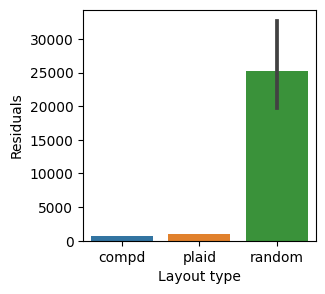

In [32]:
fig, ax = plt.subplots(figsize=(3, 3))

#ax.set(ylim=(0,0.6))

ax = sns.barplot(x="layout", y="true_residuals", data=screening_residuals_df, order=["compd", "plaid", "random"])

#ax = sns.barplot(x="layout", y="MSE", data=results_df[results_df['MSE']!=np.inf], order=["PLAID", "RANDOM"])

ax.set(xlabel='Layout type', ylabel='Residuals')

plt.show()


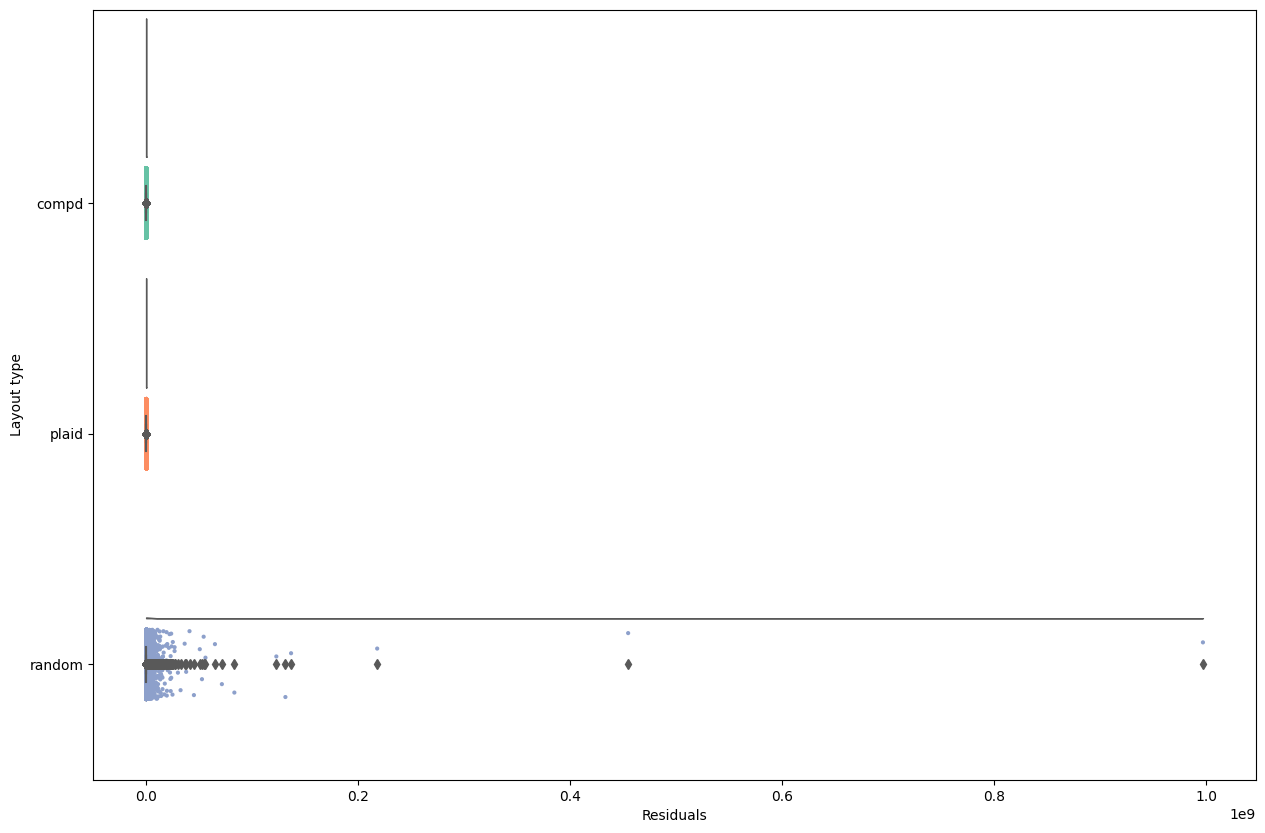

In [34]:
# Rain plot
#temp_half = residuals_df#[(residuals_df['MSE']!=np.inf) & (residuals_df['rows lost']<=1) & (residuals_df['E']>20) & (residuals_df['E']<100) ]
#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "true_residuals"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

ax = pt.RainCloud(x = "layout", y = "true_residuals", data = screening_residuals_df, palette = pal, bw = sigma,
                 width_viol = 1.2, ax = ax, orient = ort, order=["compd", "plaid", "random"], jitter = 0.15)

#ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)

ax.set(xlabel='Residuals', ylabel='Layout type')

plt.show()

In [38]:
screen_all_rows = screening_residuals_df[(screening_residuals_df['lost_rows']<1) ]

rand_results_array = screen_all_rows.true_residuals[screen_all_rows.layout=="random"]
plaid_results_array = screen_all_rows.true_residuals[screen_all_rows.layout=="plaid"]
compd_results_array = screen_all_rows.true_residuals[screen_all_rows.layout=="compd"]

print("Variance of plaid layouts:", statistics.variance(plaid_results_array))
print("Variance of random layouts:", statistics.variance(rand_results_array))
print("Variance of compd layouts:", statistics.variance(compd_results_array),"\n")

print("PLAID vs RANDOM (same variance):", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = True))
print("PLAID vs RANDOM:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs COMPD:", stats.ttest_ind(compd_results_array,rand_results_array,equal_var = False))

print("PLAID vs COMPD:", stats.ttest_ind(plaid_results_array,compd_results_array,equal_var = False),"\n")

print("One way ANOVA:",stats.f_oneway(rand_results_array,plaid_results_array,compd_results_array))

Variance of plaid layouts: 10160275.134740759
Variance of random layouts: 90067488001.32605
Variance of compd layouts: 1039541.7226355189 

PLAID vs RANDOM (same variance): TtestResult(statistic=-16.652613576452843, pvalue=3.1333456566441783e-62, df=246398.0)
PLAID vs RANDOM: TtestResult(statistic=-16.652613576452843, pvalue=3.388801297090357e-62, df=123226.79550641796)
RANDOM vs COMPD: TtestResult(statistic=-17.129872728671902, pvalue=1.059074914866424e-65, df=123201.84387859618)
PLAID vs COMPD: TtestResult(statistic=42.72355897546886, pvalue=0.0, df=148147.8754293558) 

One way ANOVA: F_onewayResult(statistic=285.4663638784558, pvalue=1.315802928036825e-124)


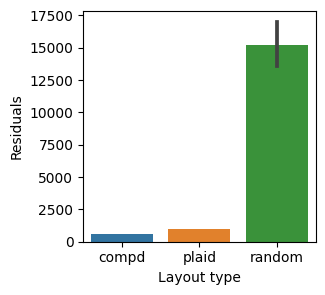

In [40]:
fig, ax = plt.subplots(figsize=(3, 3))

#ax.set(ylim=(0,0.6))

ax = sns.barplot(x="layout", y="true_residuals", data=screen_all_rows, order=["compd", "plaid", "random"])

#ax = sns.barplot(x="layout", y="MSE", data=results_df[results_df['MSE']!=np.inf], order=["PLAID", "RANDOM"])

ax.set(xlabel='Layout type', ylabel='Residuals')

plt.show()


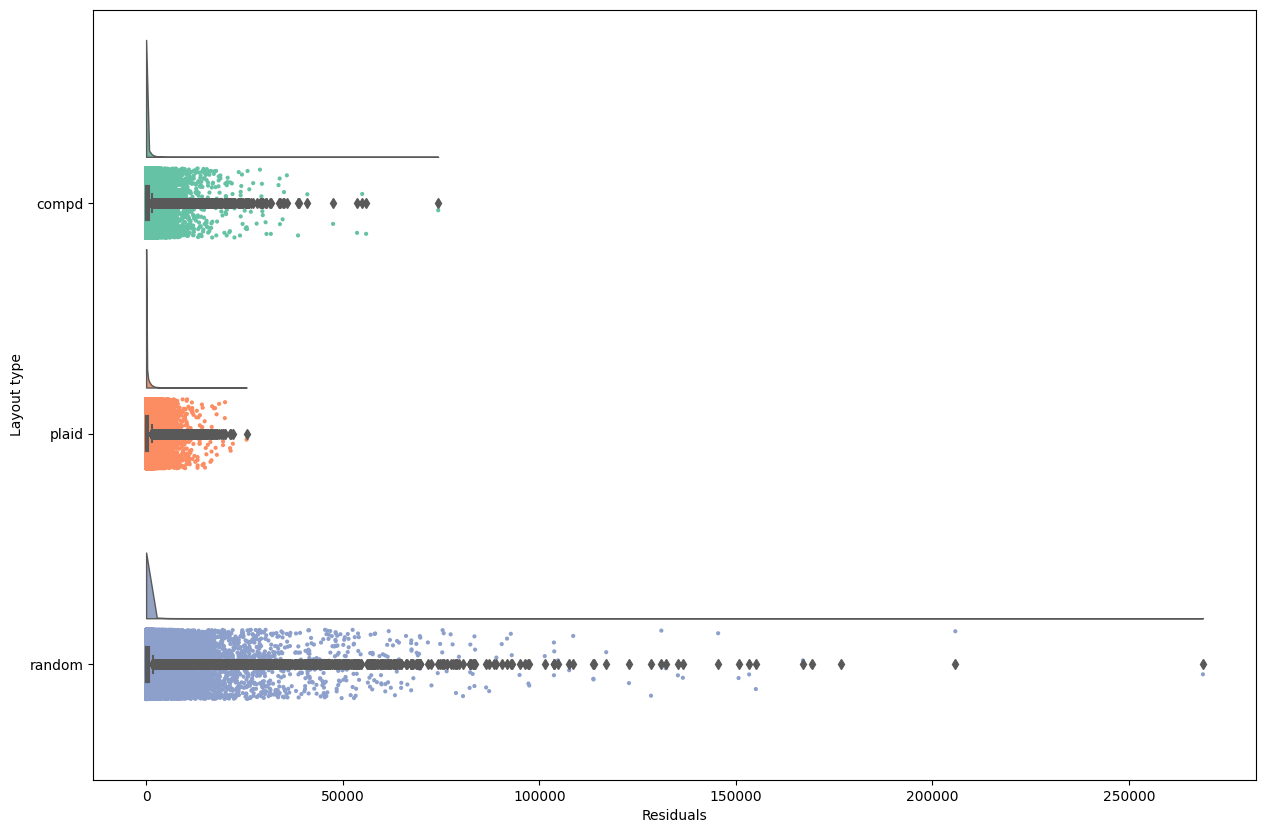

In [197]:
# Rain plot
#temp_half = residuals_df#[(residuals_df['MSE']!=np.inf) & (residuals_df['rows lost']<=1) & (residuals_df['E']>20) & (residuals_df['E']<100) ]
#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "true_residuals"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

ax = pt.RainCloud(x = "layout", y = "true_residuals", data = screen_all_rows, palette = pal, bw = sigma,
                 width_viol = 1.2, ax = ax, orient = ort, order=["compd", "plaid", "random"], jitter = 0.15)

#ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)

ax.set(xlabel='Residuals', ylabel='Layout type')

plt.show()

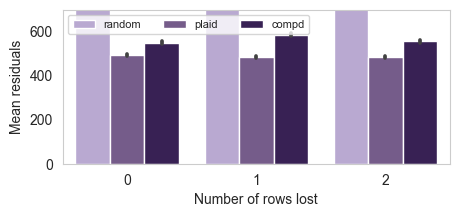

In [235]:
## Plot residuals for different amounts of rows lost ##

#screening_residuals_df.loc[(screening_residuals_df['layout'] == "random"), 'layout'] = "Random"
#screening_residuals_df.loc[(screening_residuals_df['layout'] == "compd"), 'layout'] = "Border"
#screening_residuals_df.loc[(screening_residuals_df['layout'] == "plaid"), 'layout'] = "Effective"

sns.set_style("whitegrid", {'axes.grid' : False})

fig, ax = plt.subplots(figsize=(5, 2))

palette = ["#b7a2d8", "#765591", "#37185d"] #Dark purple
ax.set(ylim=(0,699))
ax = sns.barplot(x="lost_rows", y="true_residuals", hue="layout", data=screening_residuals_df, palette=palette)

plt.xlabel("Number of rows lost", fontsize = 10)
plt.ylabel("Mean residuals", fontsize = 10)
plt.legend(ncol=3, loc="upper left", fontsize = 8)

plt.show()


(neg_controls, pos_controls): 8 8
error: 0.06
percent_non_active: 0.99
screening-residuals-8-8-0.06-pna-0.99-20250623-ROC-supplement.csv


/var/folders/19/d2l08__d0td7zclgtgykpkc00000gn/T/ipykernel_64933/3129189901.py:11: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  screening_residuals_df = pd.read_csv(residuals_filename)


percent_non_active: 0.95
screening-residuals-8-8-0.06-pna-0.95-20250623-ROC-supplement.csv


/var/folders/19/d2l08__d0td7zclgtgykpkc00000gn/T/ipykernel_64933/3129189901.py:11: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  screening_residuals_df = pd.read_csv(residuals_filename)


percent_non_active: 0.9
screening-residuals-8-8-0.06-pna-0.9-20250623-ROC-supplement.csv


...

percent_non_active: 0.7
screening-residuals-8-8-0.06-pna-0.7-20250623-ROC-supplement.csv


/var/folders/19/d2l08__d0td7zclgtgykpkc00000gn/T/ipykernel_64933/3129189901.py:11: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  screening_residuals_df = pd.read_csv(residuals_filename)


percent_non_active: 0.6
screening-residuals-8-8-0.06-pna-0.6-20250623-ROC-supplement.csv


/var/folders/19/d2l08__d0td7zclgtgykpkc00000gn/T/ipykernel_64933/3129189901.py:11: DtypeWarning: Columns (0,3,4,5,6,7,8,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  screening_residuals_df = pd.read_csv(residuals_filename)


error: 0.1
percent_non_active: 0.99
screening-residuals-8-8-0.1-pna-0.99-20250623-ROC-supplement.csv


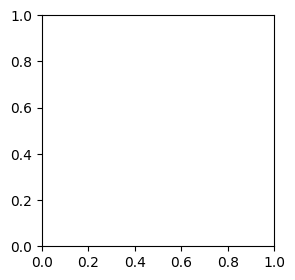

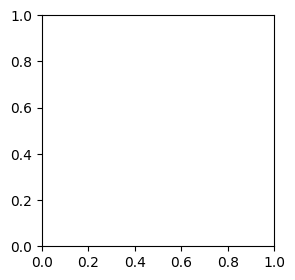

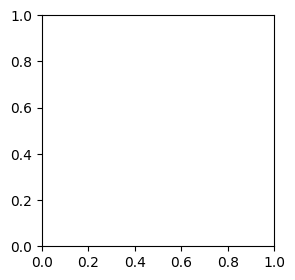

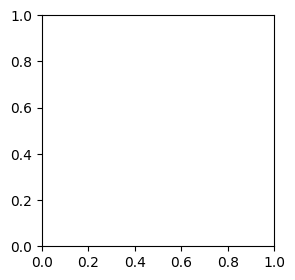

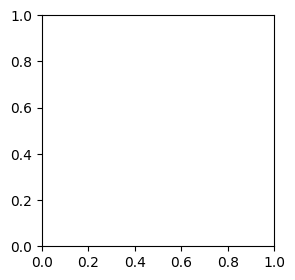

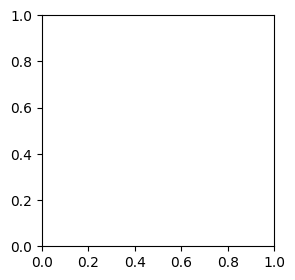

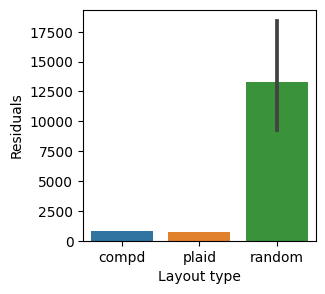

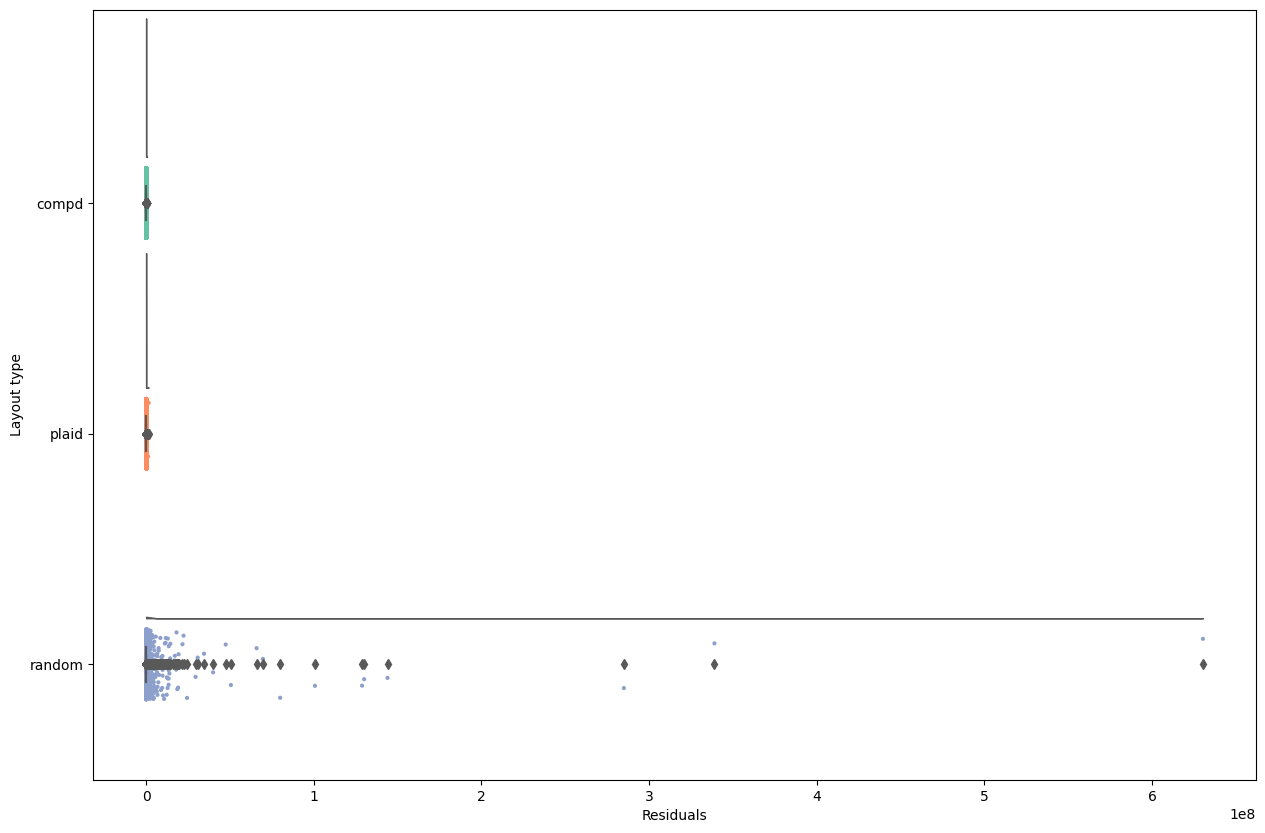

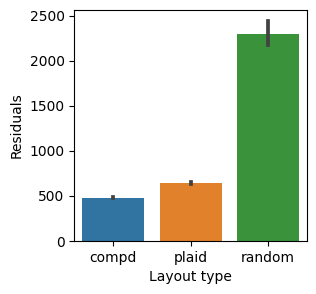

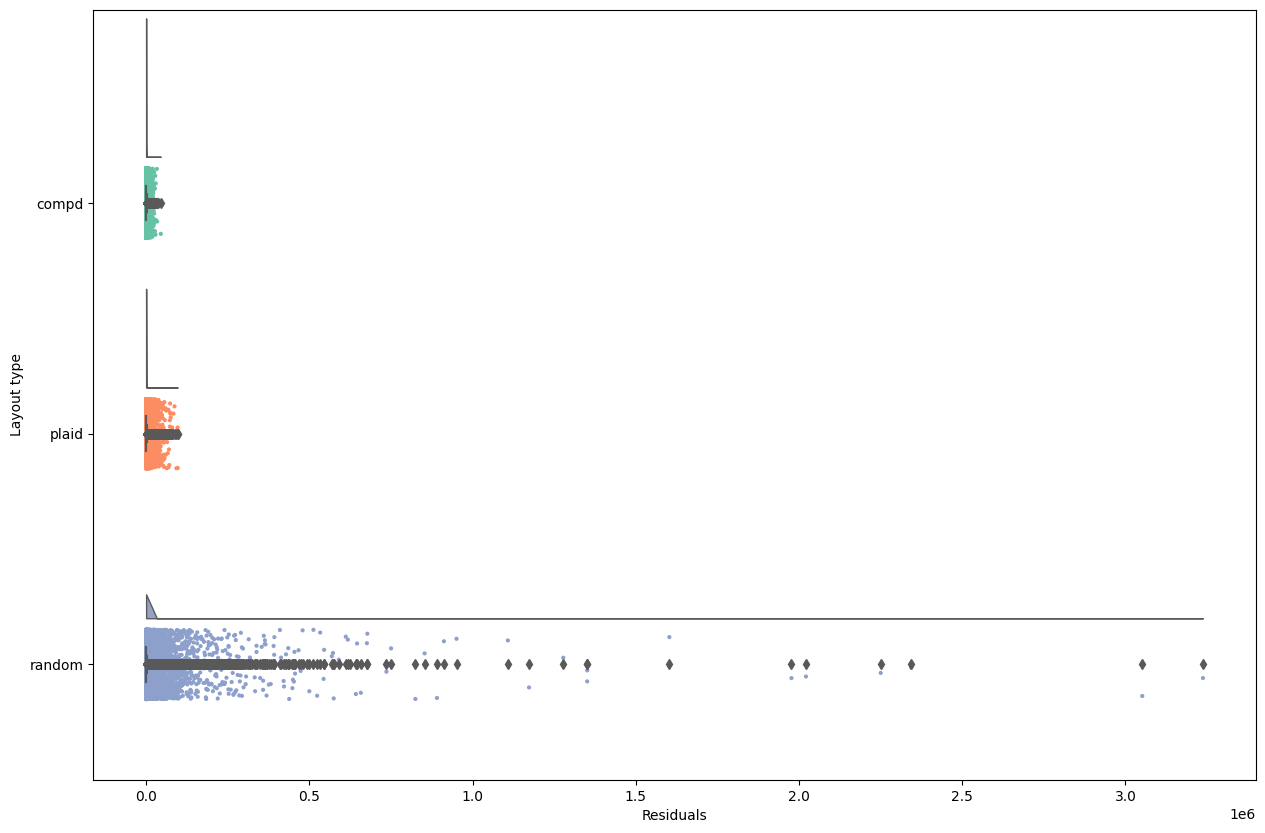

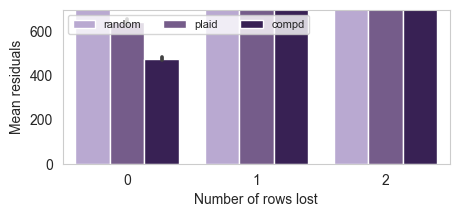

percent_non_active: 0.95
screening-residuals-8-8-0.1-pna-0.95-20250623-ROC-supplement.csv


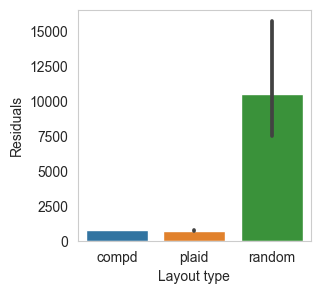

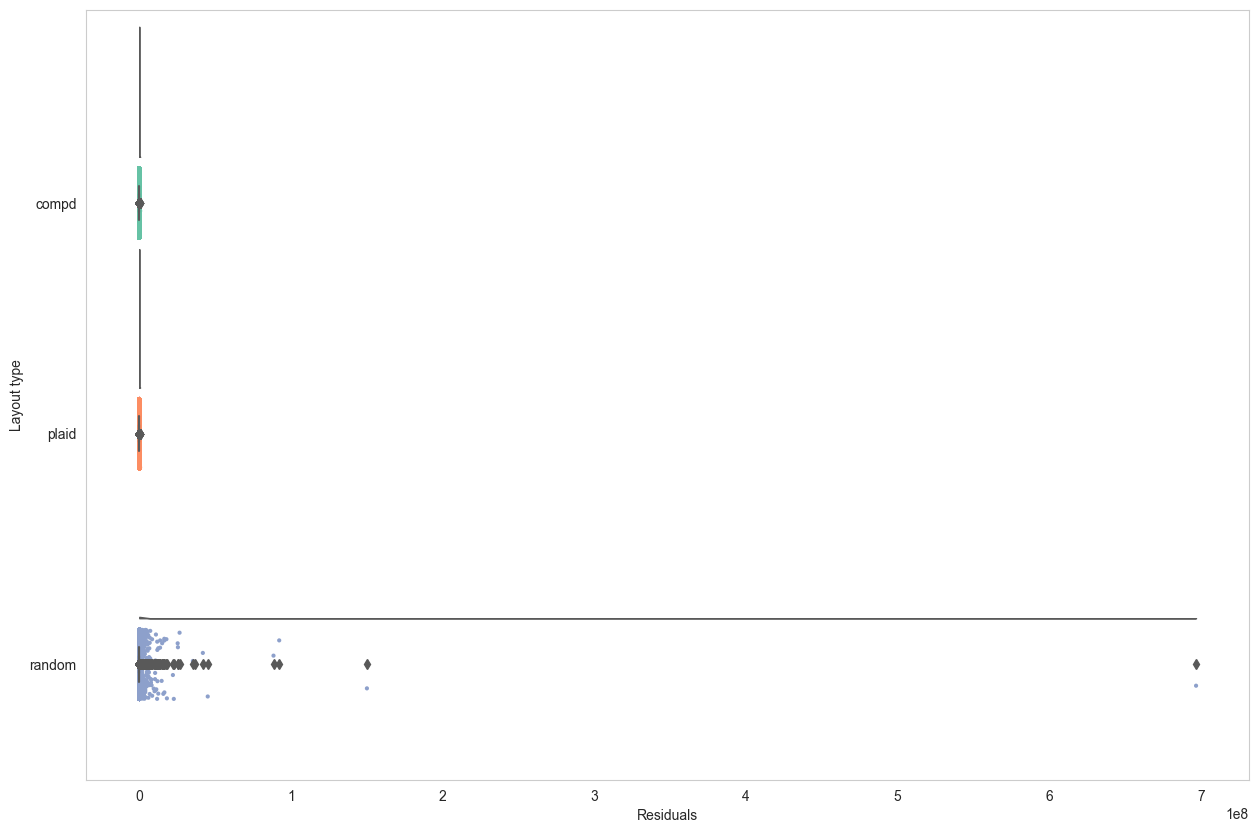

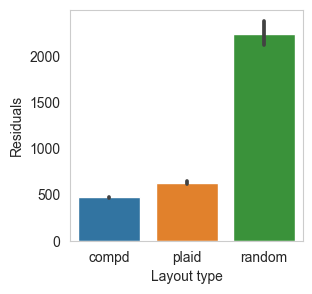

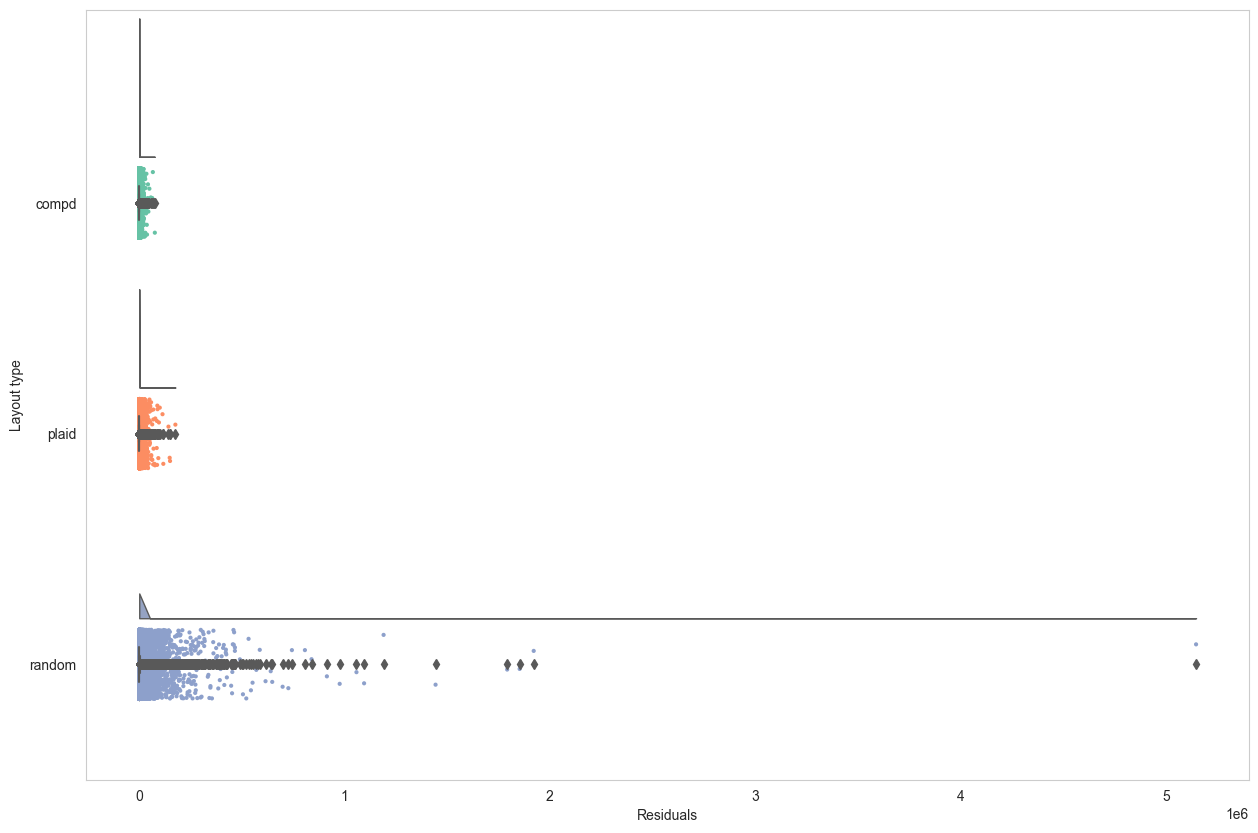

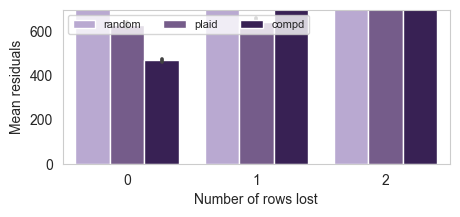

percent_non_active: 0.9
screening-residuals-8-8-0.1-pna-0.9-20250623-ROC-supplement.csv


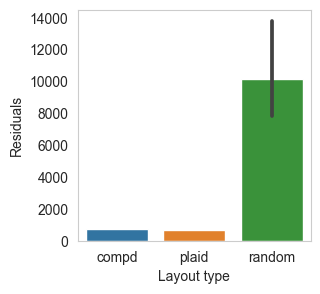

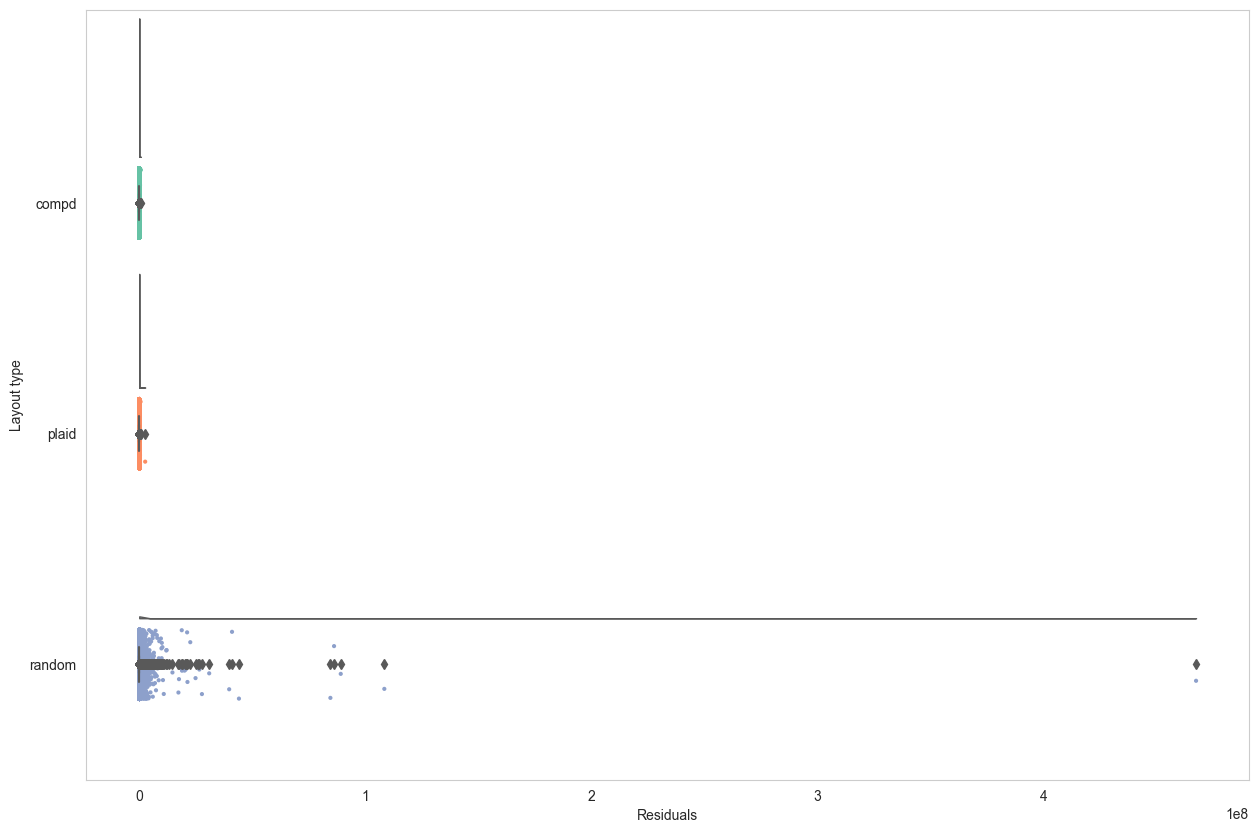

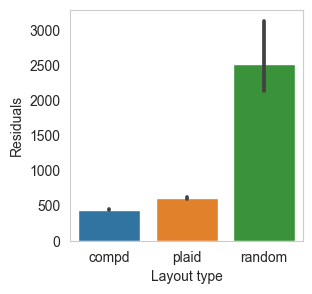

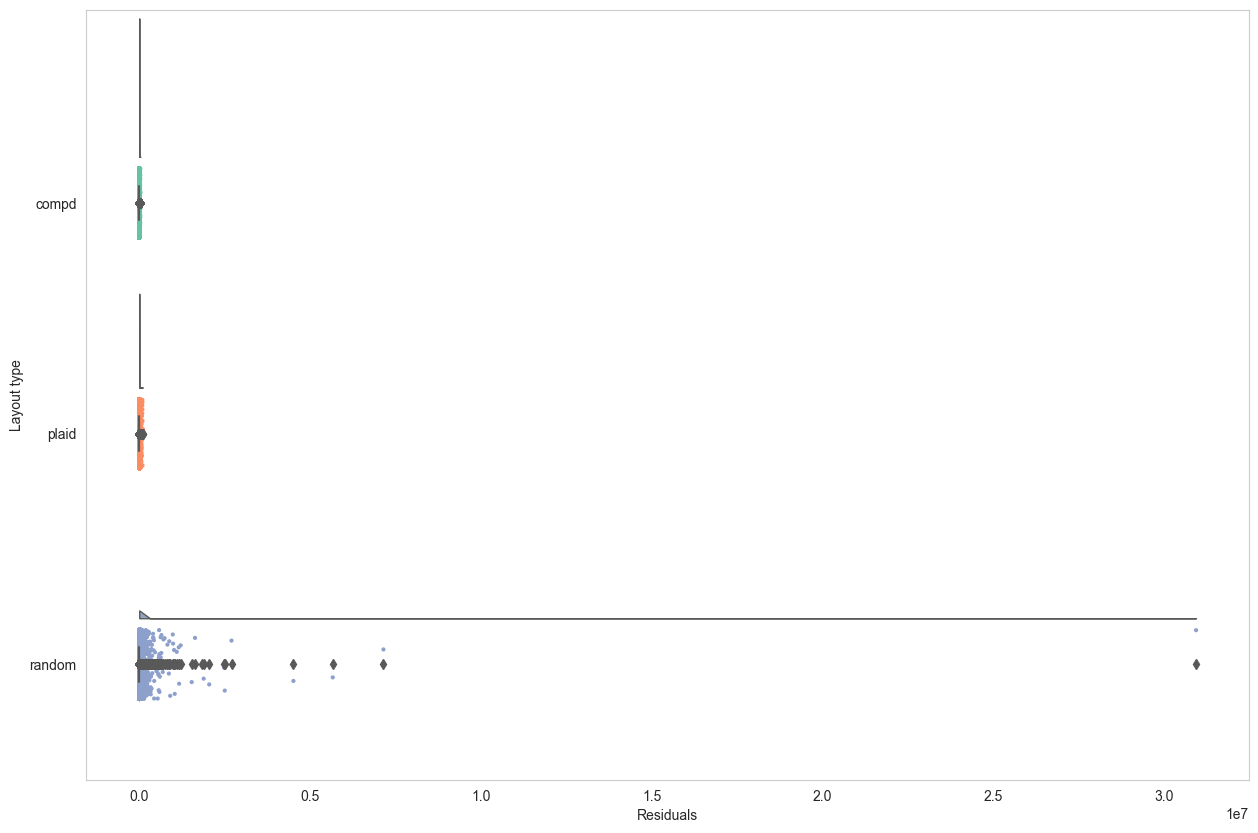

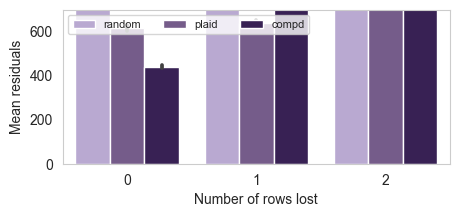

percent_non_active: 0.8
screening-residuals-8-8-0.1-pna-0.8-20250623-ROC-supplement.csv


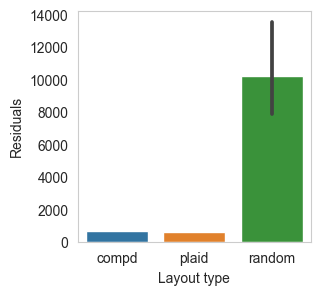

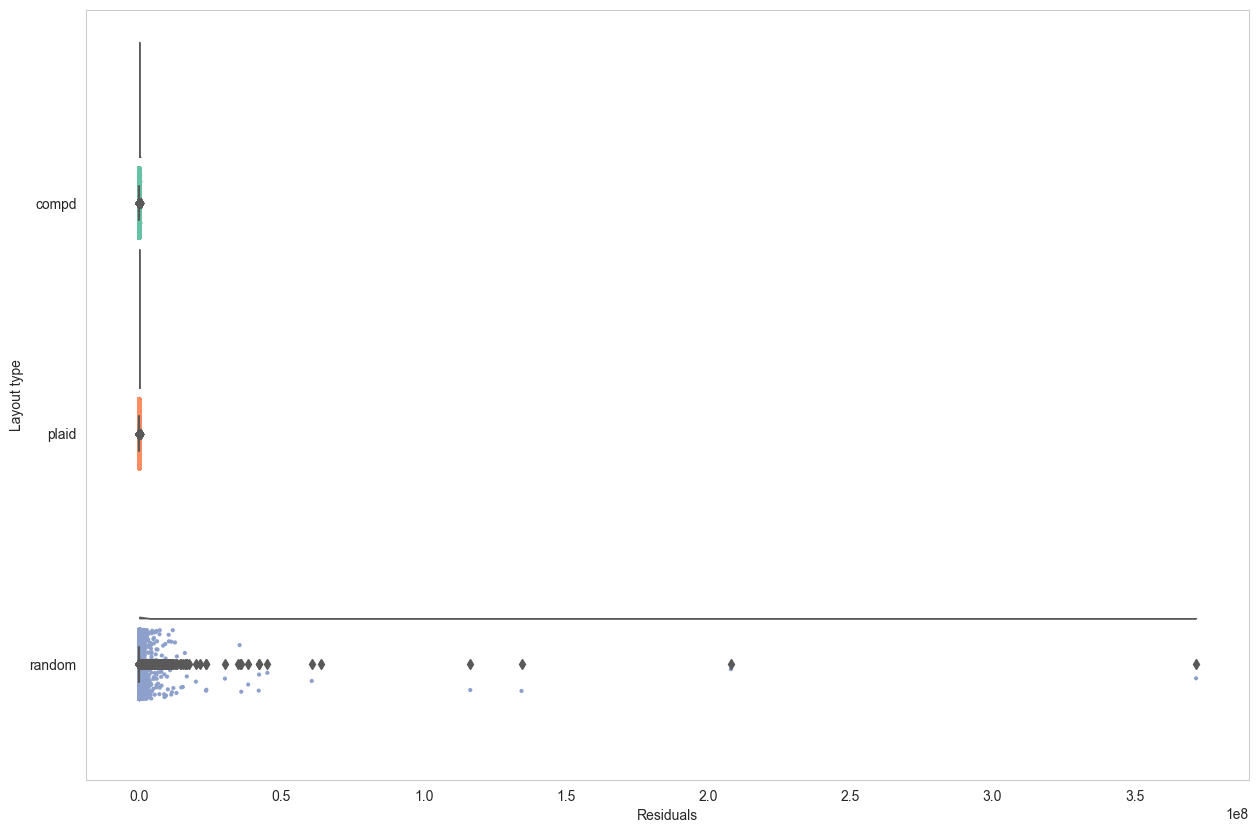

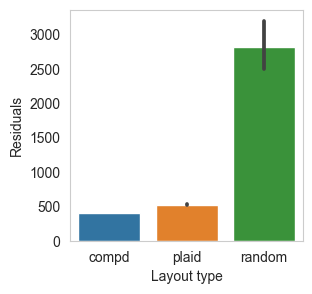

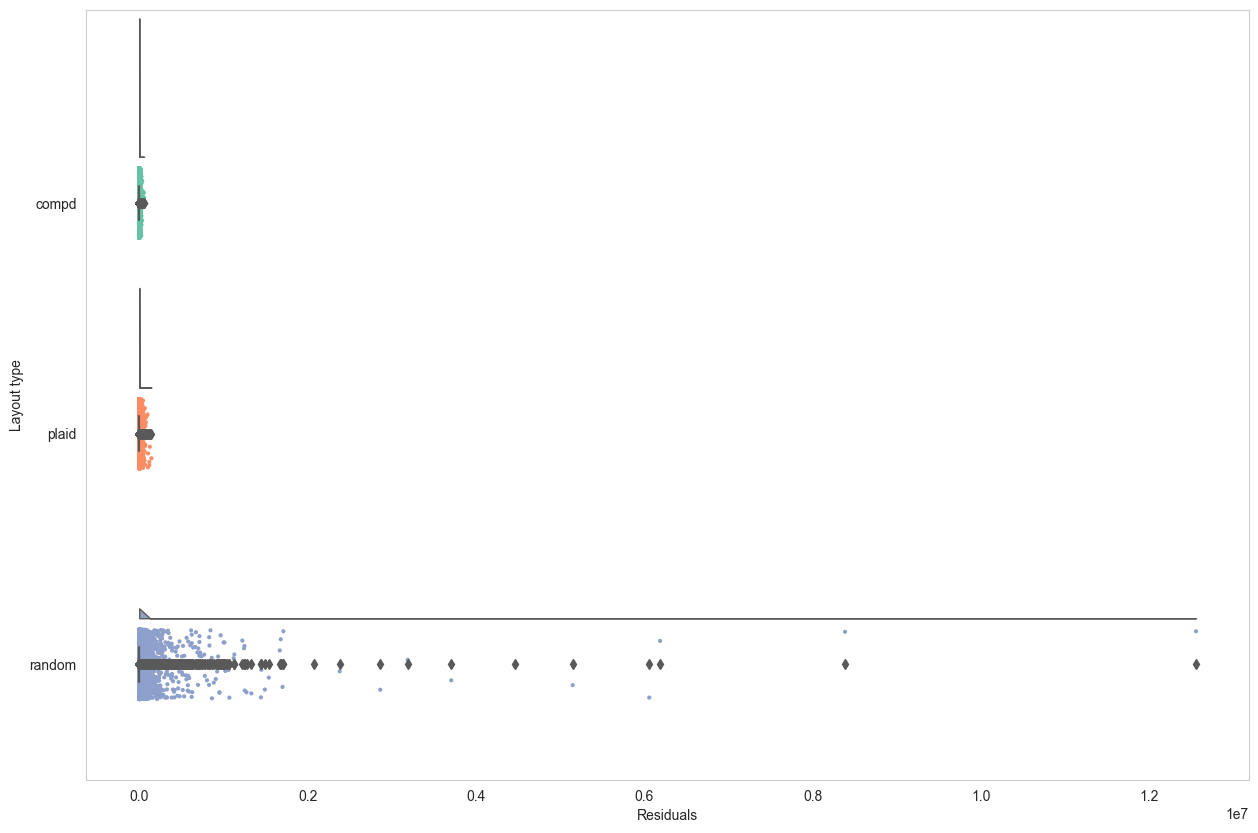

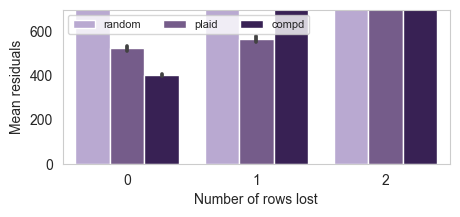

percent_non_active: 0.7
screening-residuals-8-8-0.1-pna-0.7-20250623-ROC-supplement.csv


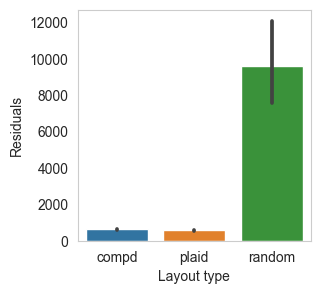

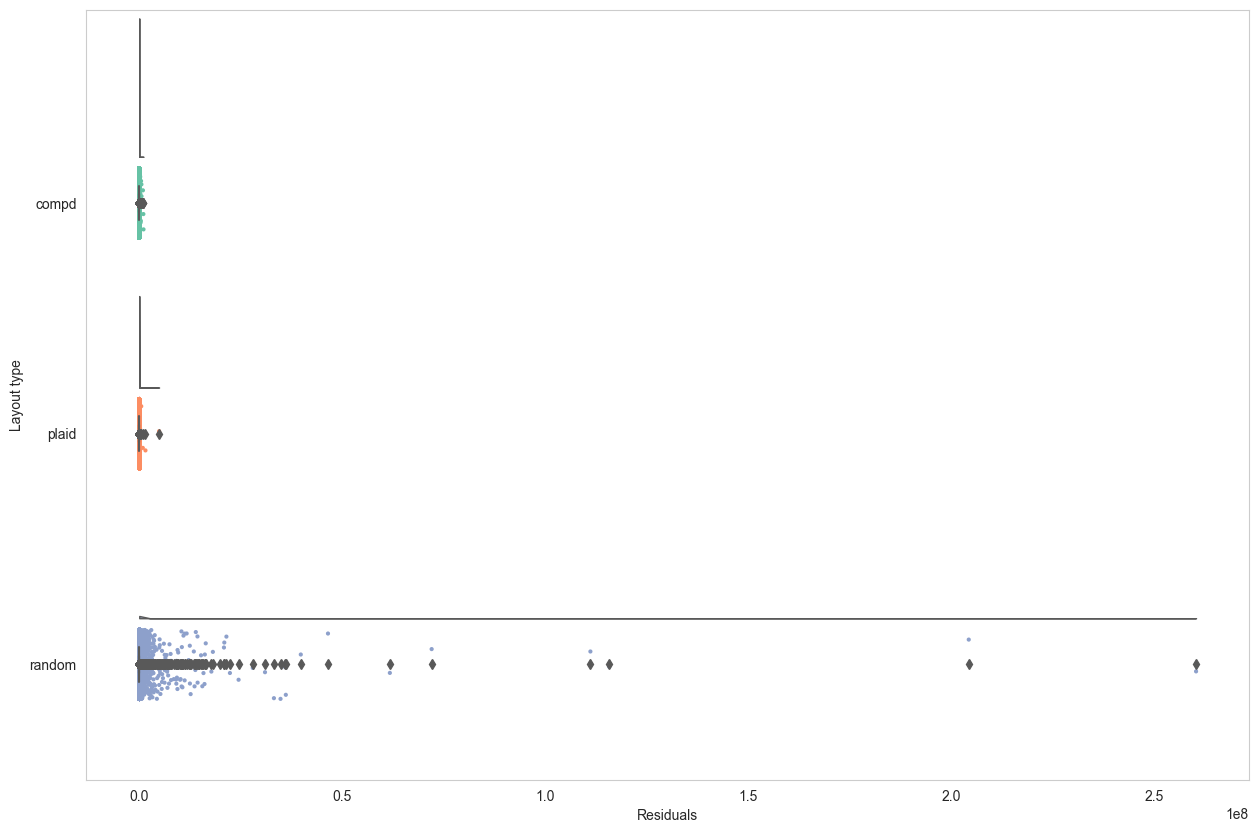

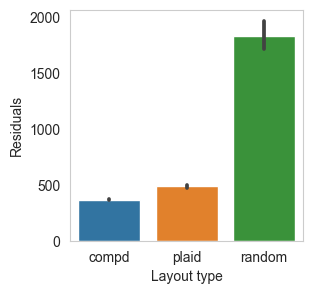

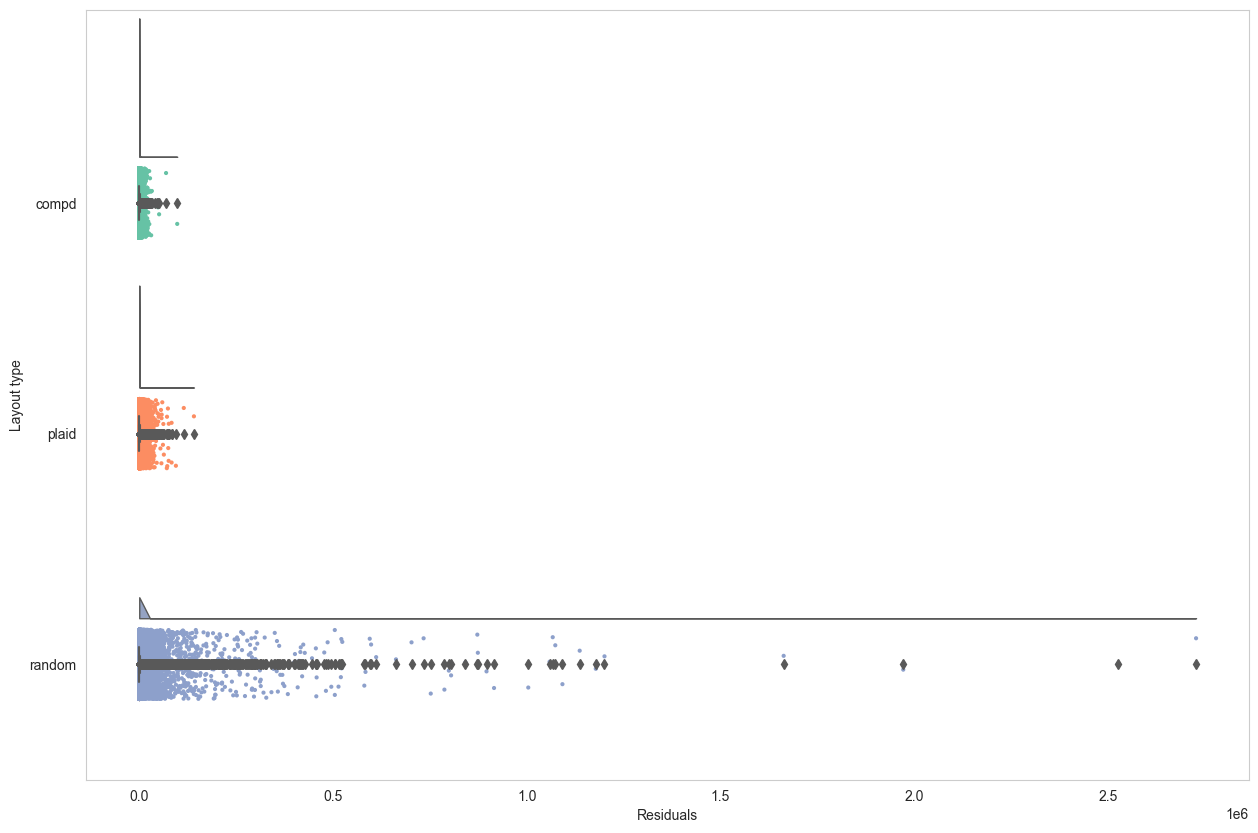

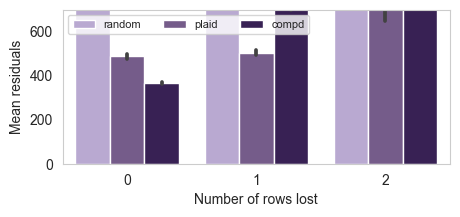

percent_non_active: 0.6
screening-residuals-8-8-0.1-pna-0.6-20250623-ROC-supplement.csv


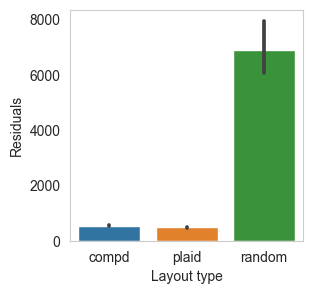

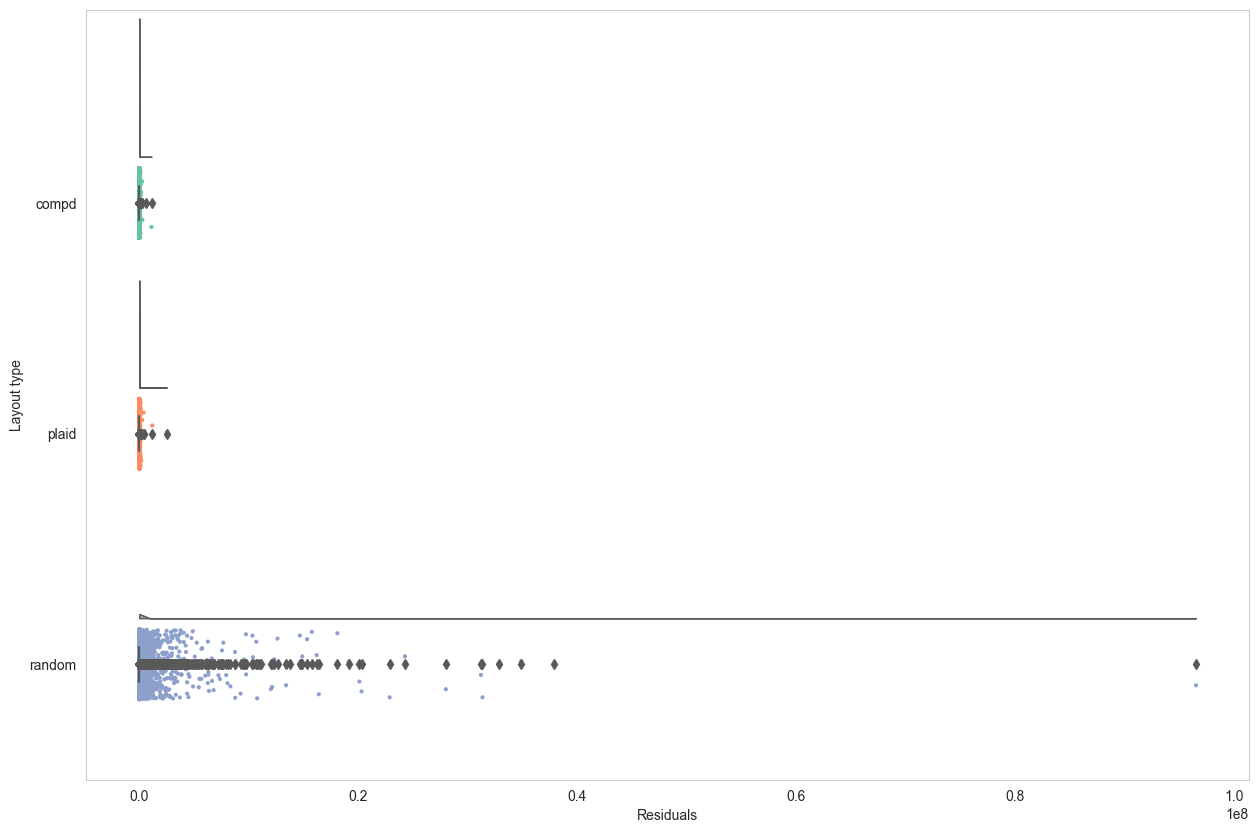

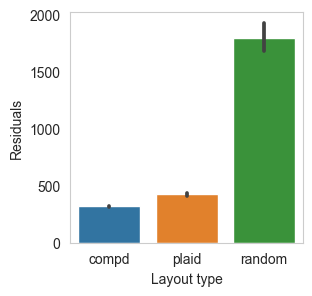

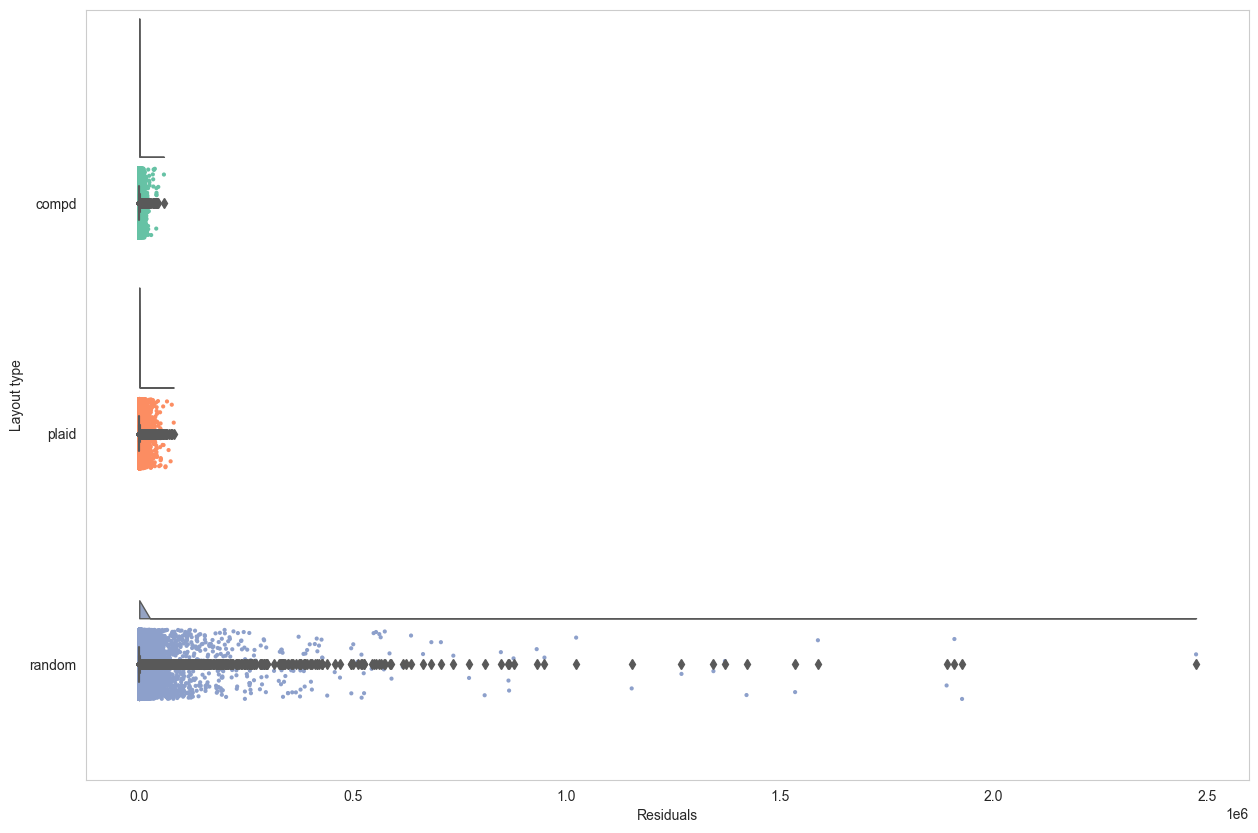

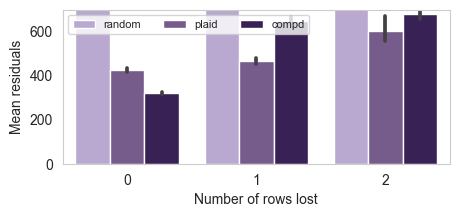

error: 0.2
percent_non_active: 0.99
screening-residuals-8-8-0.2-pna-0.99-20250623-ROC-supplement.csv


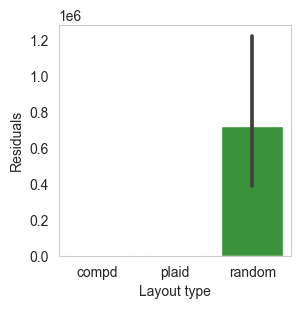

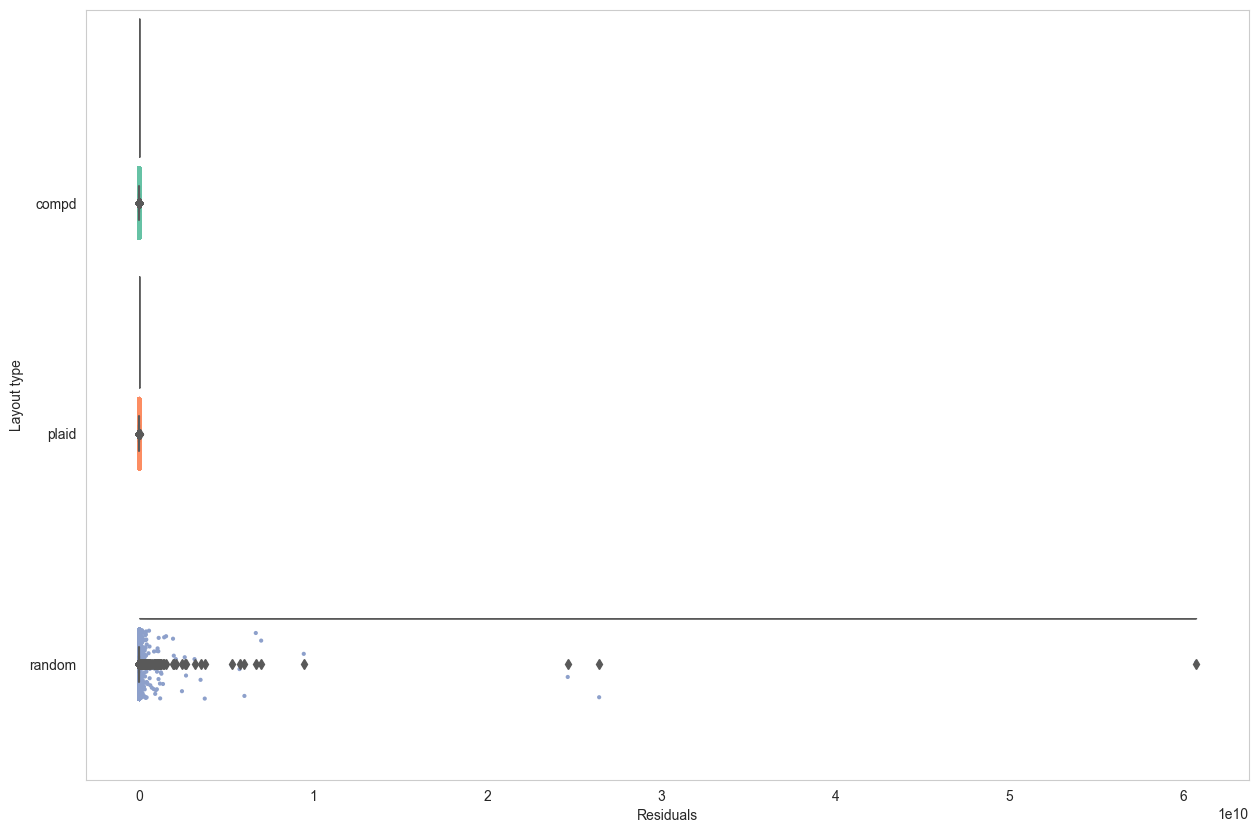

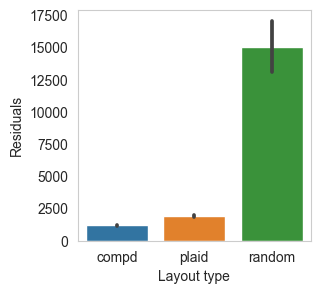

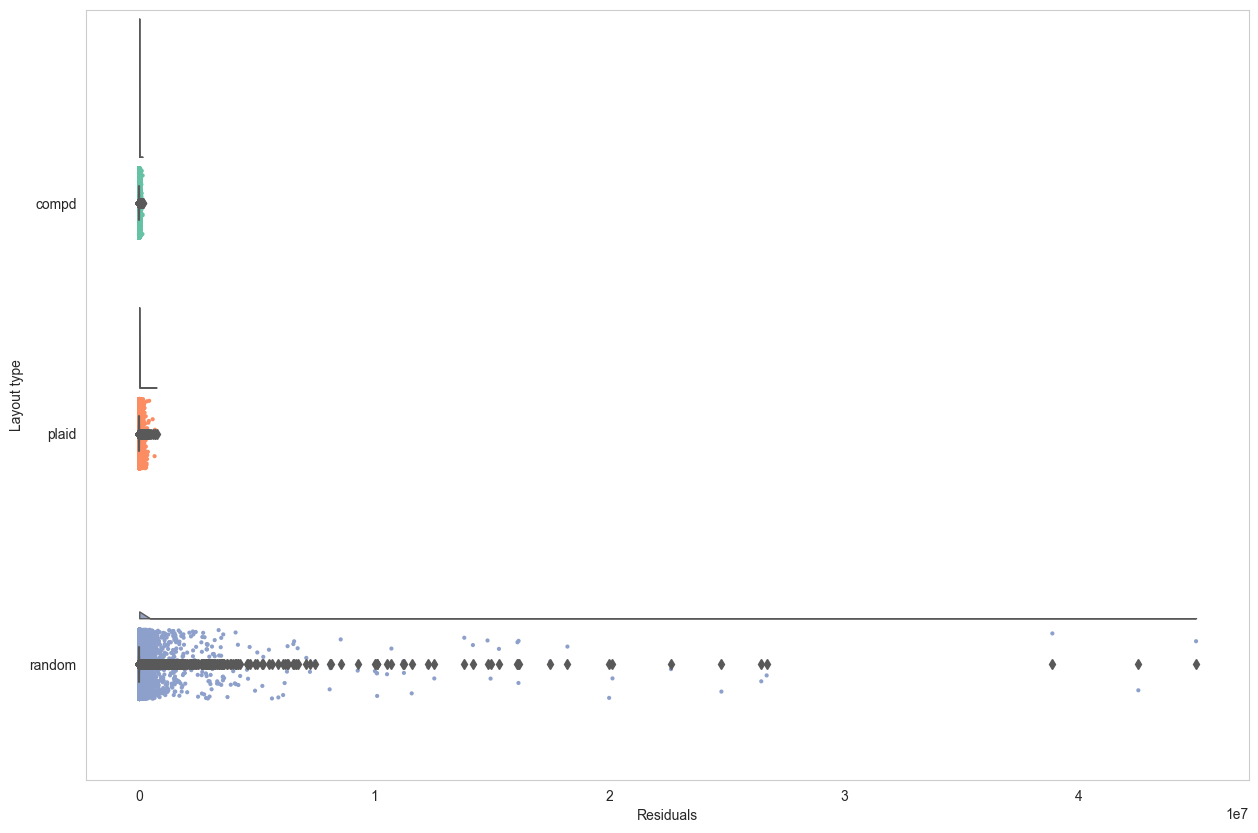

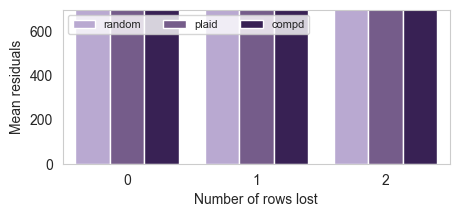

percent_non_active: 0.95
screening-residuals-8-8-0.2-pna-0.95-20250623-ROC-supplement.csv


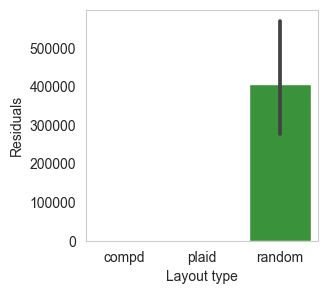

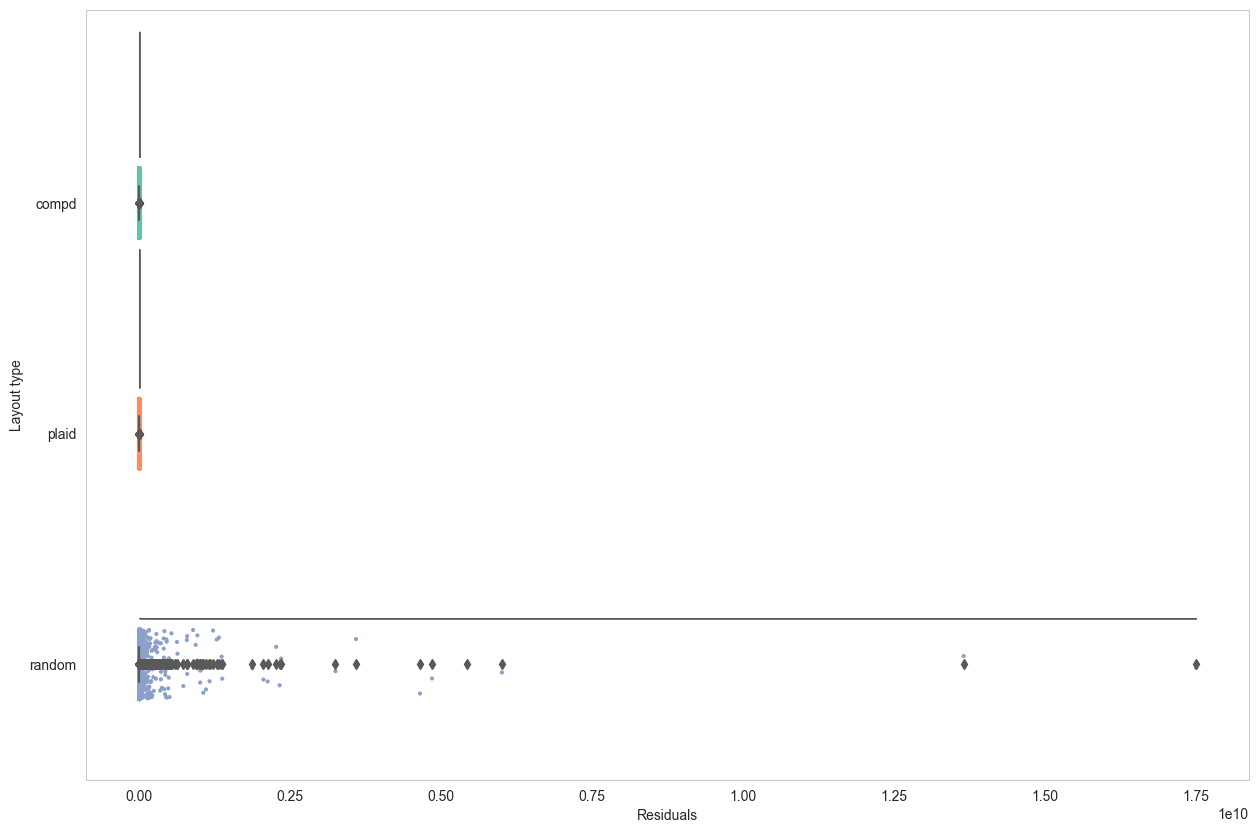

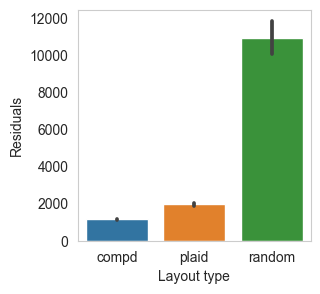

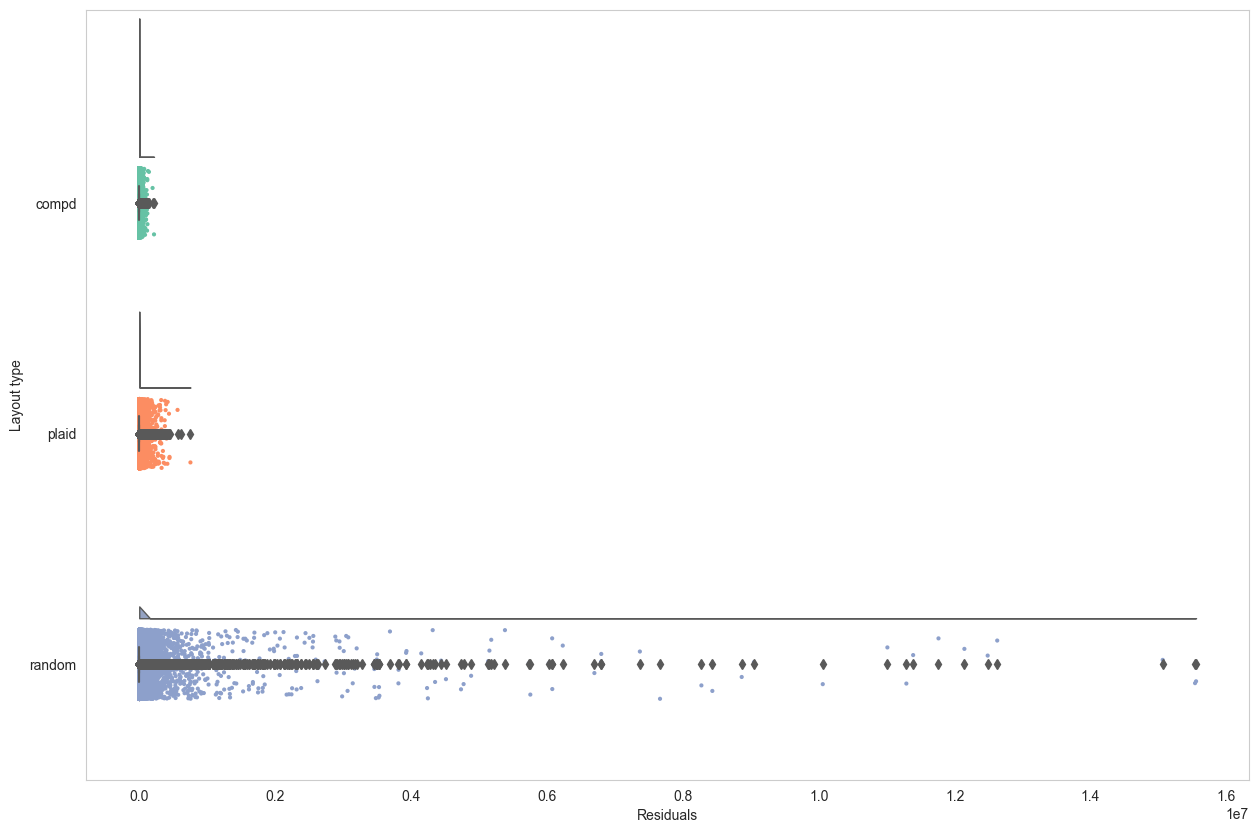

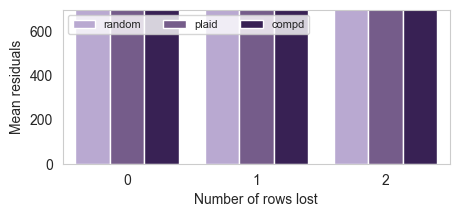

percent_non_active: 0.9
screening-residuals-8-8-0.2-pna-0.9-20250623-ROC-supplement.csv


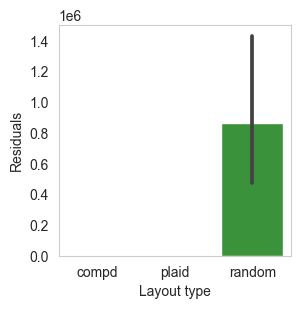

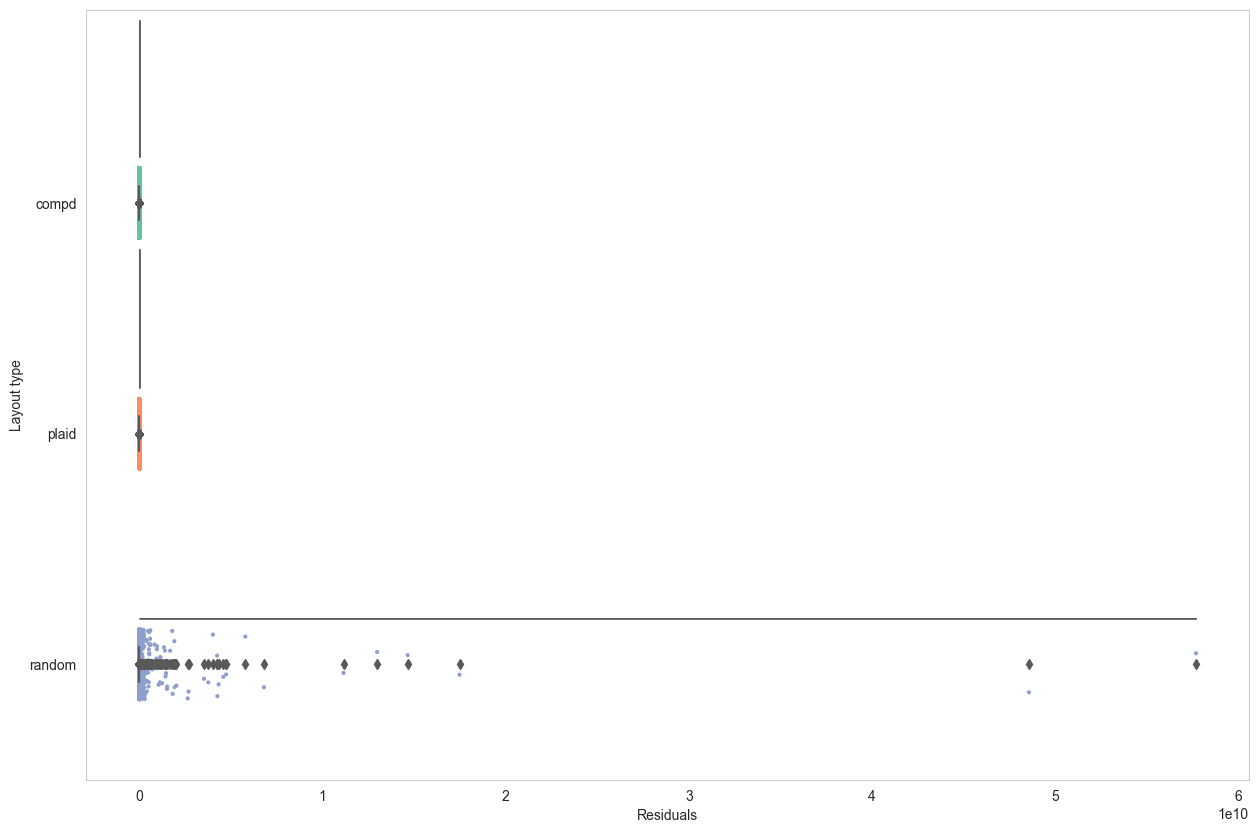

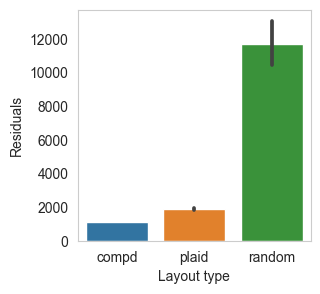

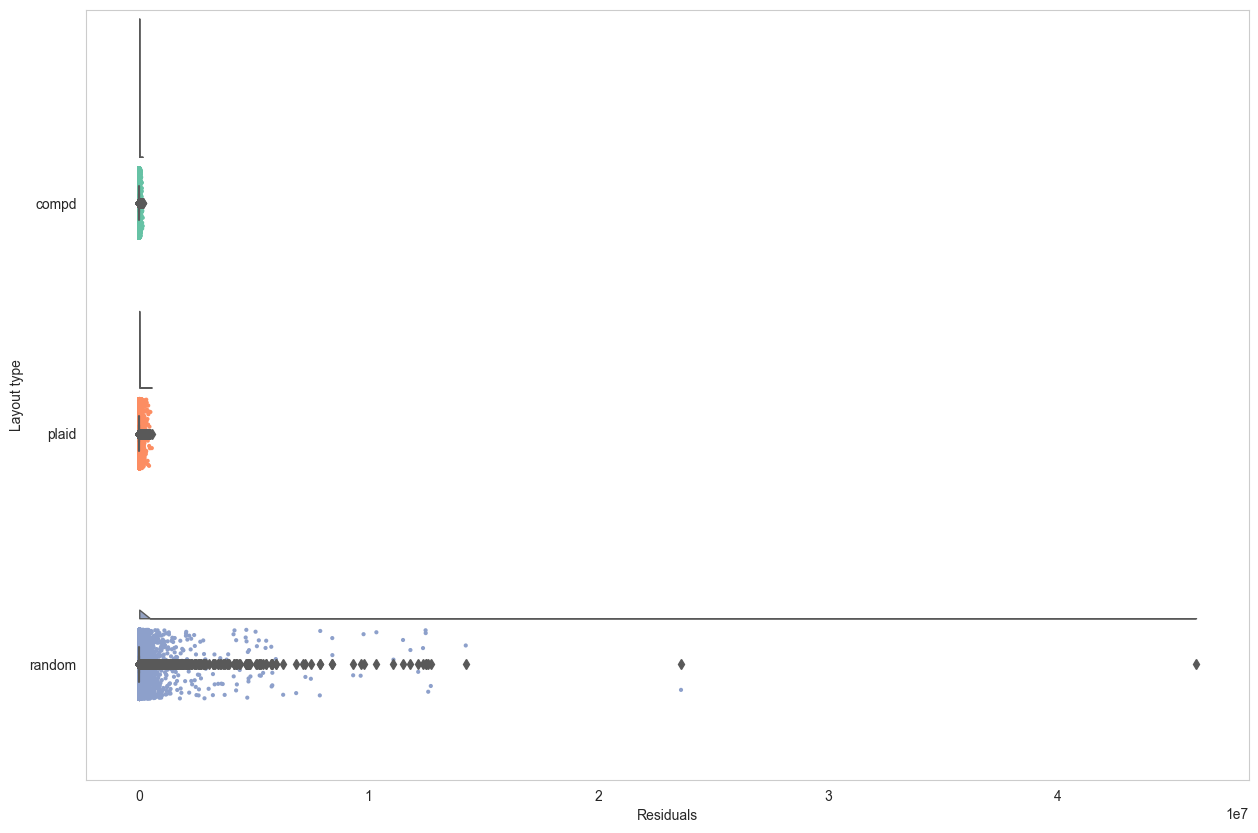

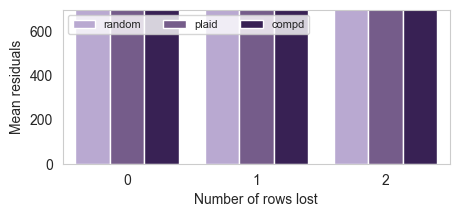

percent_non_active: 0.8
screening-residuals-8-8-0.2-pna-0.8-20250623-ROC-supplement.csv


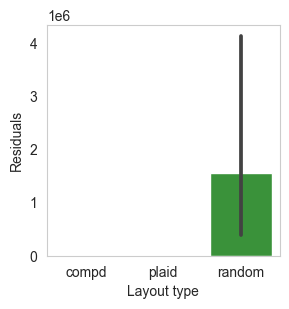

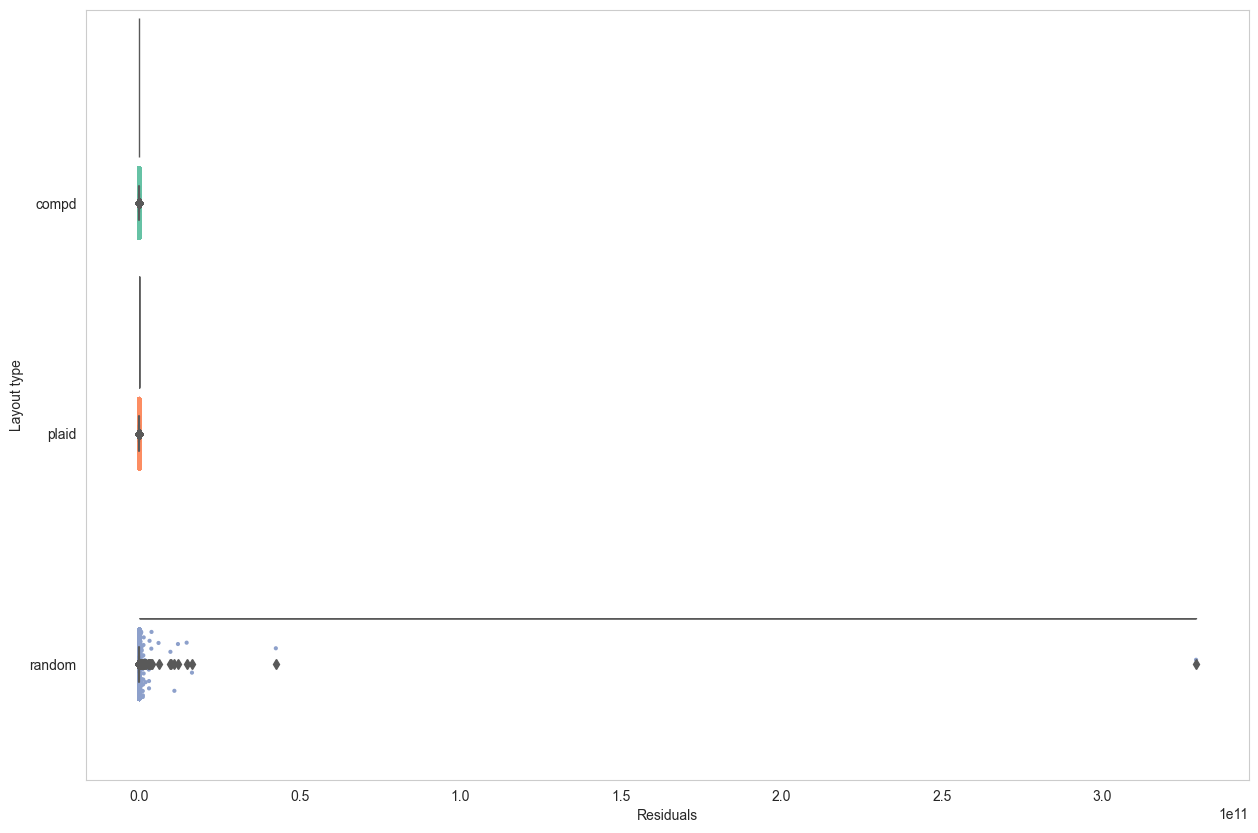

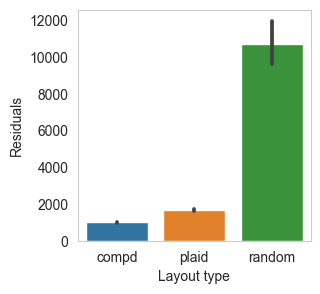

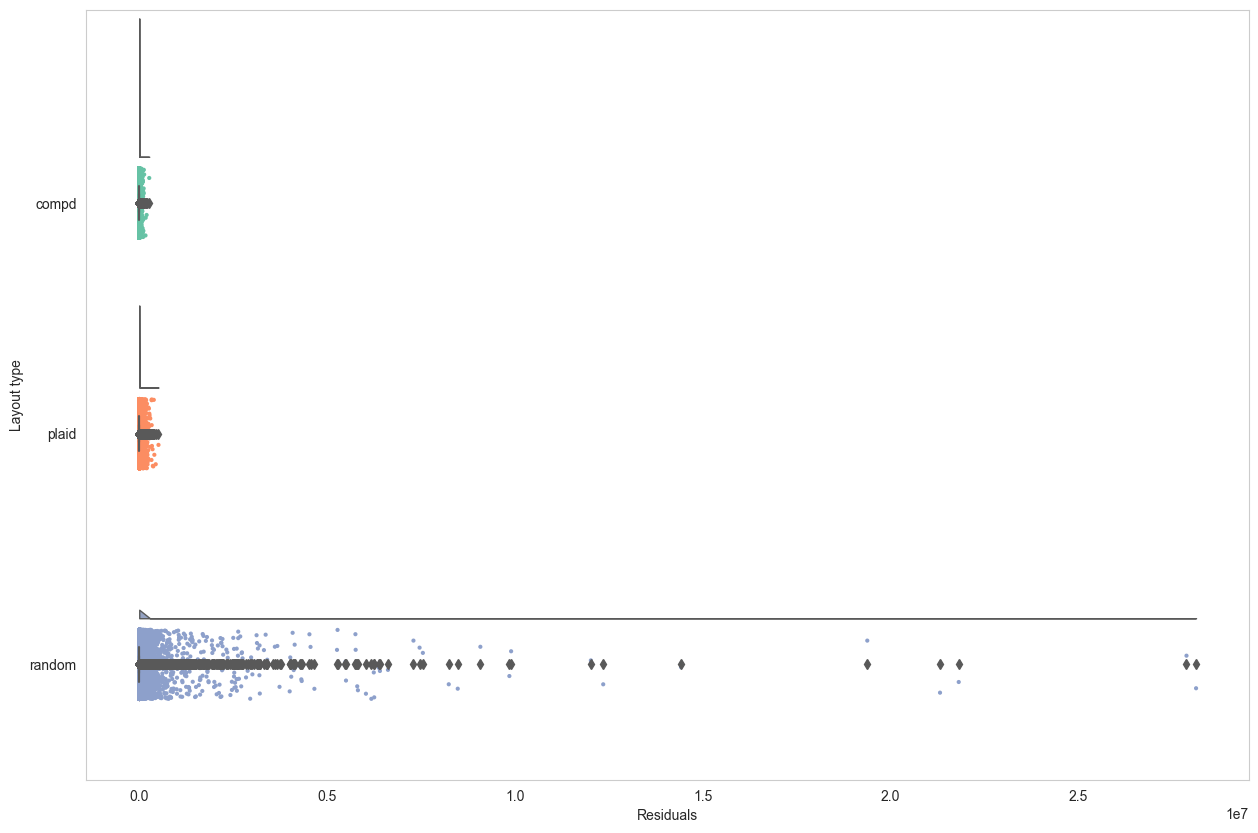

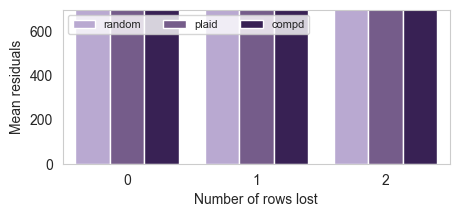

percent_non_active: 0.7
screening-residuals-8-8-0.2-pna-0.7-20250623-ROC-supplement.csv


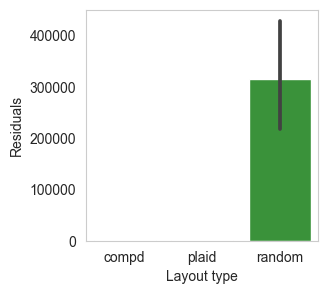

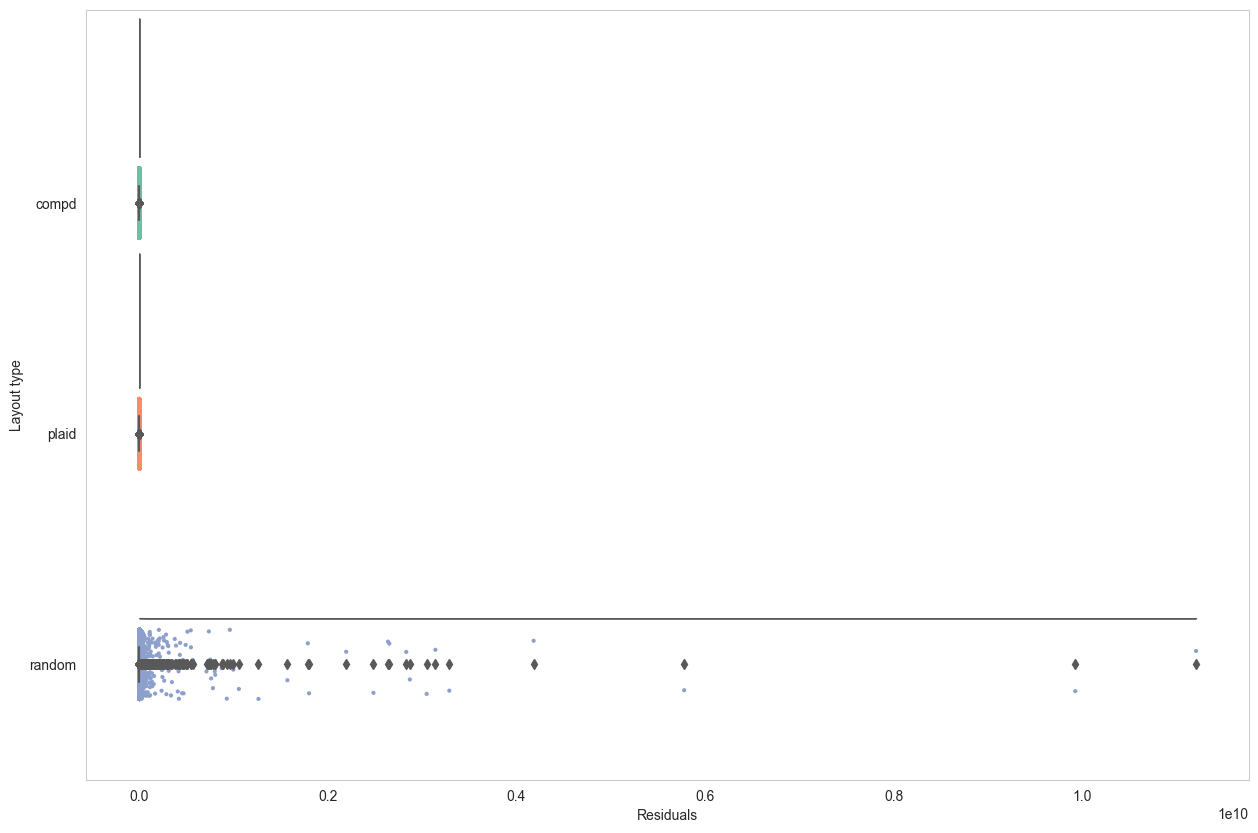

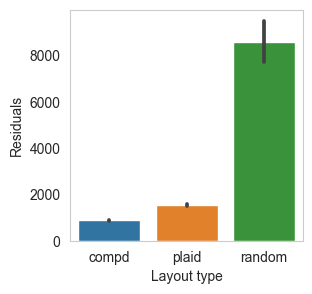

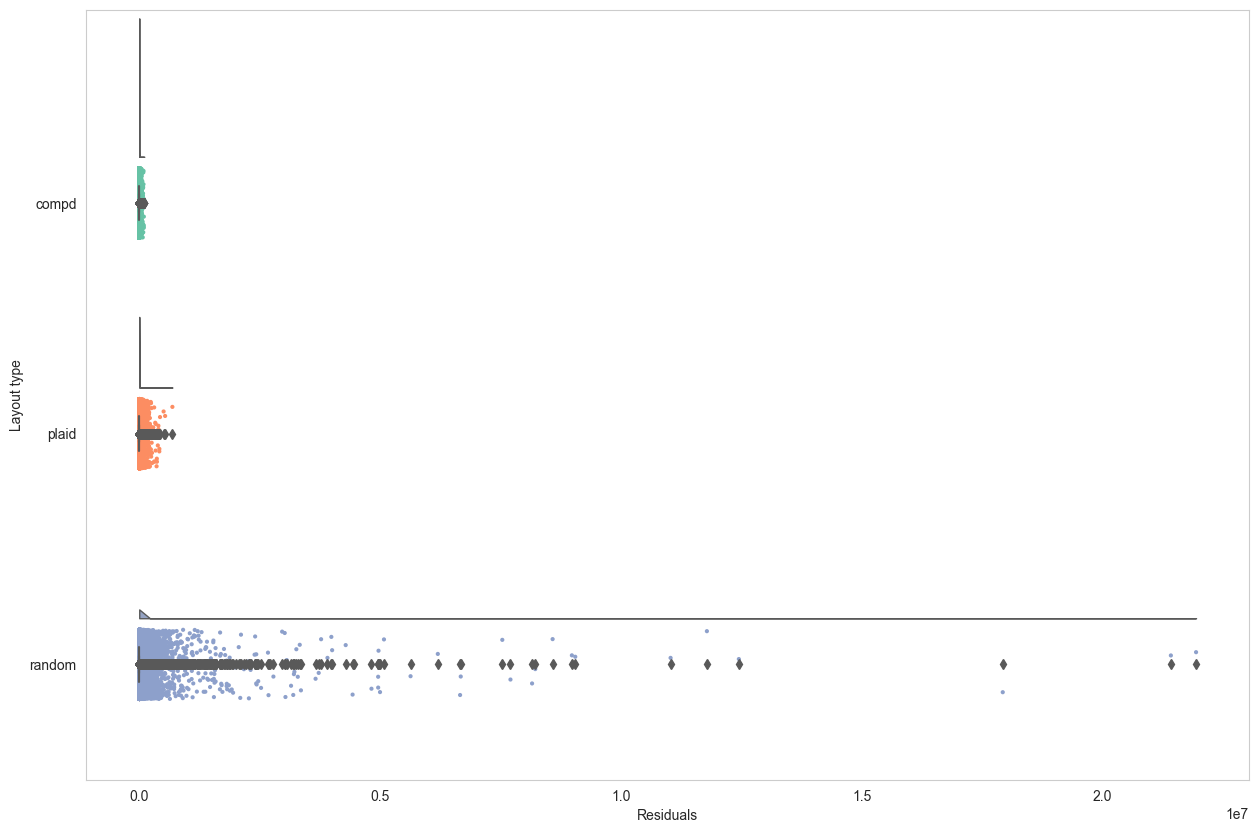

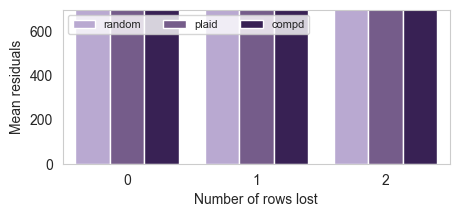

percent_non_active: 0.6
screening-residuals-8-8-0.2-pna-0.6-20250623-ROC-supplement.csv


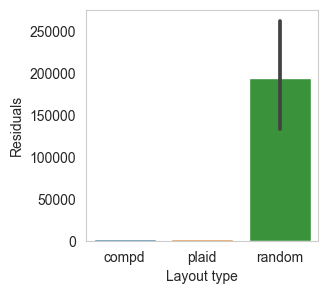

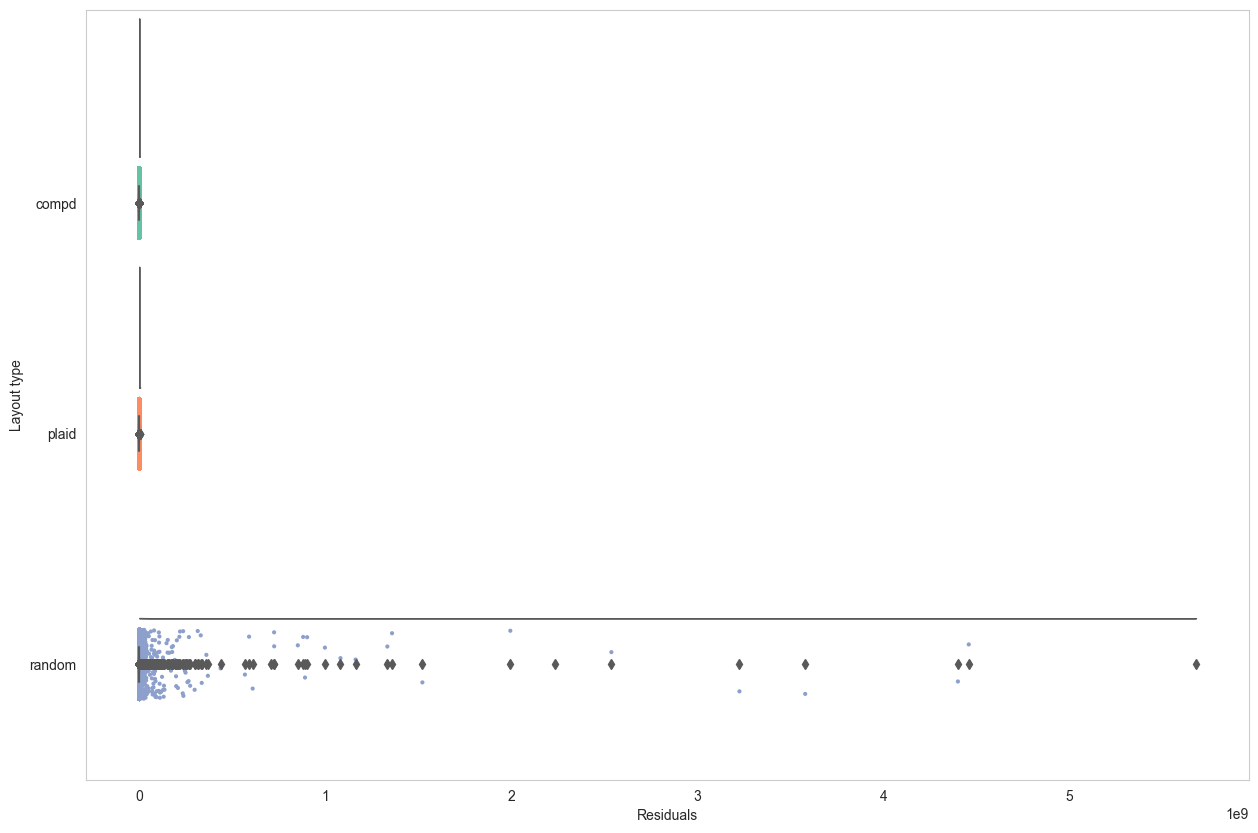

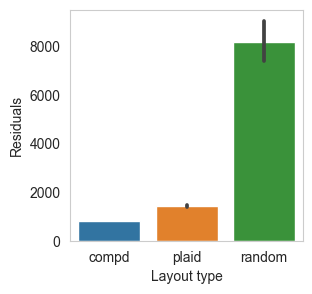

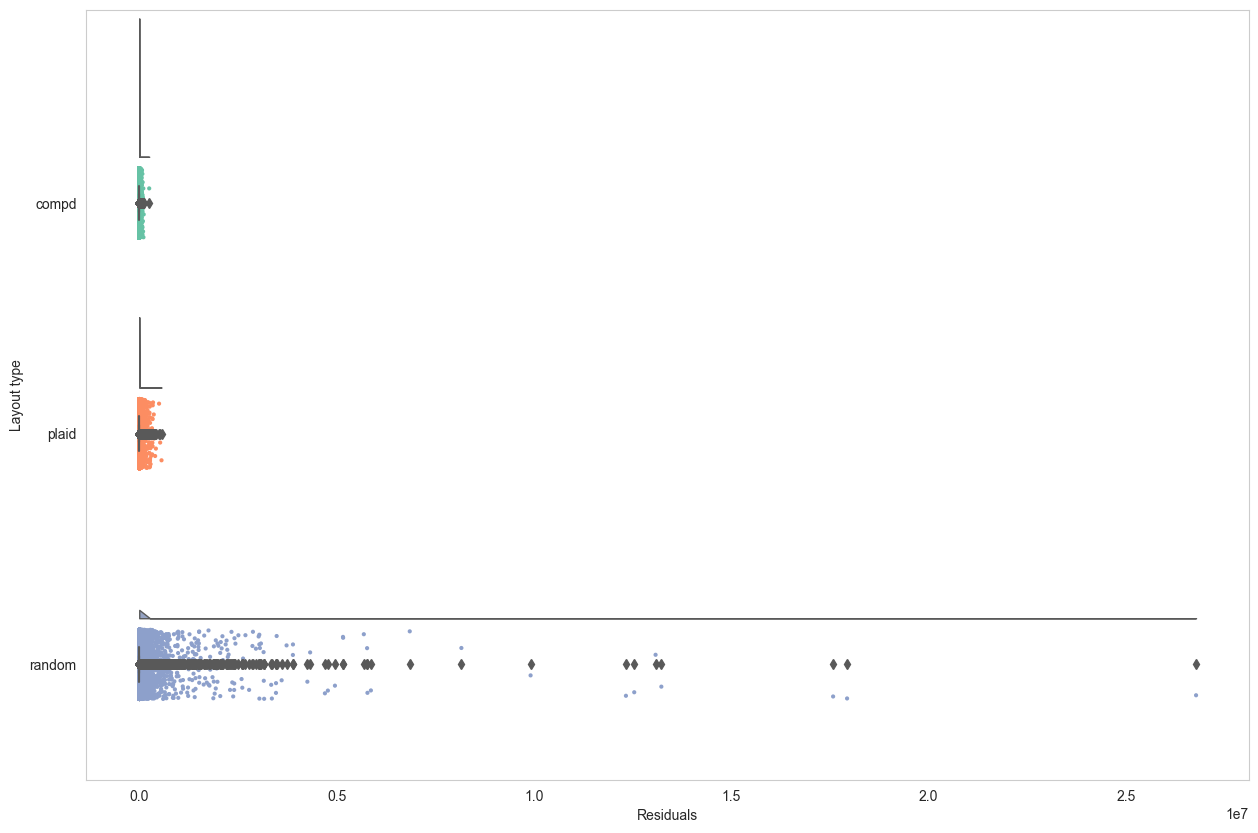

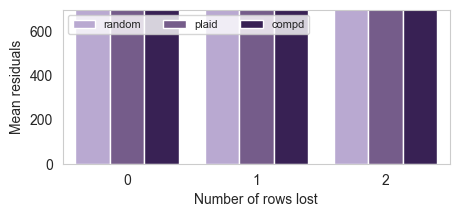

(neg_controls, pos_controls): 10 10
error: 0.06
percent_non_active: 0.99
screening-residuals-10-10-0.06-pna-0.99-20250623-ROC-supplement.csv


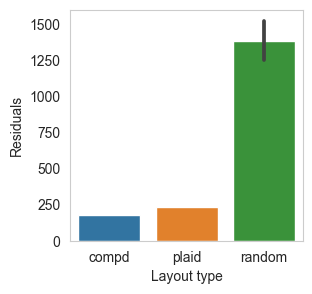

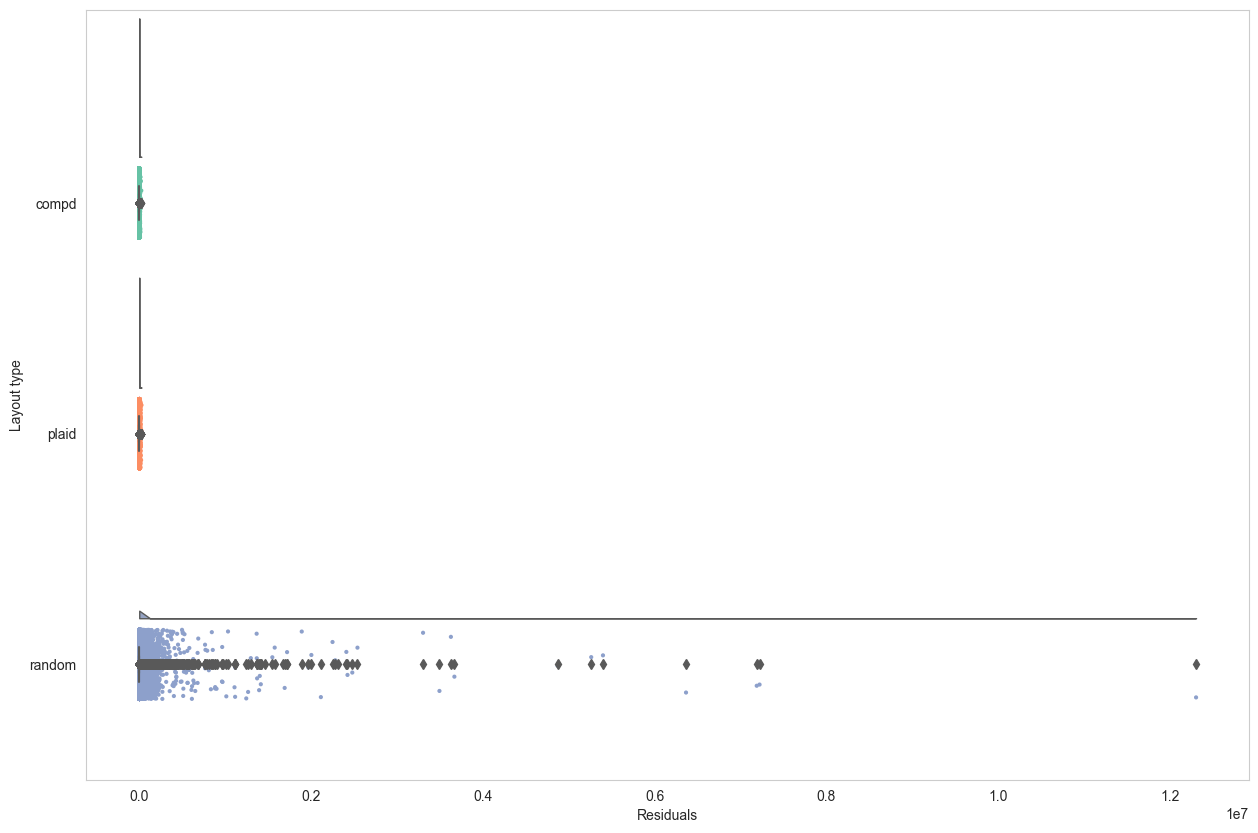

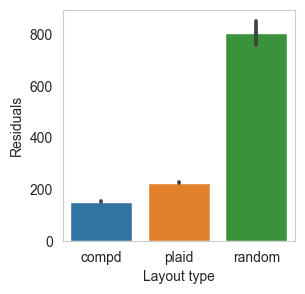

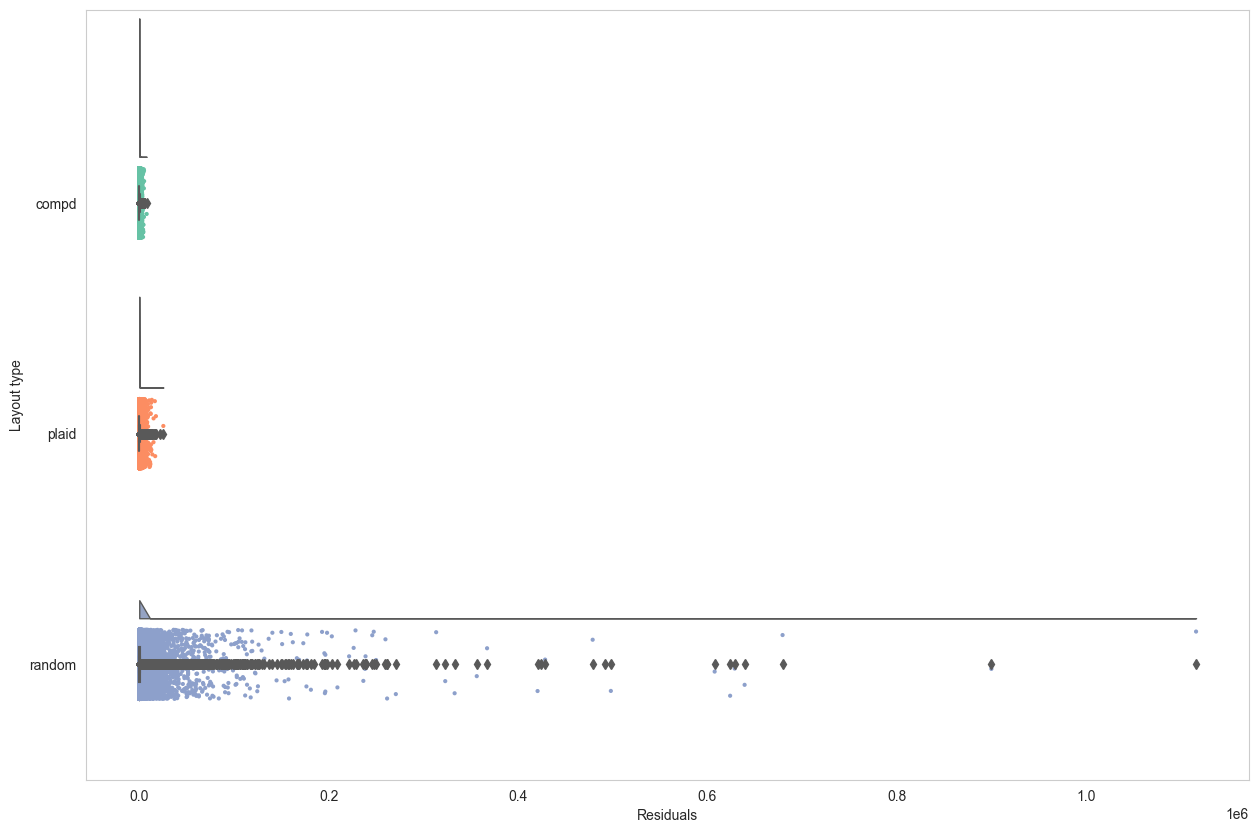

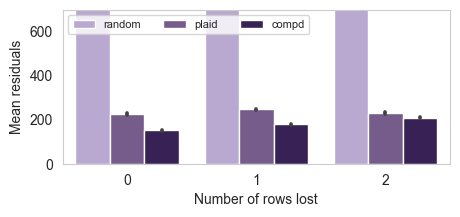

percent_non_active: 0.95
screening-residuals-10-10-0.06-pna-0.95-20250623-ROC-supplement.csv


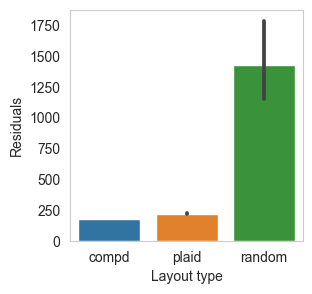

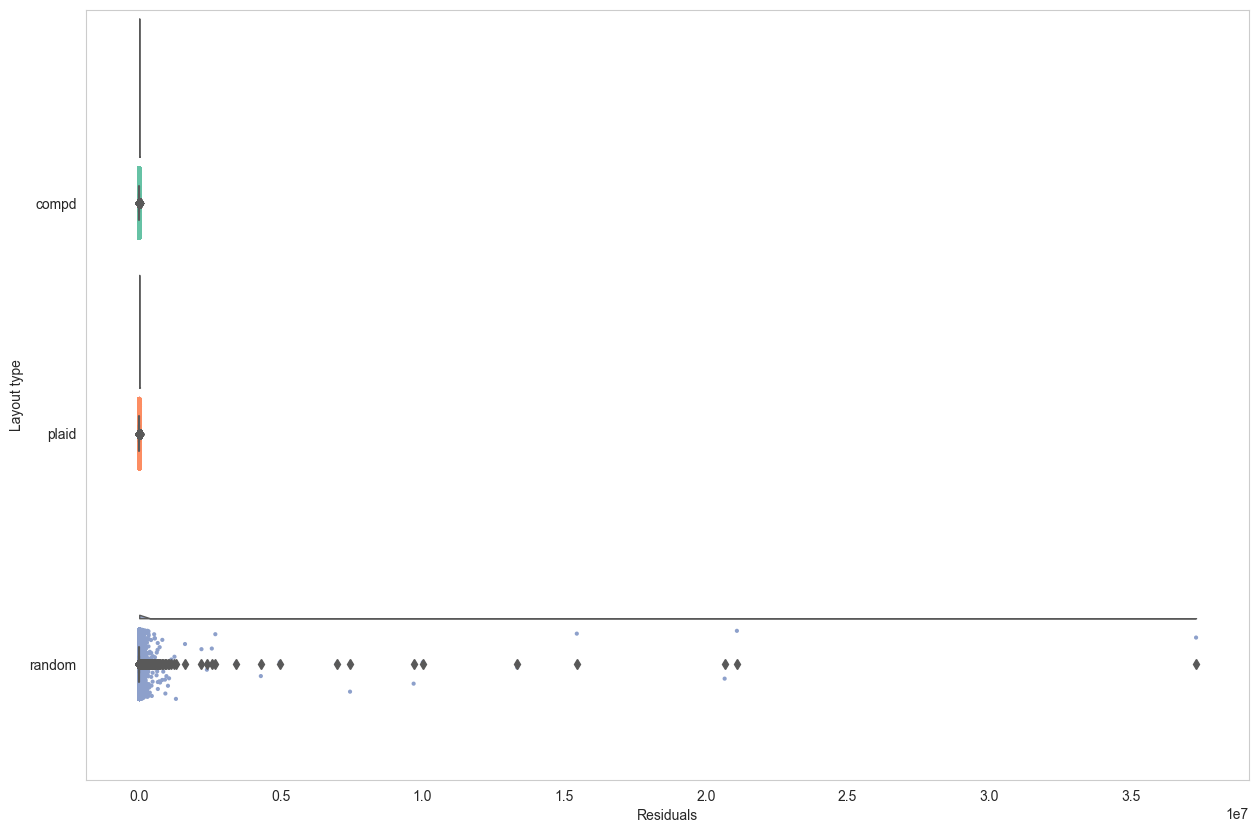

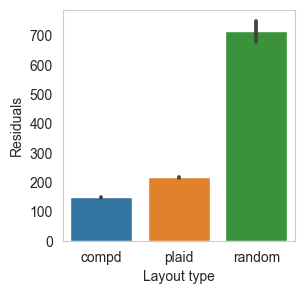

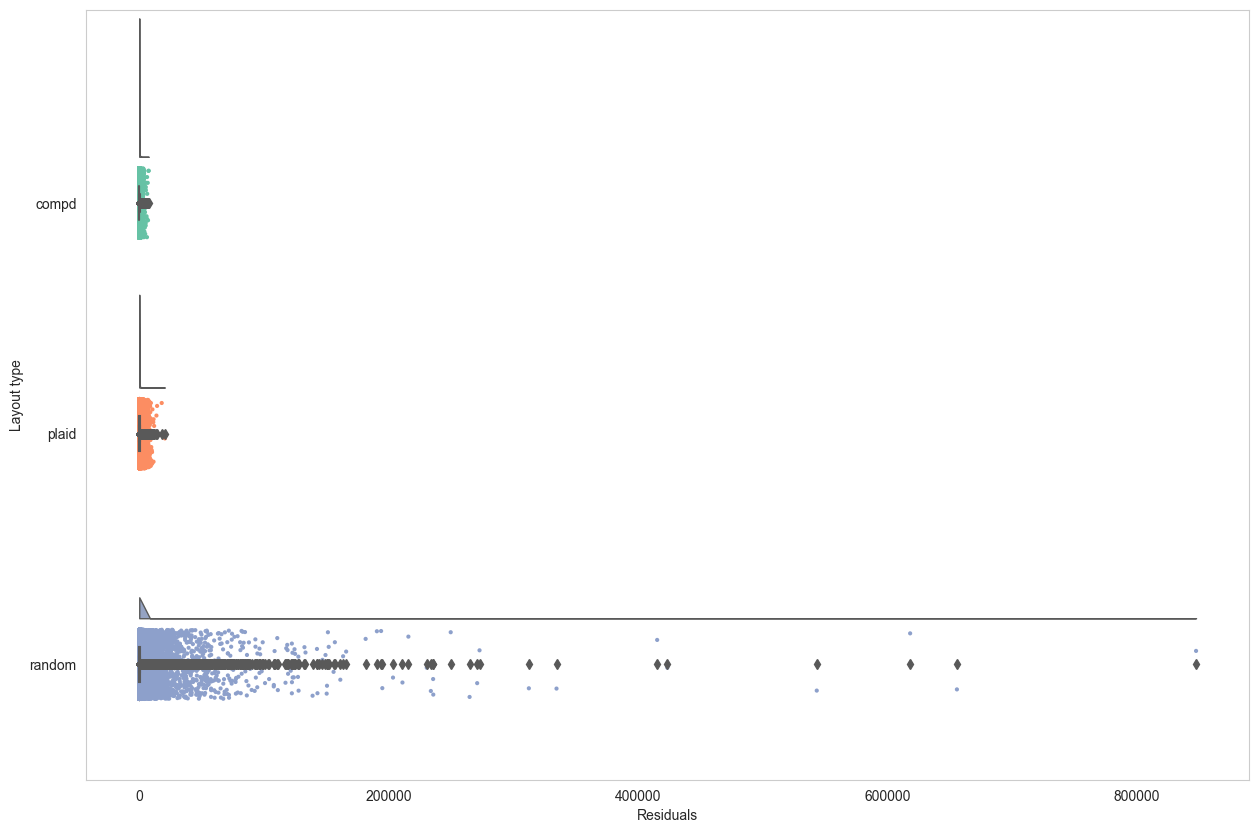

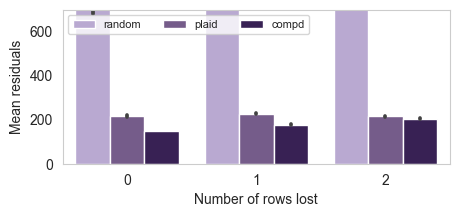

percent_non_active: 0.9
screening-residuals-10-10-0.06-pna-0.9-20250623-ROC-supplement.csv


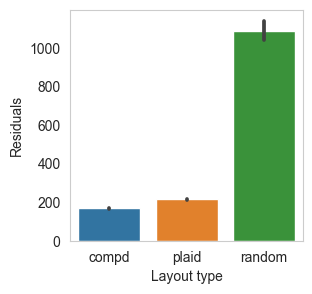

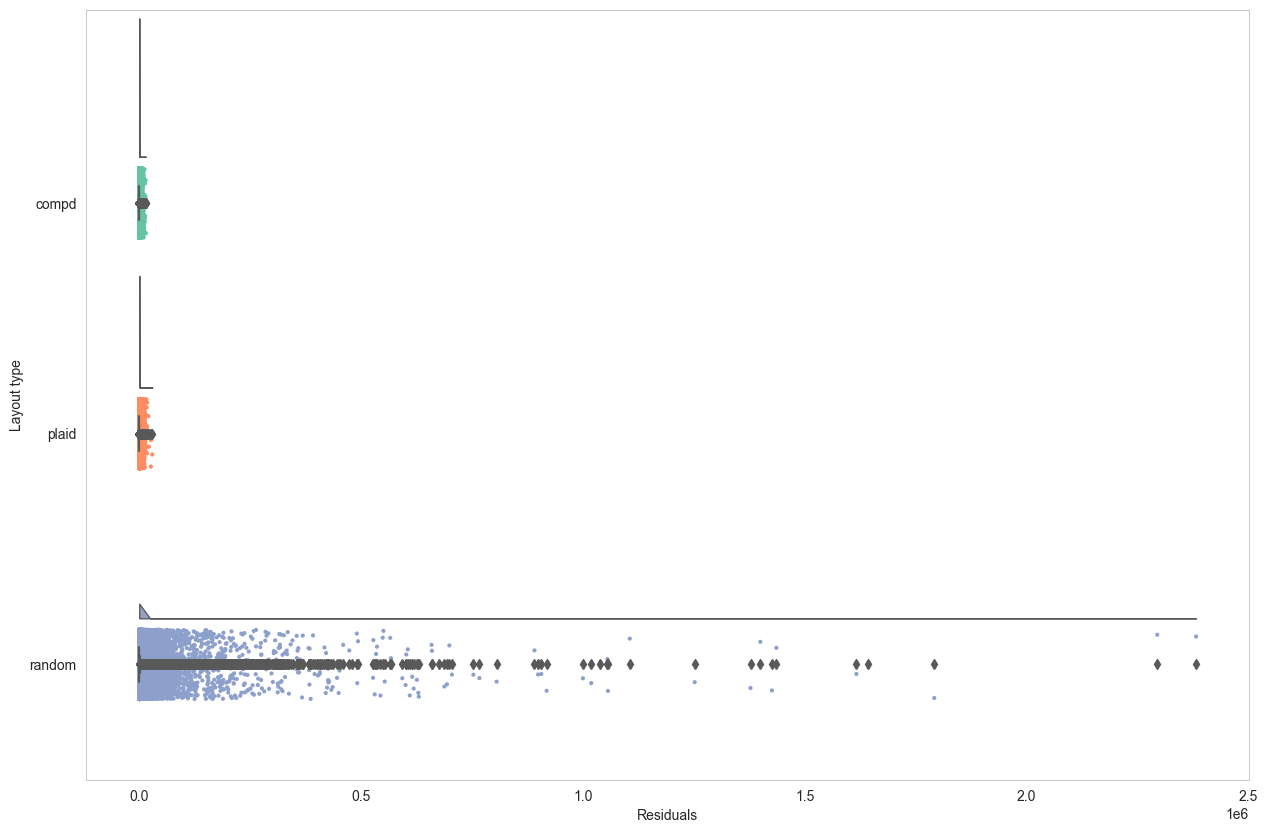

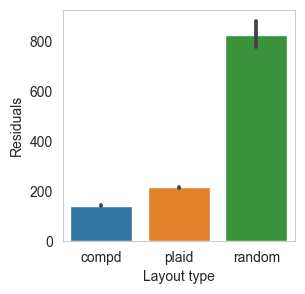

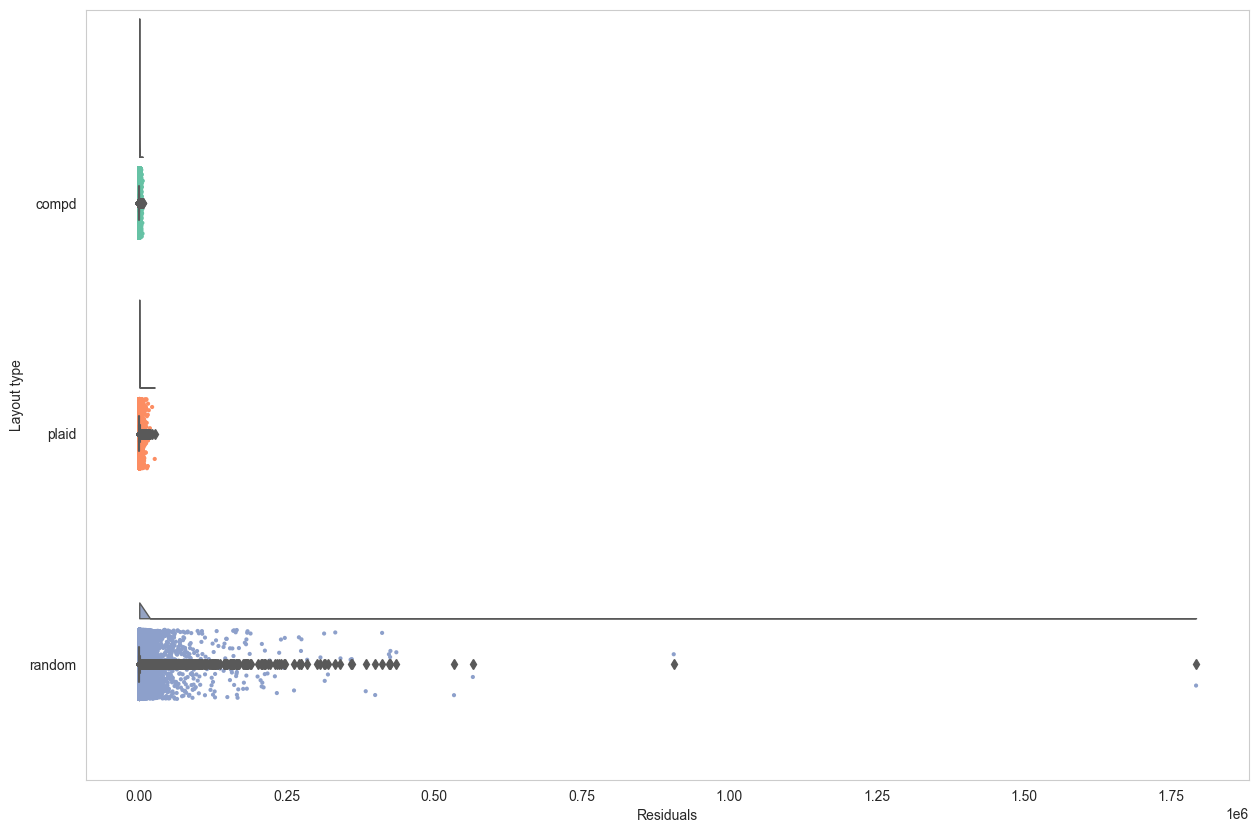

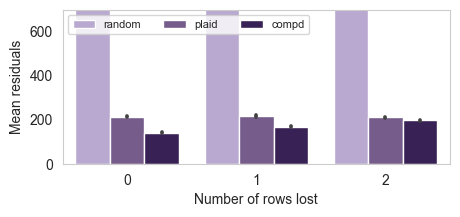

percent_non_active: 0.8
screening-residuals-10-10-0.06-pna-0.8-20250623-ROC-supplement.csv


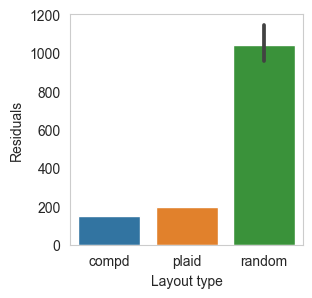

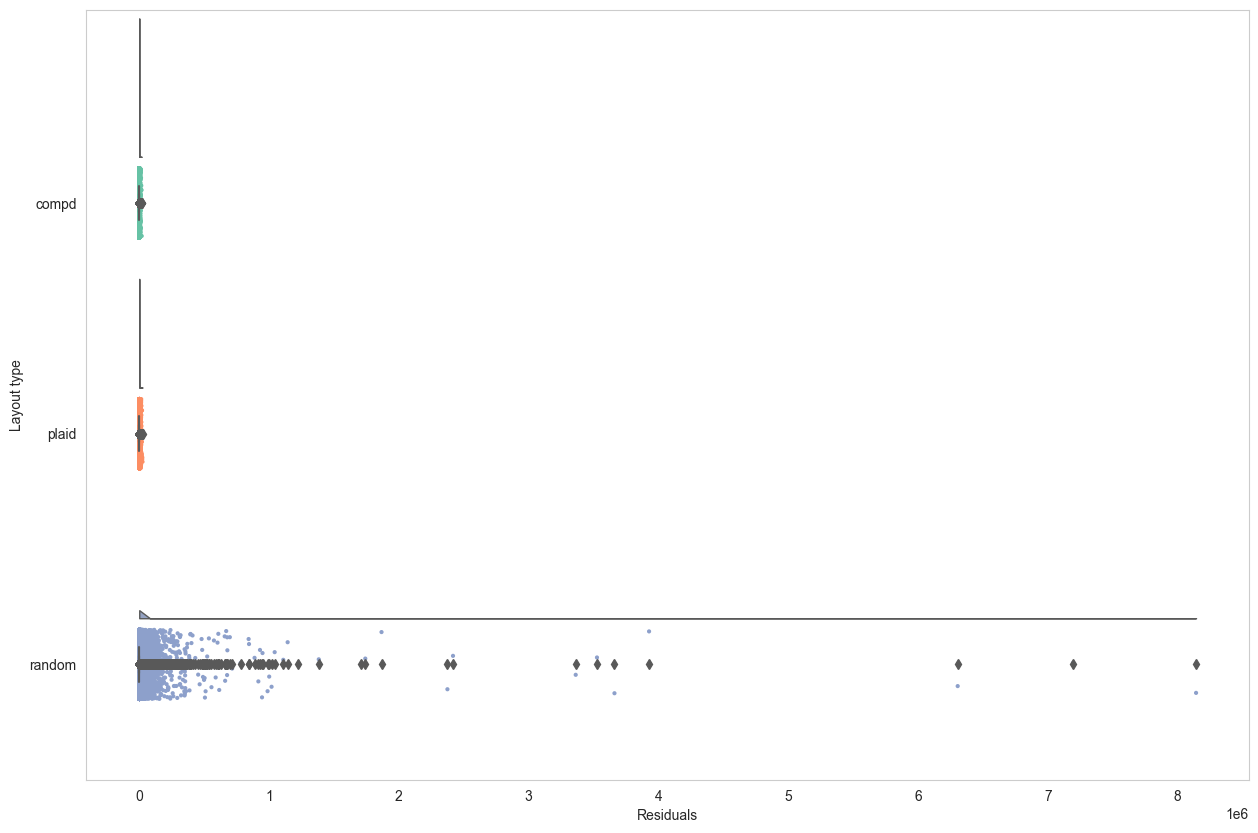

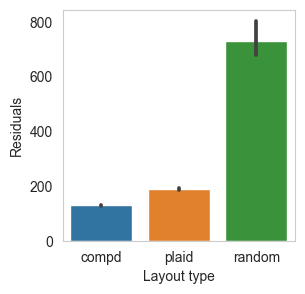

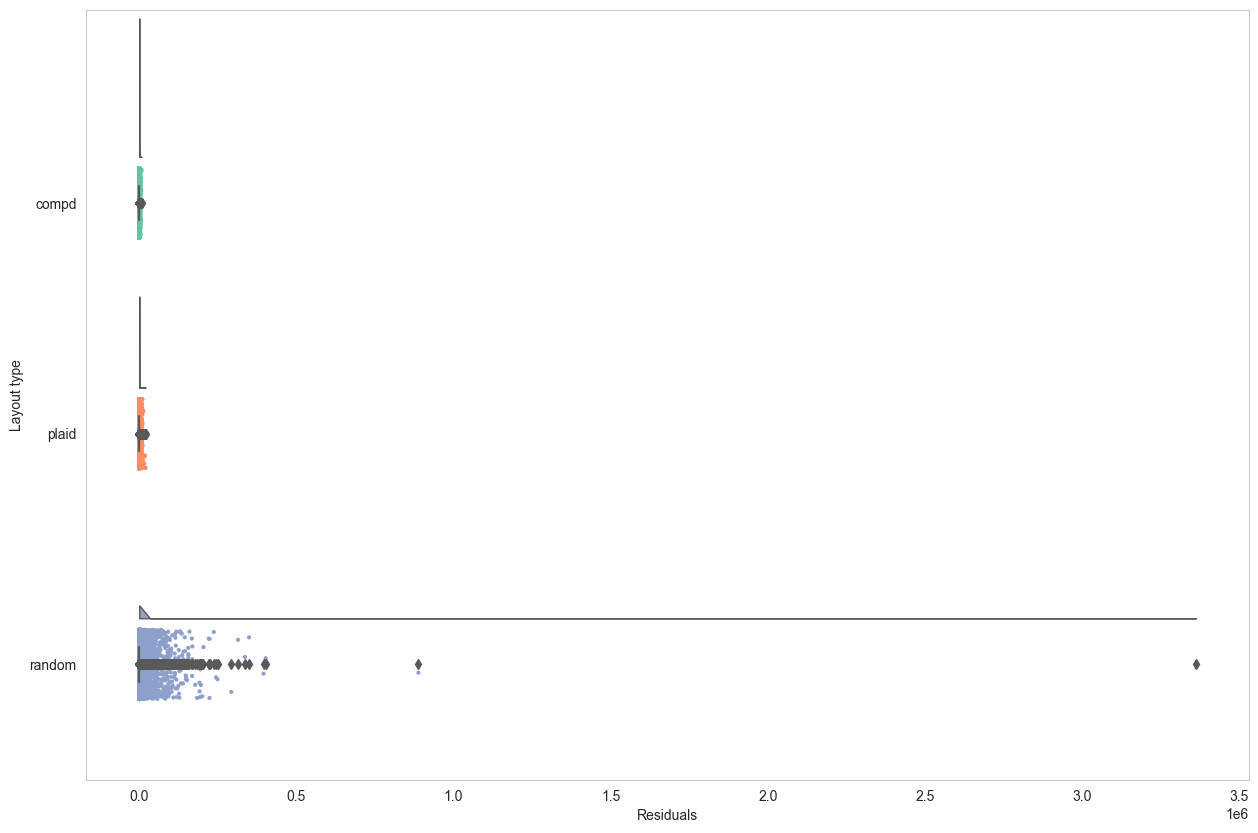

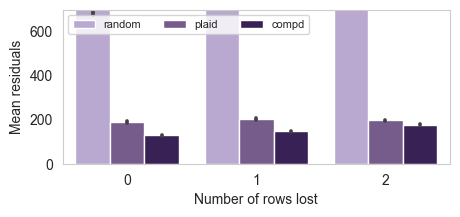

percent_non_active: 0.7
screening-residuals-10-10-0.06-pna-0.7-20250623-ROC-supplement.csv


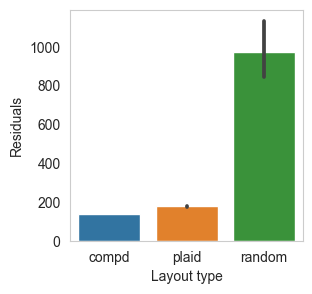

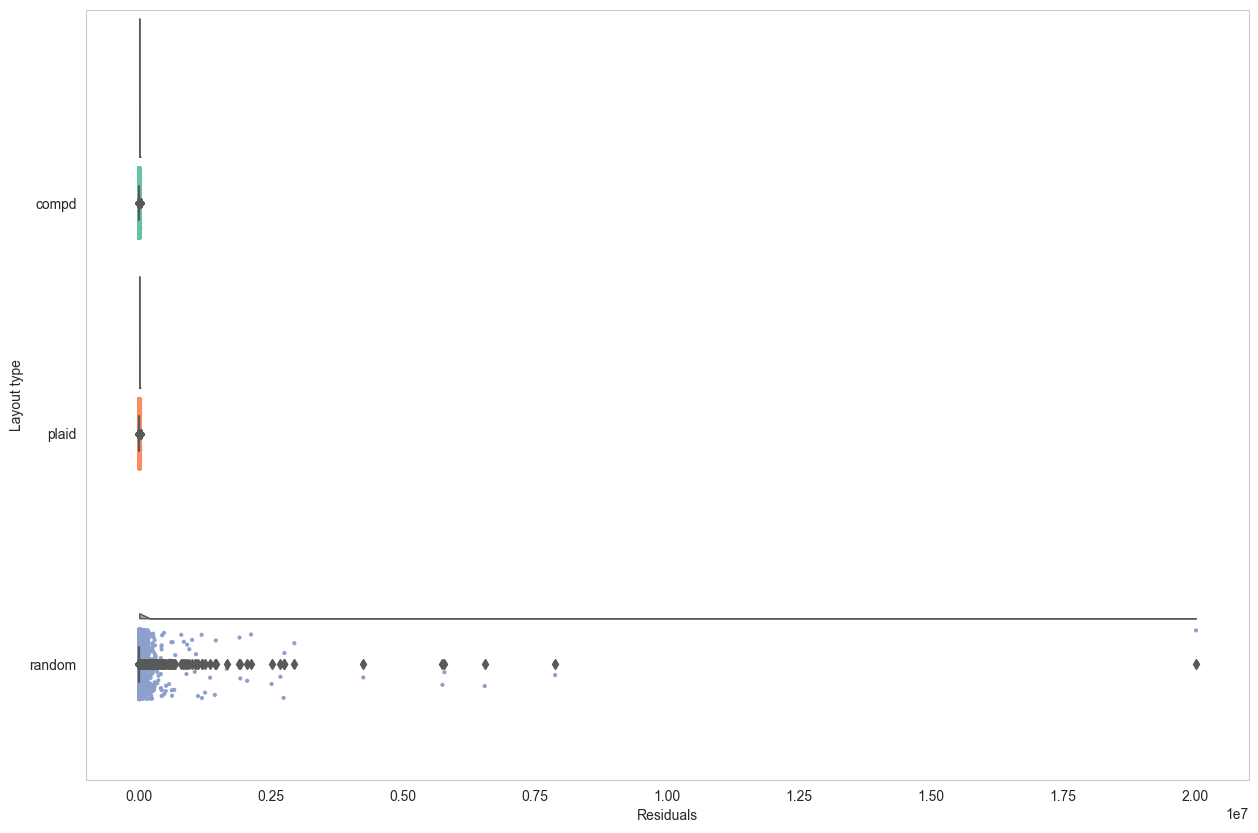

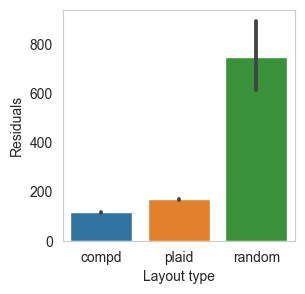

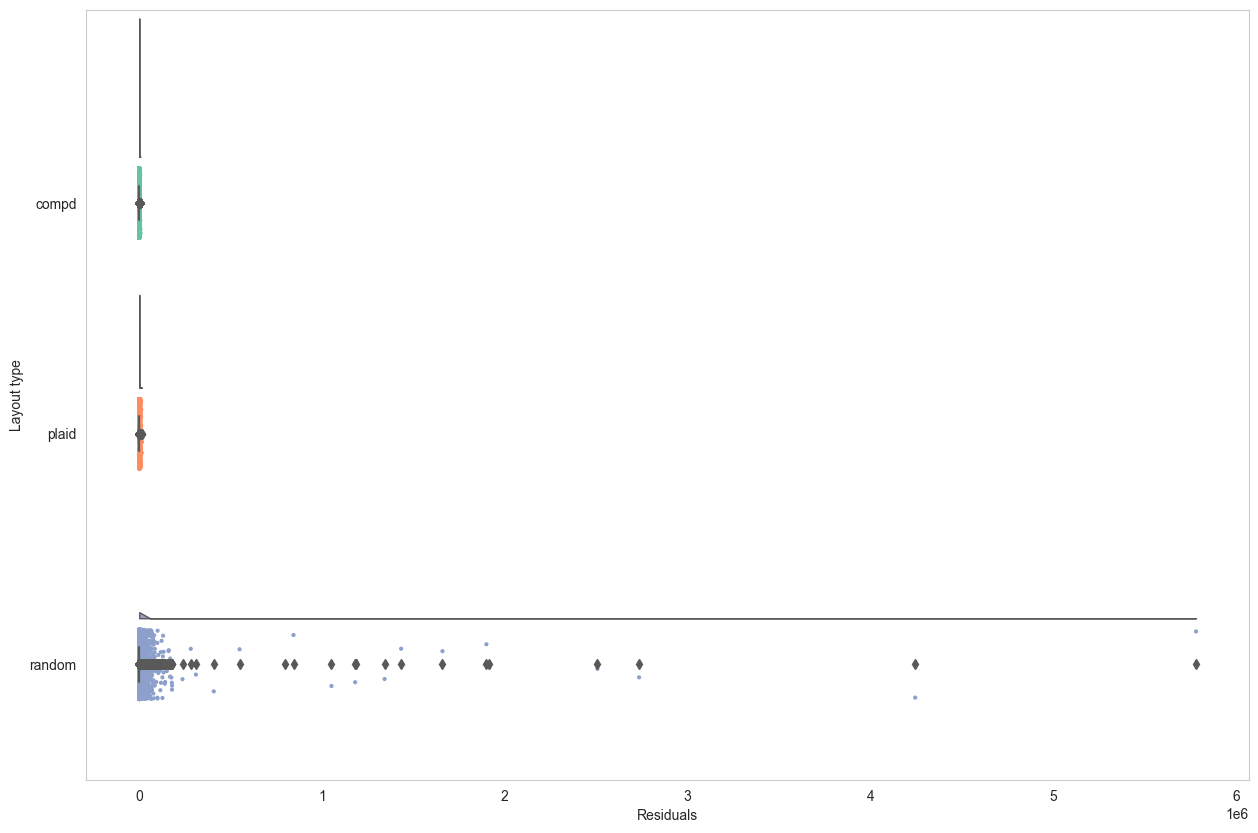

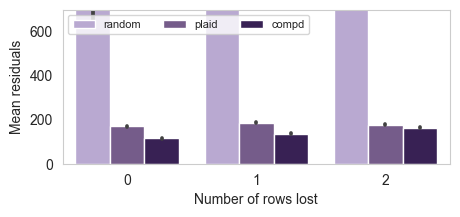

percent_non_active: 0.6
screening-residuals-10-10-0.06-pna-0.6-20250623-ROC-supplement.csv


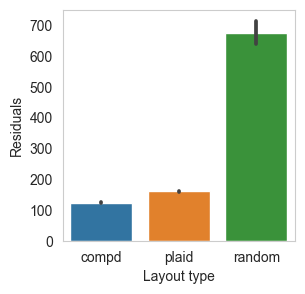

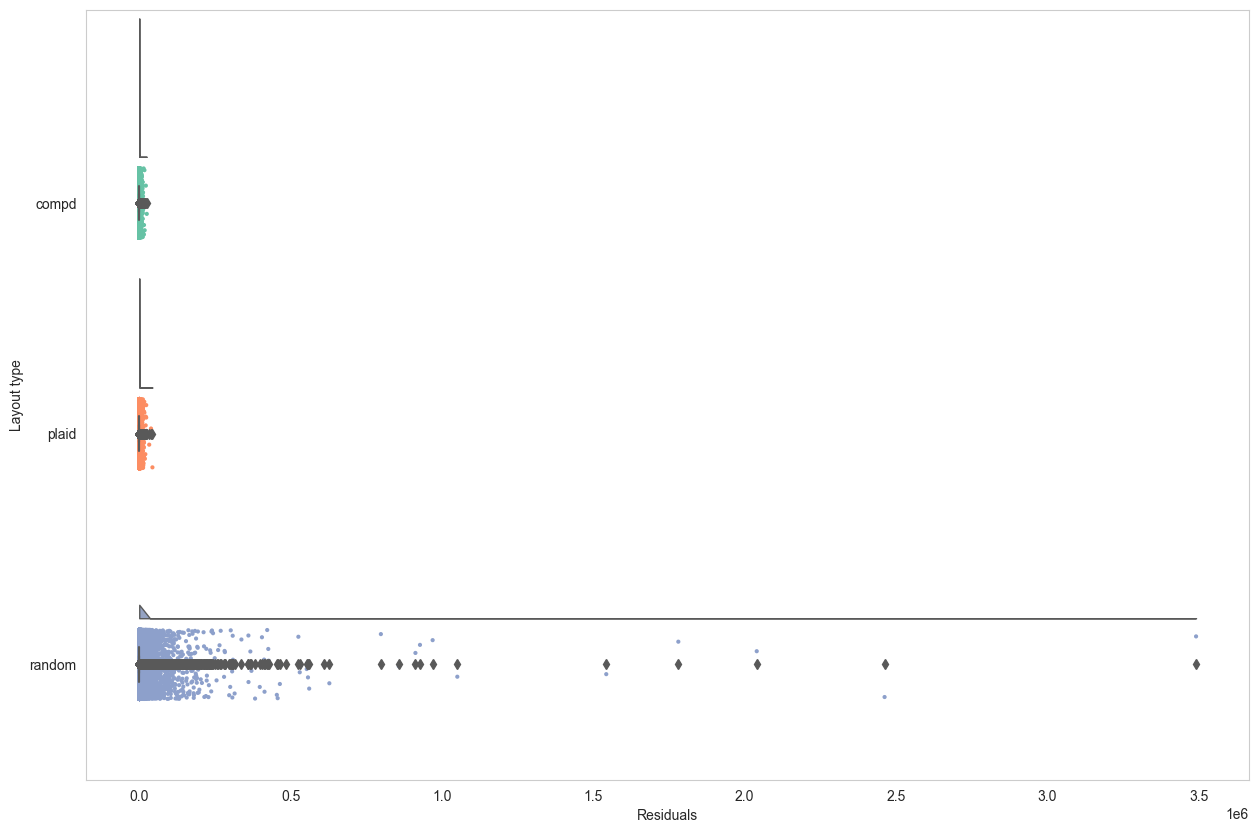

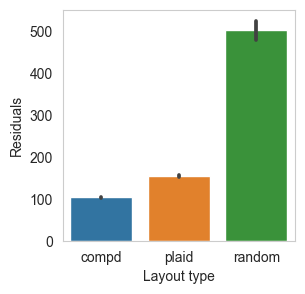

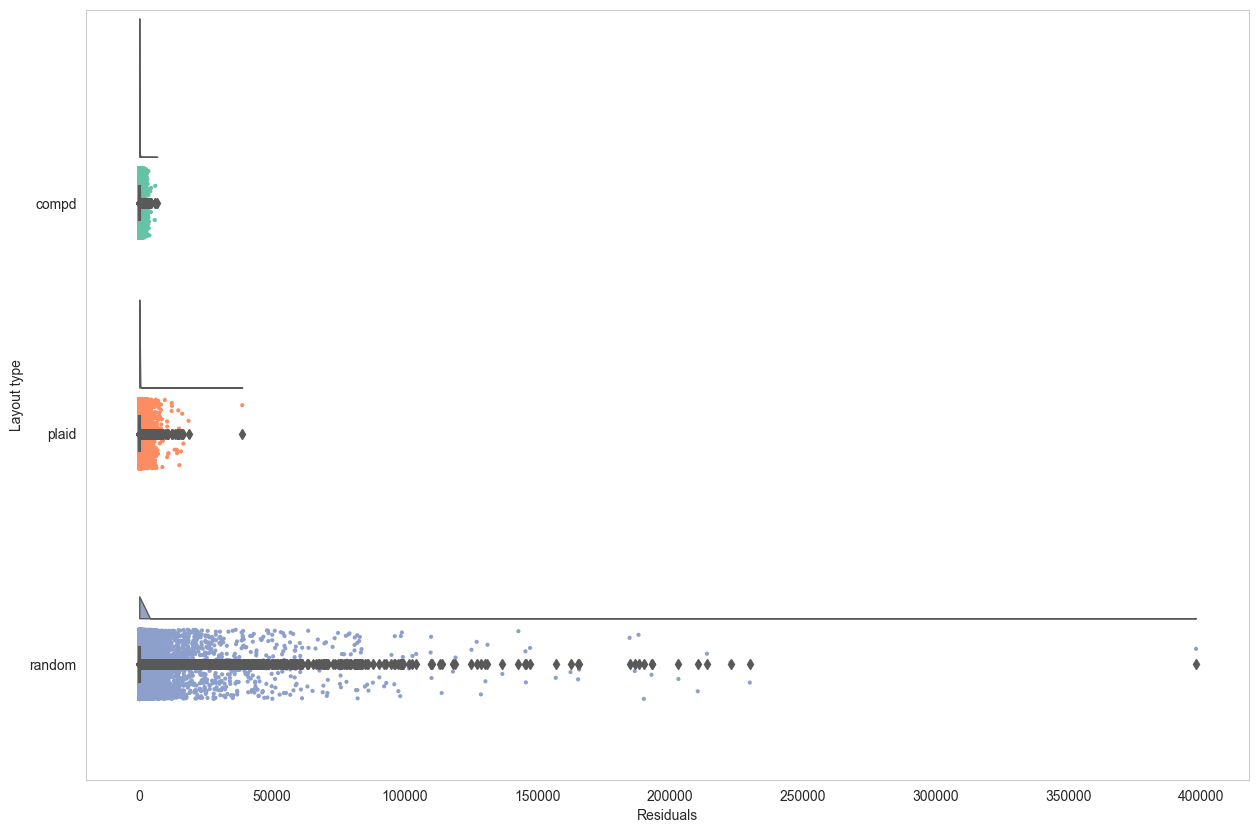

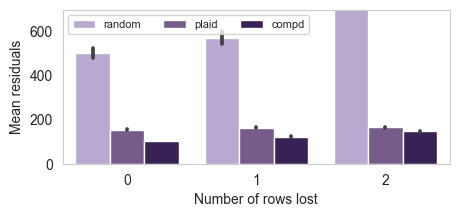

error: 0.1
percent_non_active: 0.99
screening-residuals-10-10-0.1-pna-0.99-20250623-ROC-supplement.csv


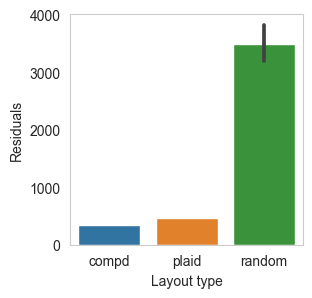

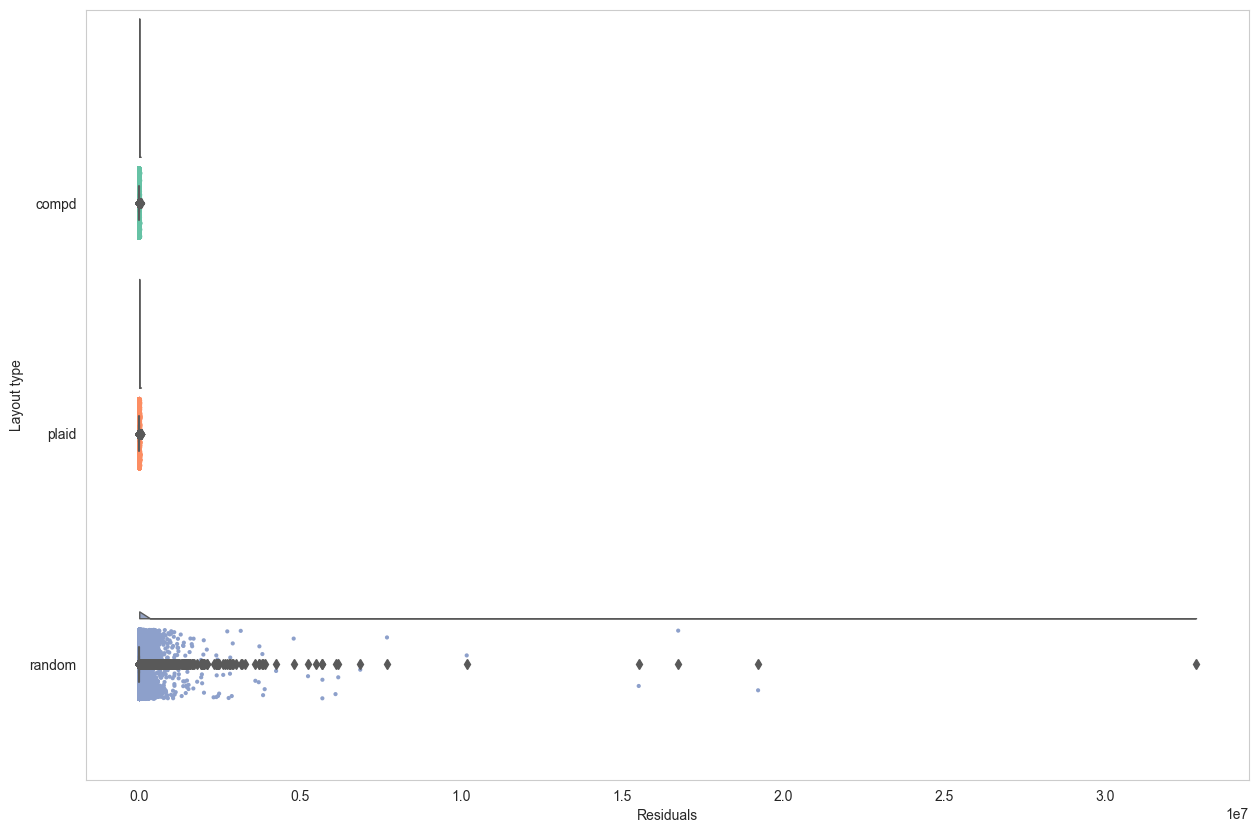

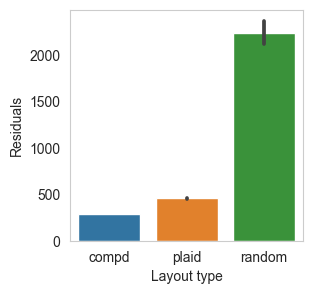

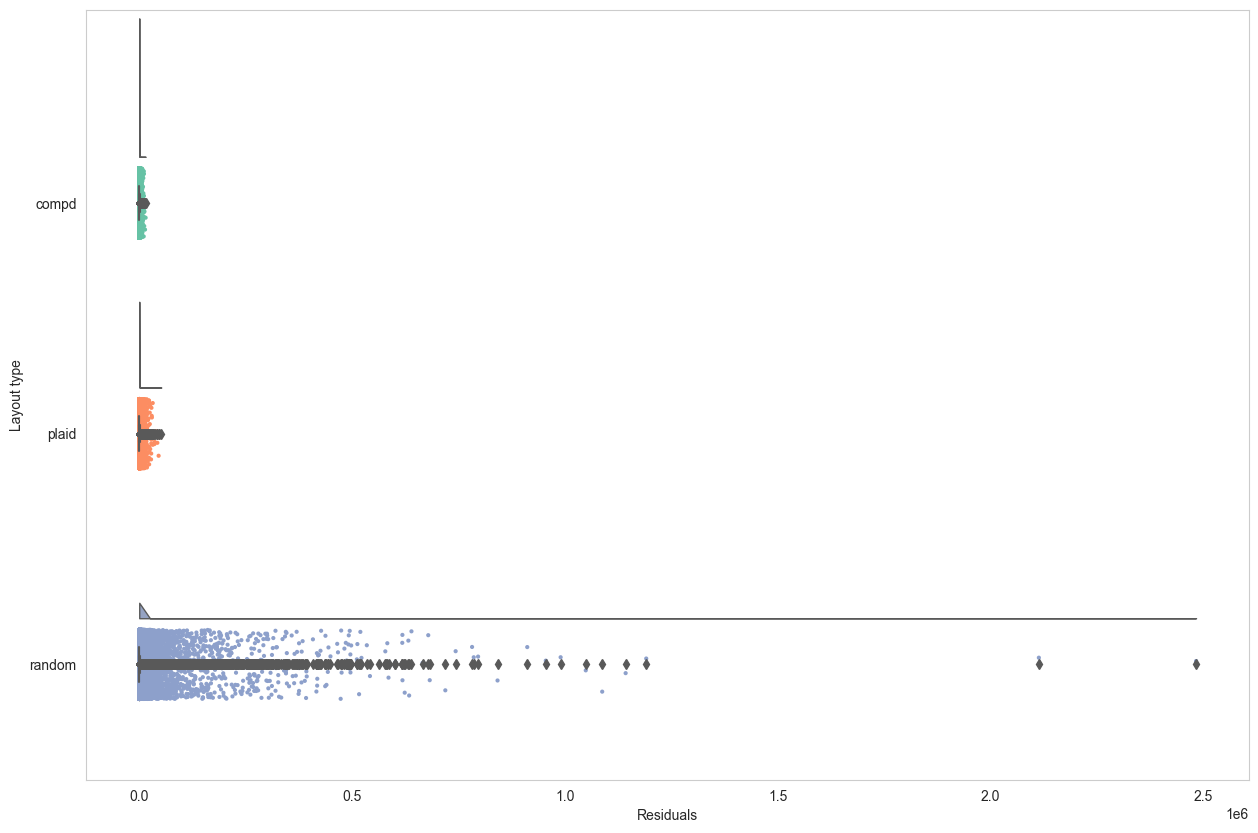

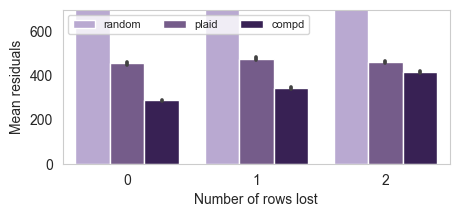

percent_non_active: 0.95
screening-residuals-10-10-0.1-pna-0.95-20250623-ROC-supplement.csv


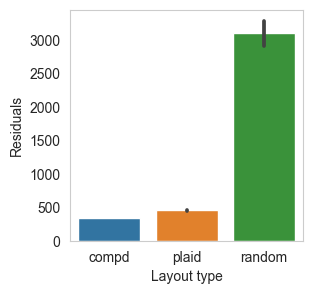

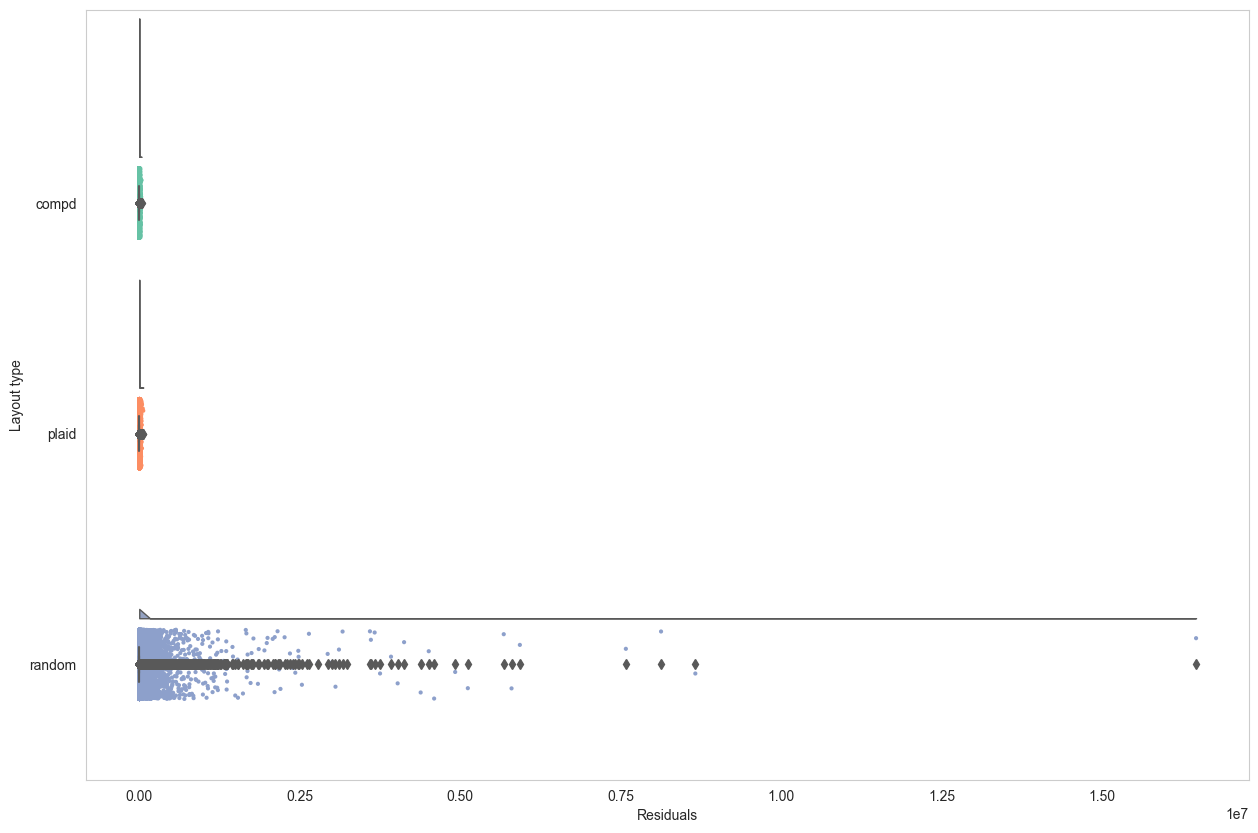

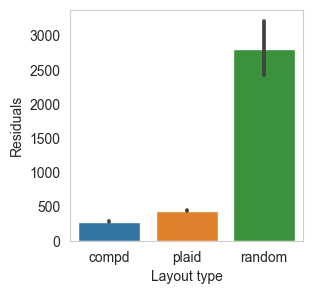

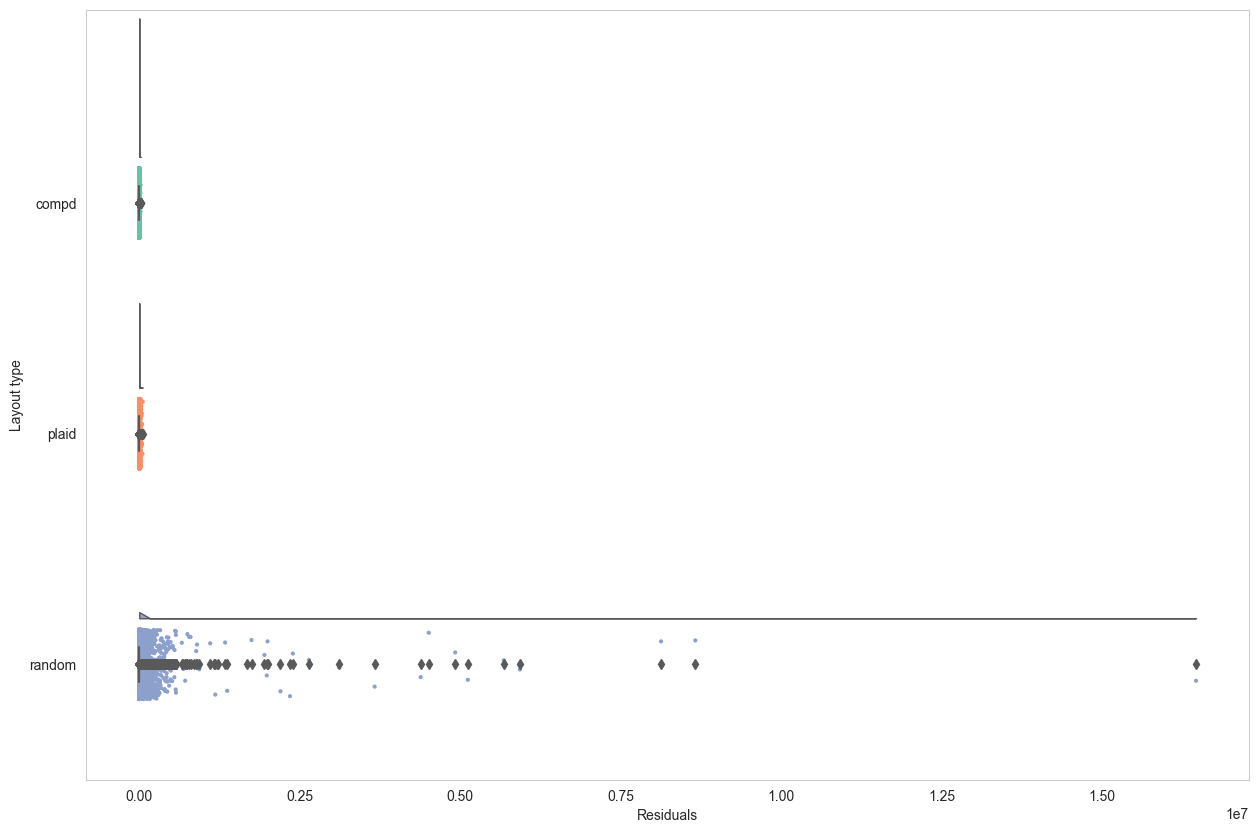

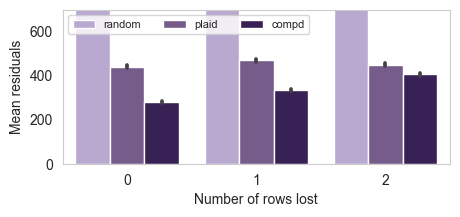

percent_non_active: 0.9
screening-residuals-10-10-0.1-pna-0.9-20250623-ROC-supplement.csv


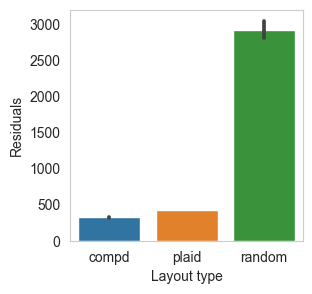

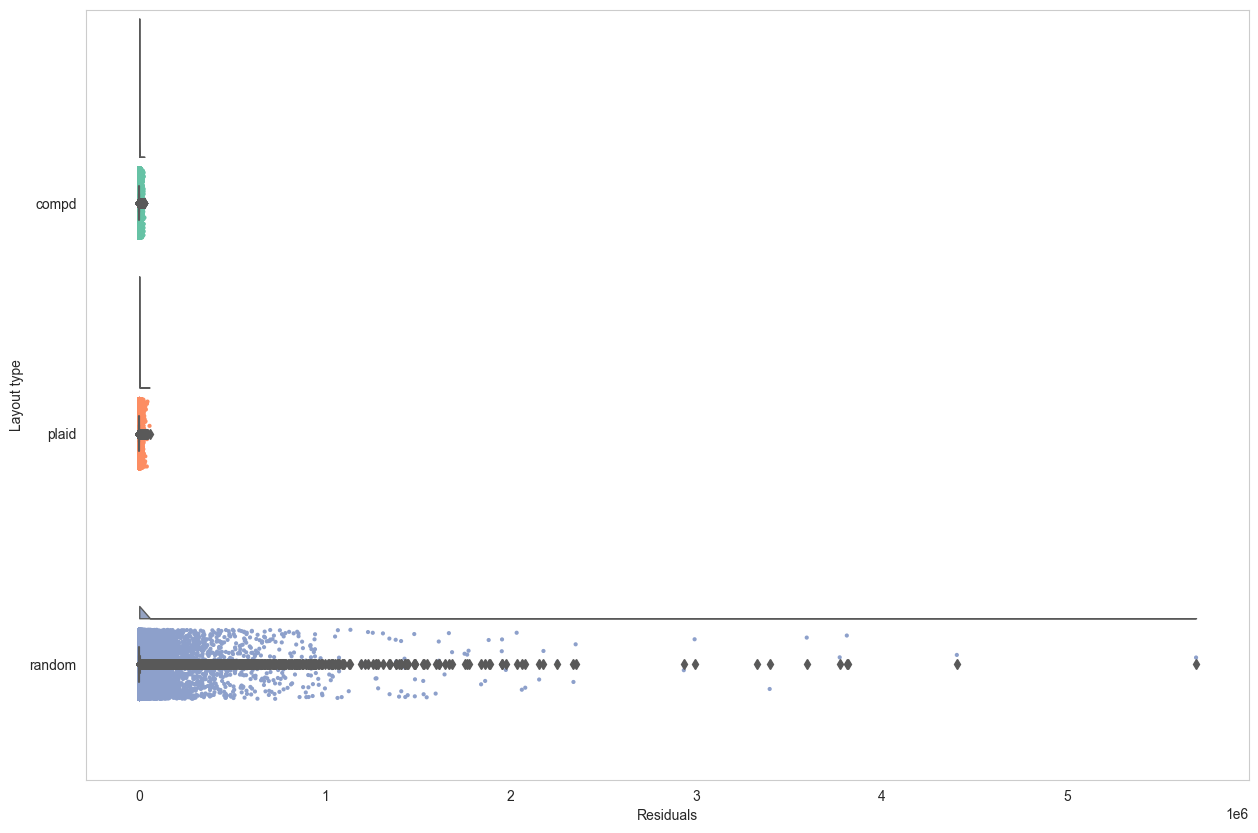

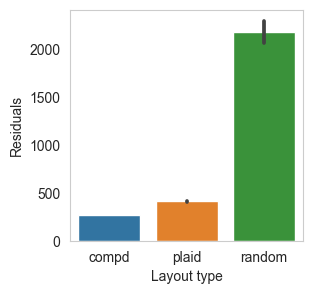

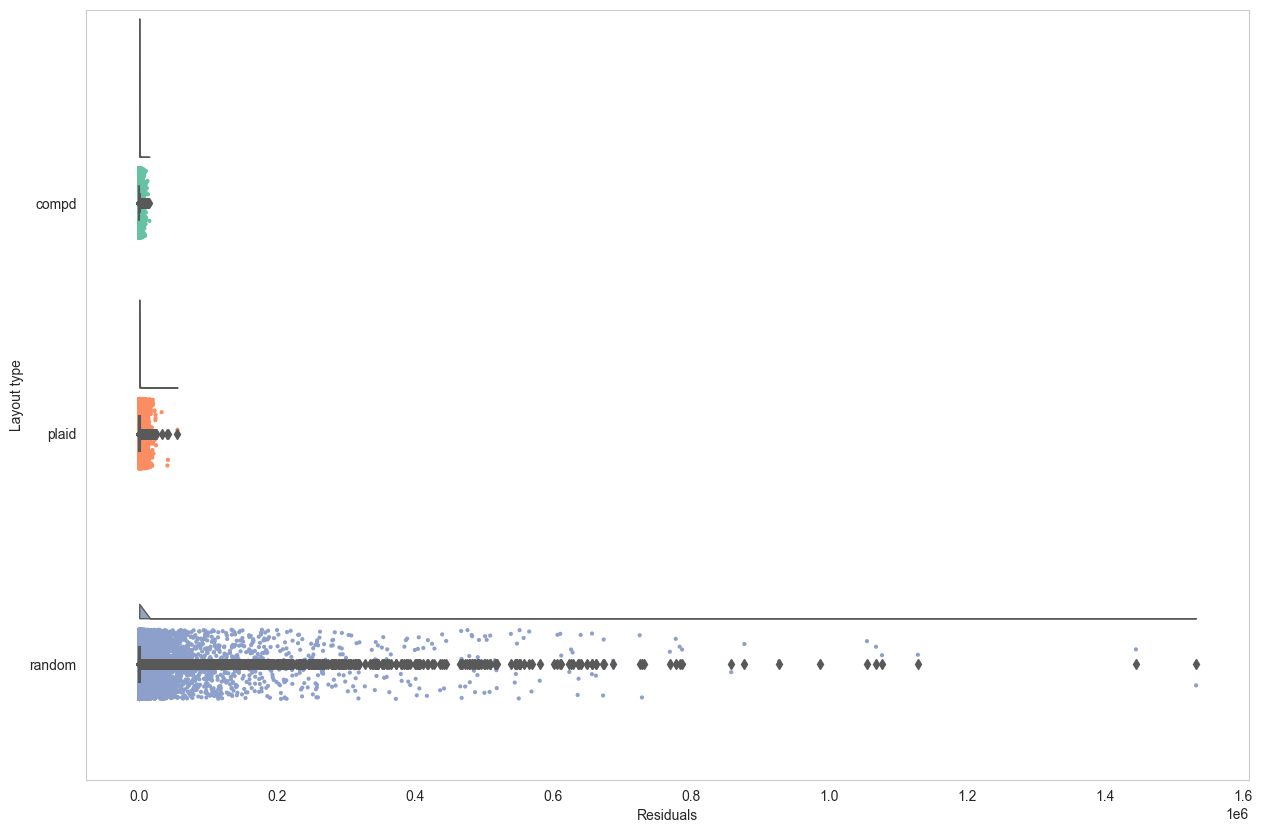

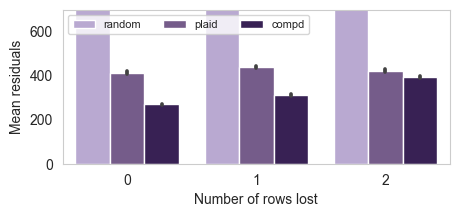

percent_non_active: 0.8
screening-residuals-10-10-0.1-pna-0.8-20250623-ROC-supplement.csv


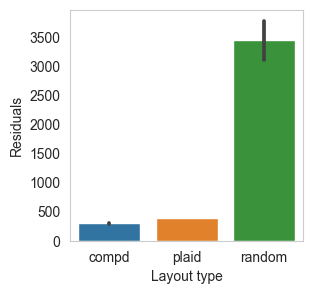

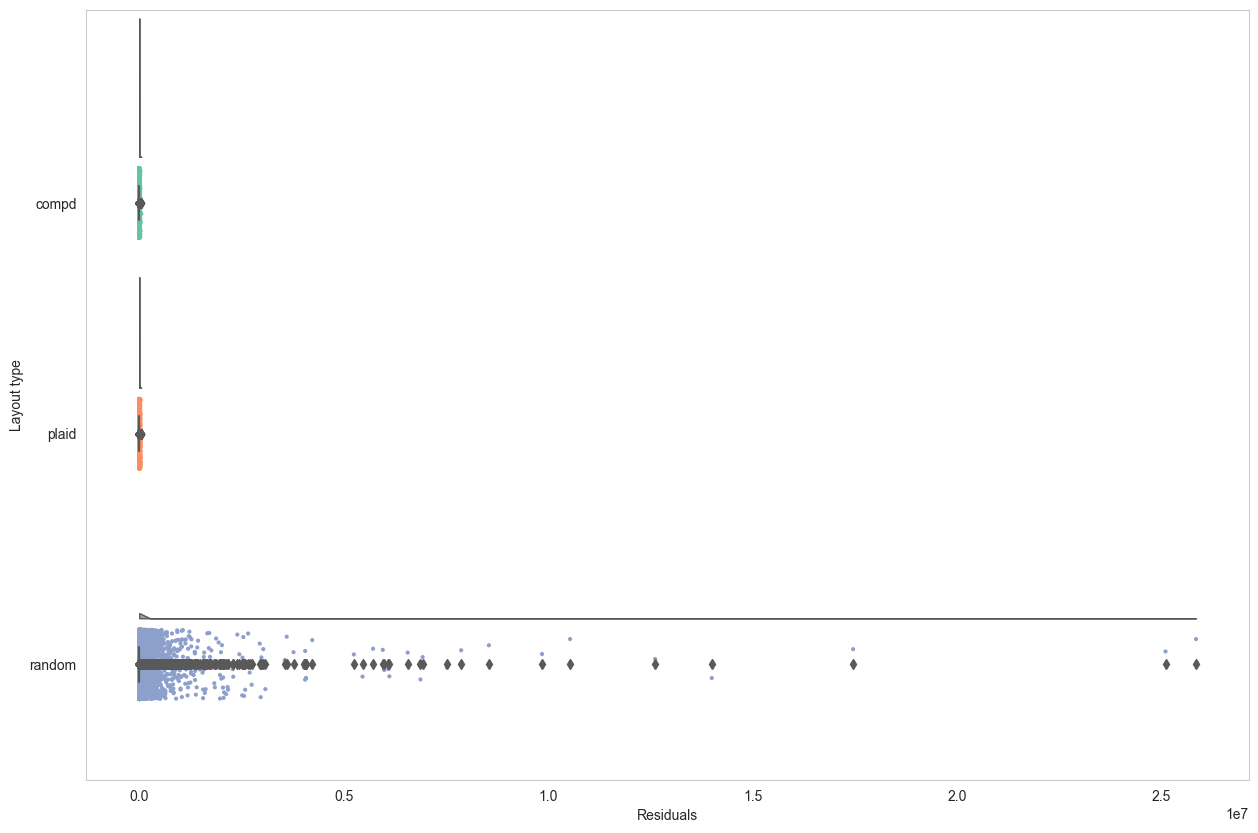

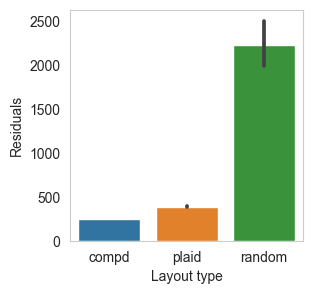

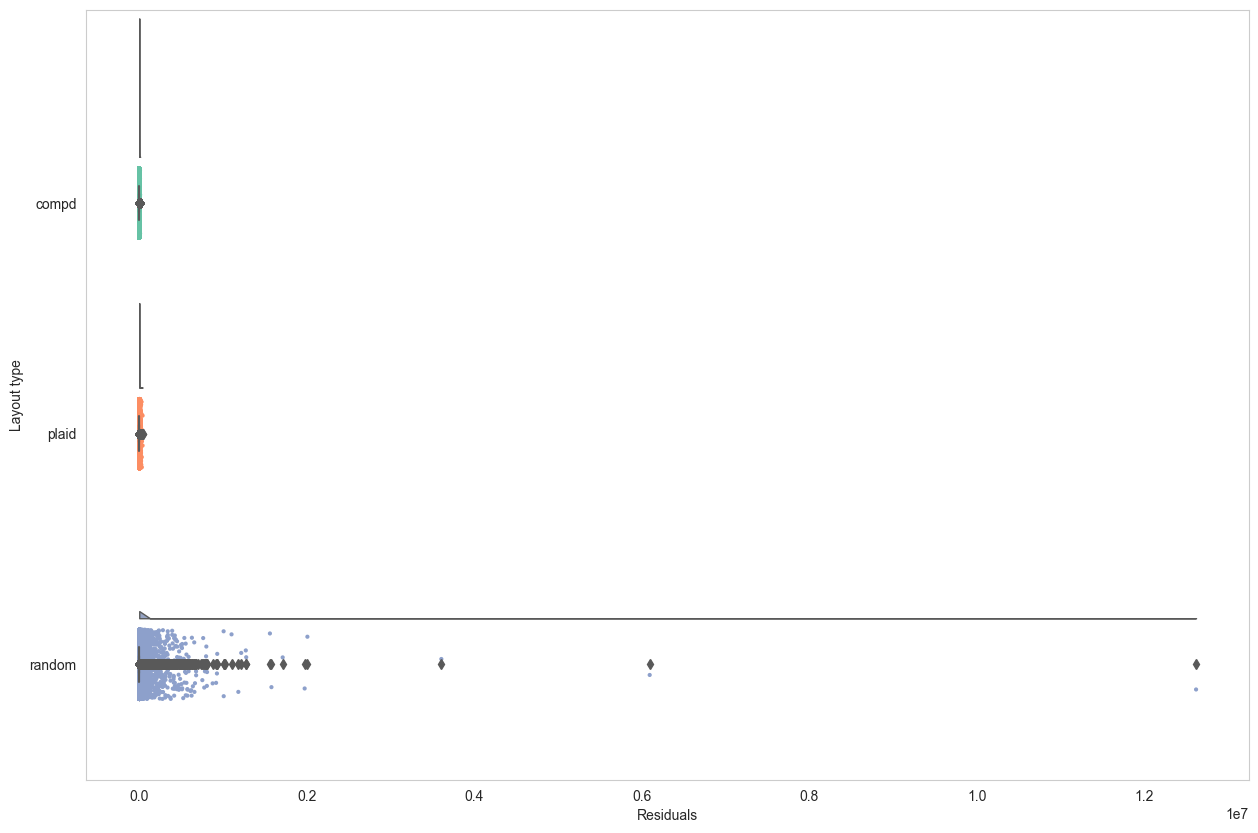

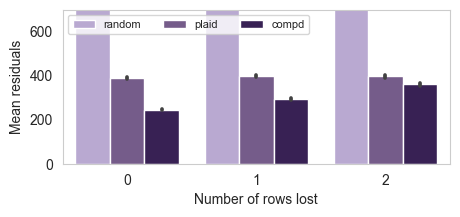

percent_non_active: 0.7
screening-residuals-10-10-0.1-pna-0.7-20250623-ROC-supplement.csv


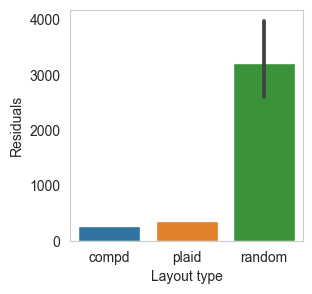

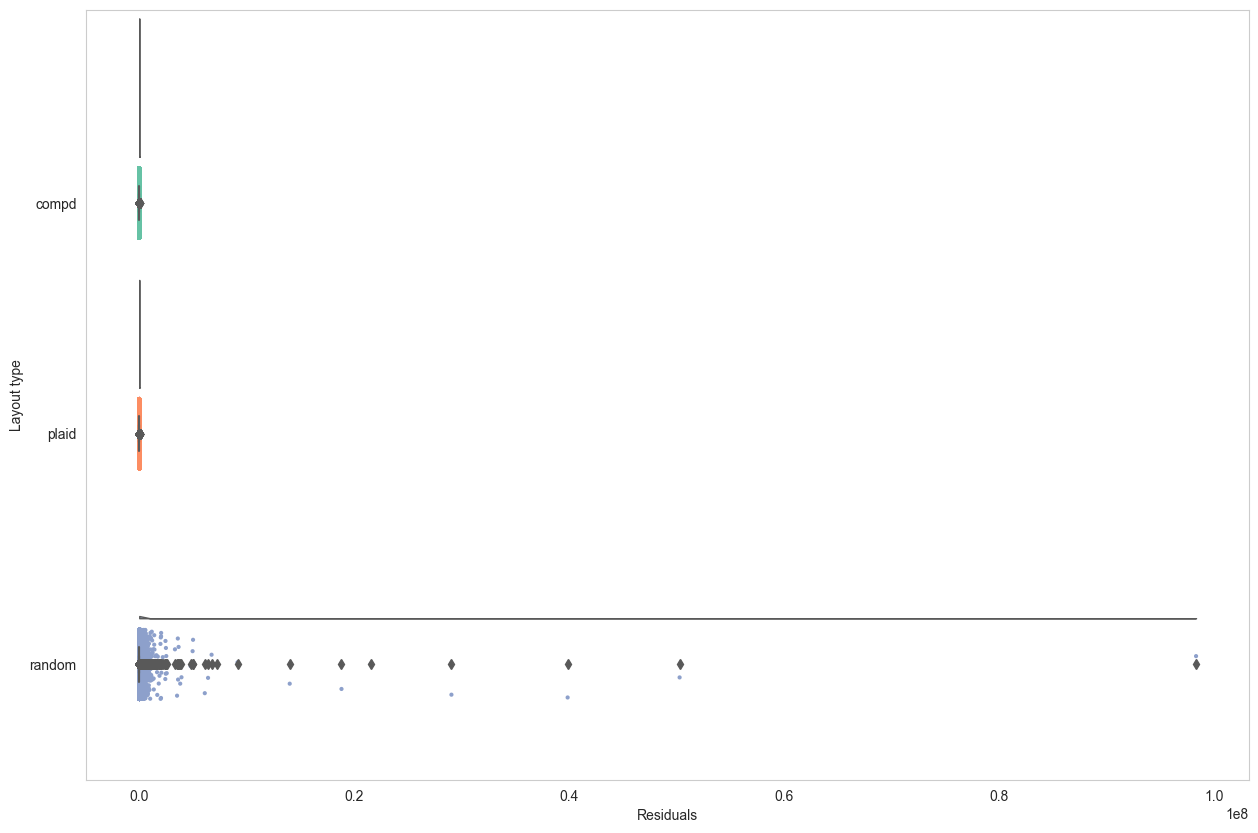

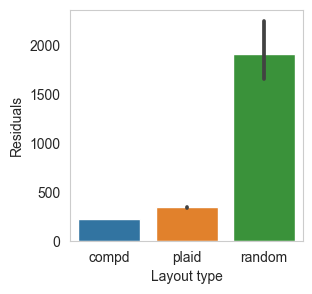

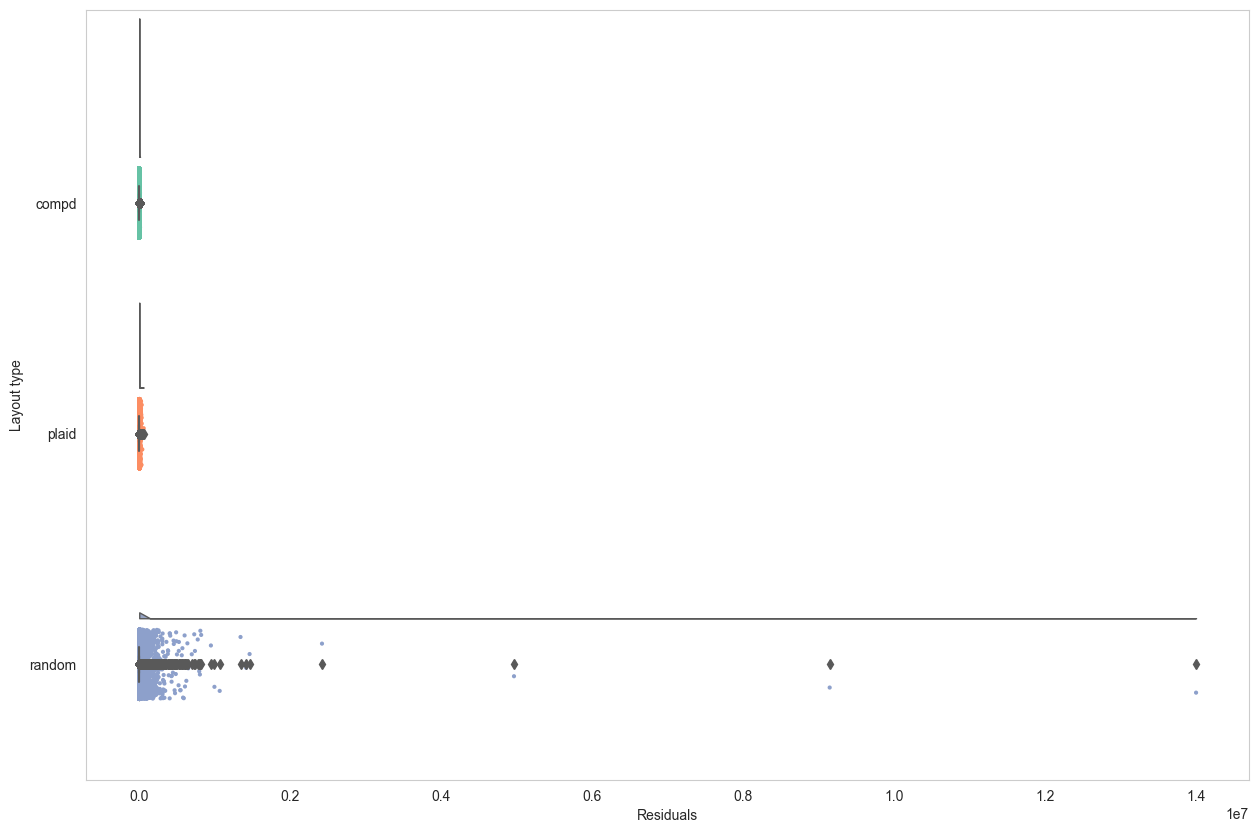

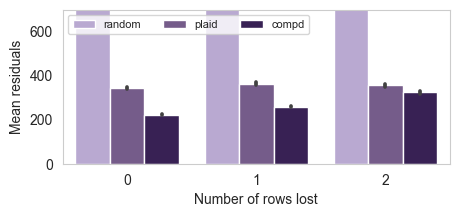

percent_non_active: 0.6
screening-residuals-10-10-0.1-pna-0.6-20250623-ROC-supplement.csv


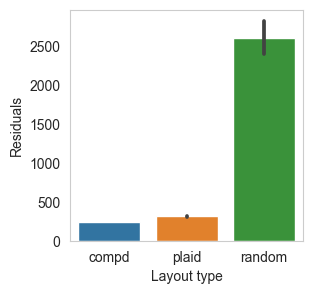

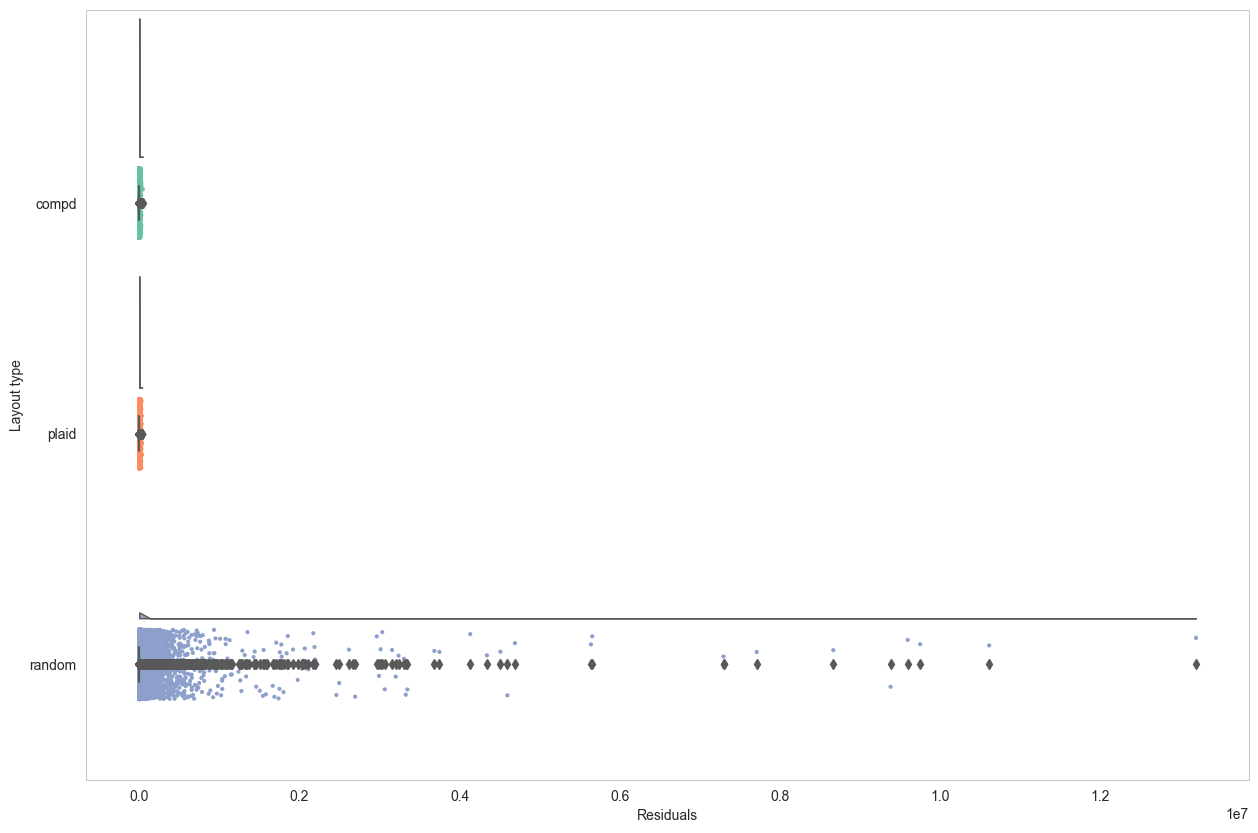

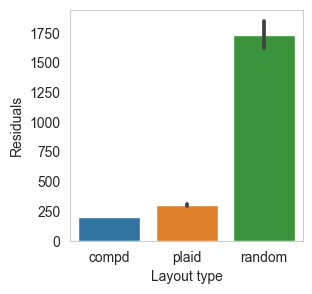

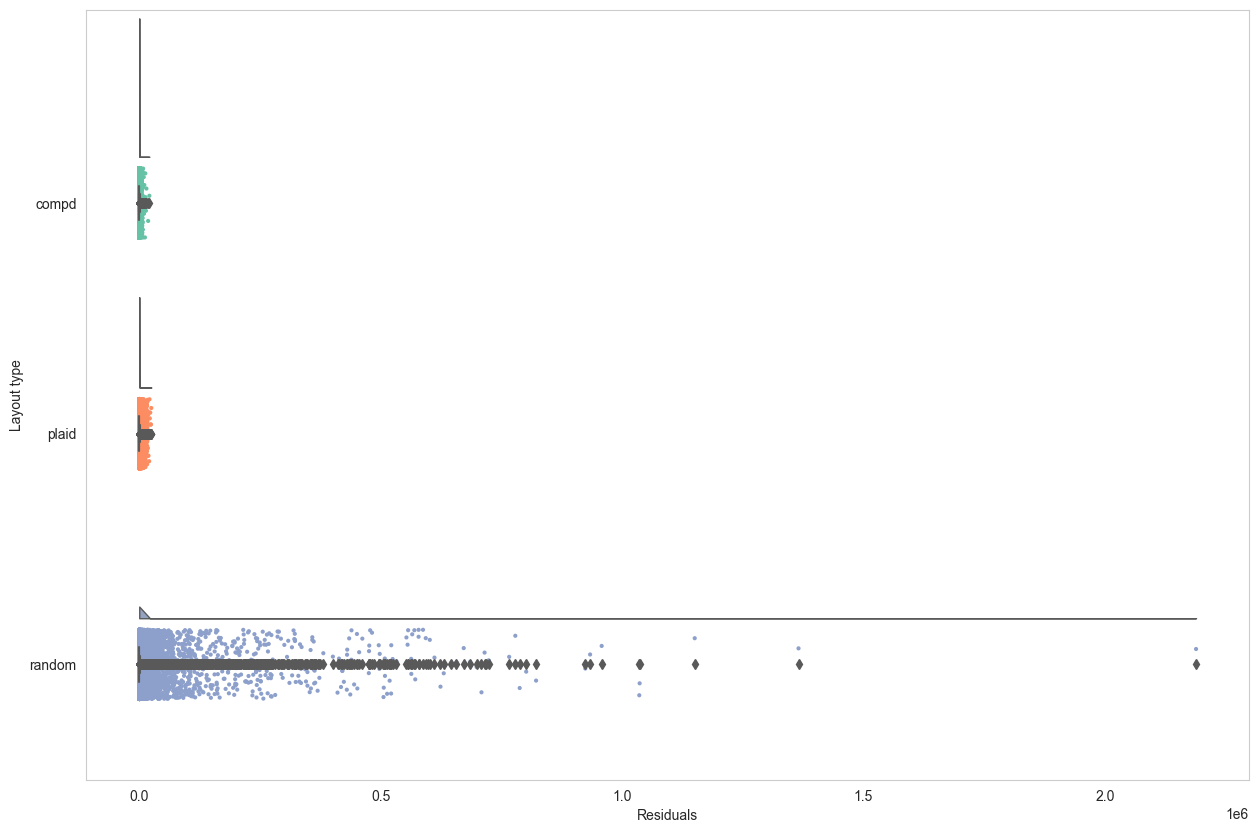

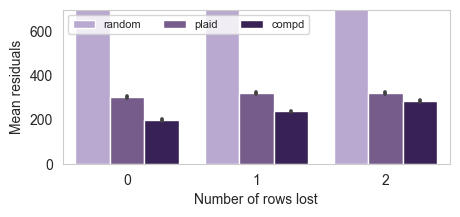

error: 0.2
percent_non_active: 0.99
screening-residuals-10-10-0.2-pna-0.99-20250623-ROC-supplement.csv


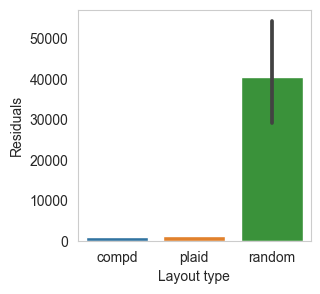

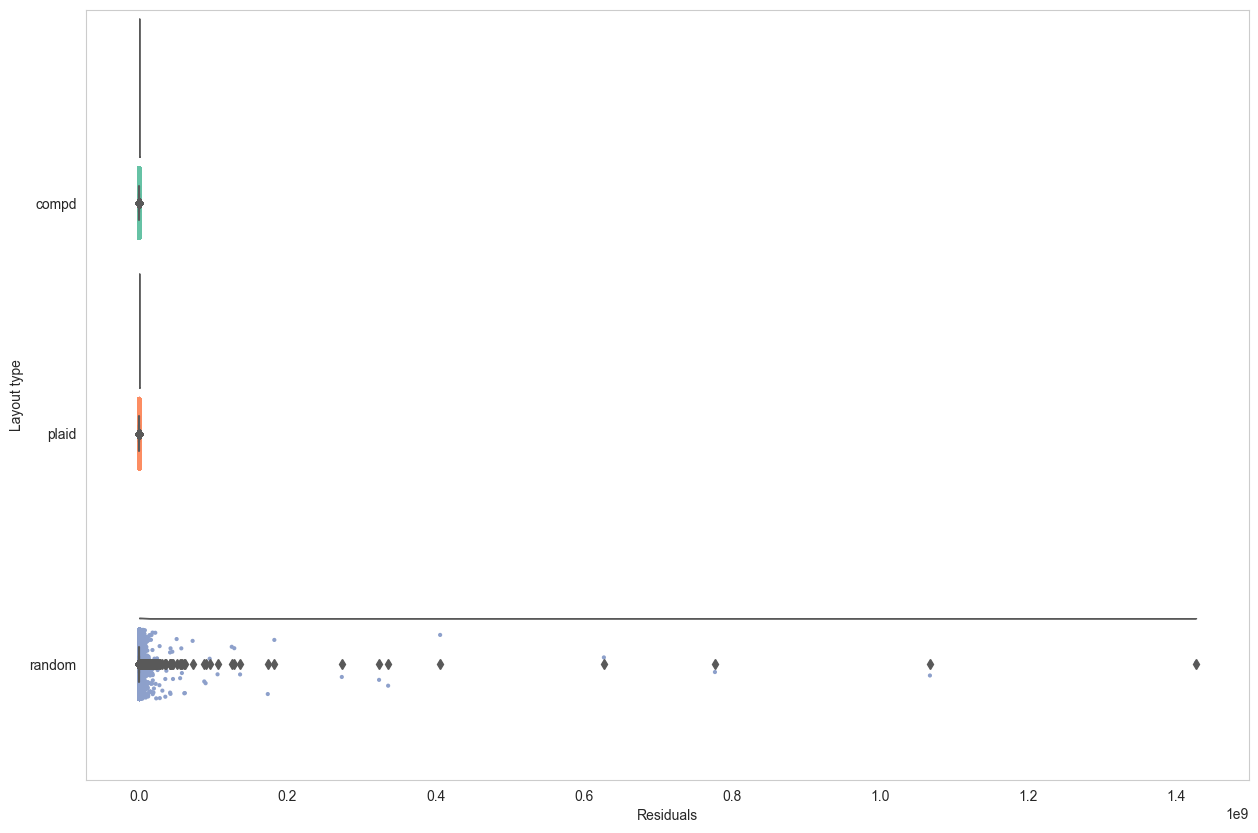

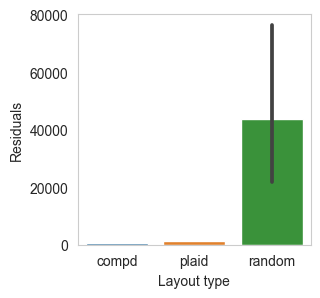

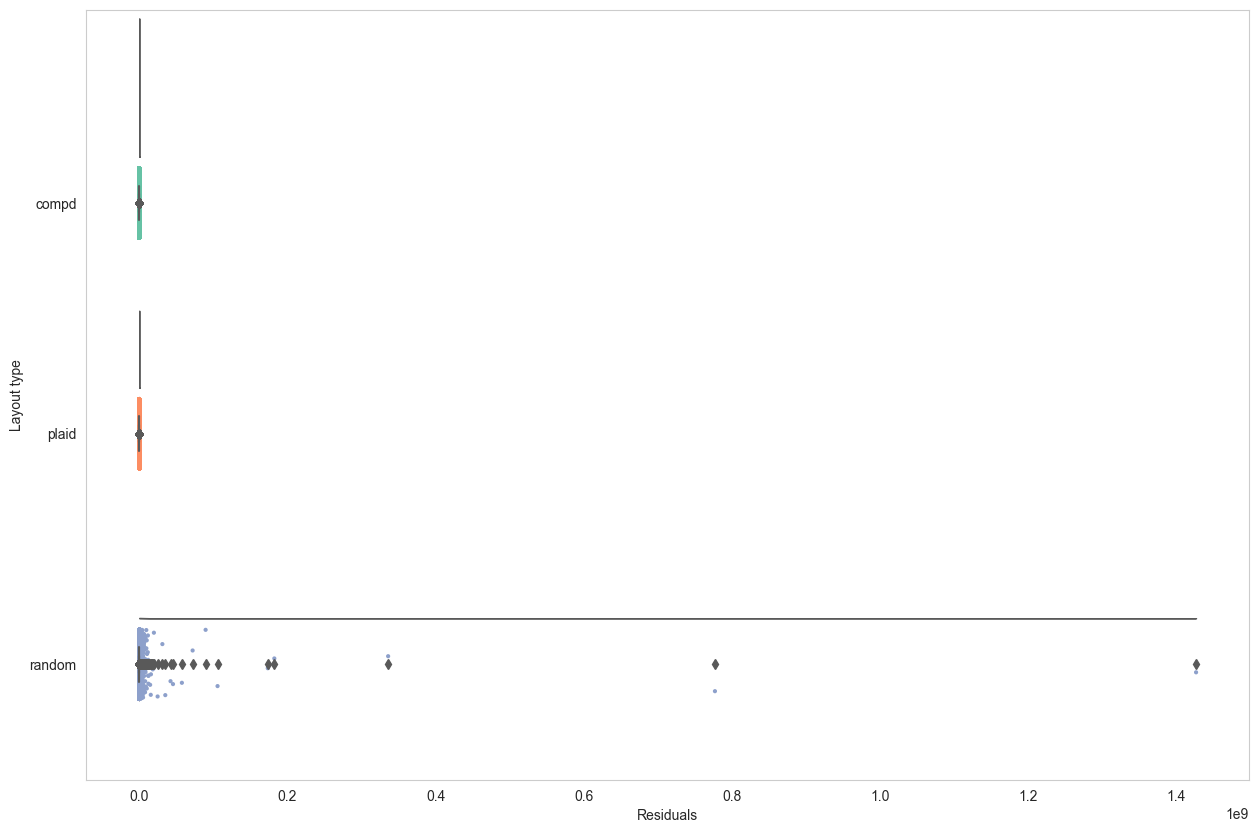

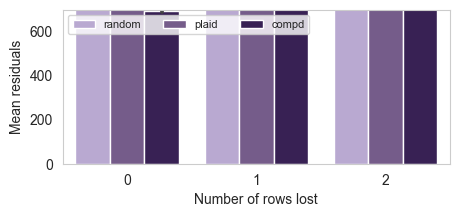

percent_non_active: 0.95
screening-residuals-10-10-0.2-pna-0.95-20250623-ROC-supplement.csv


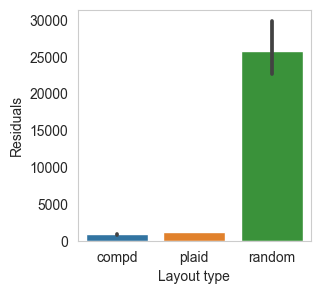

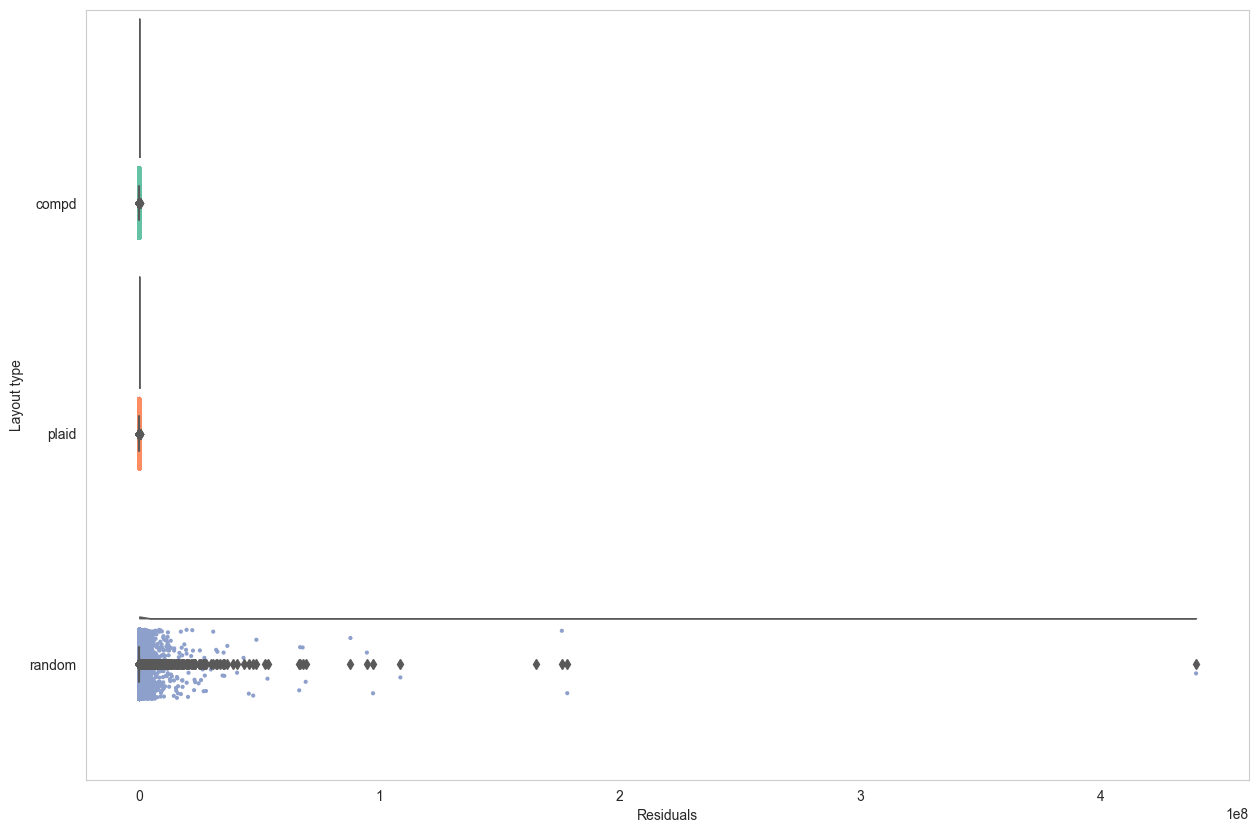

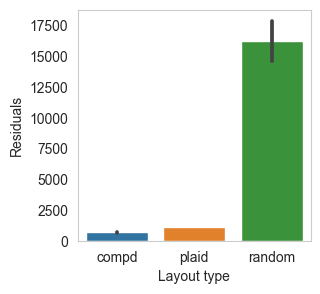

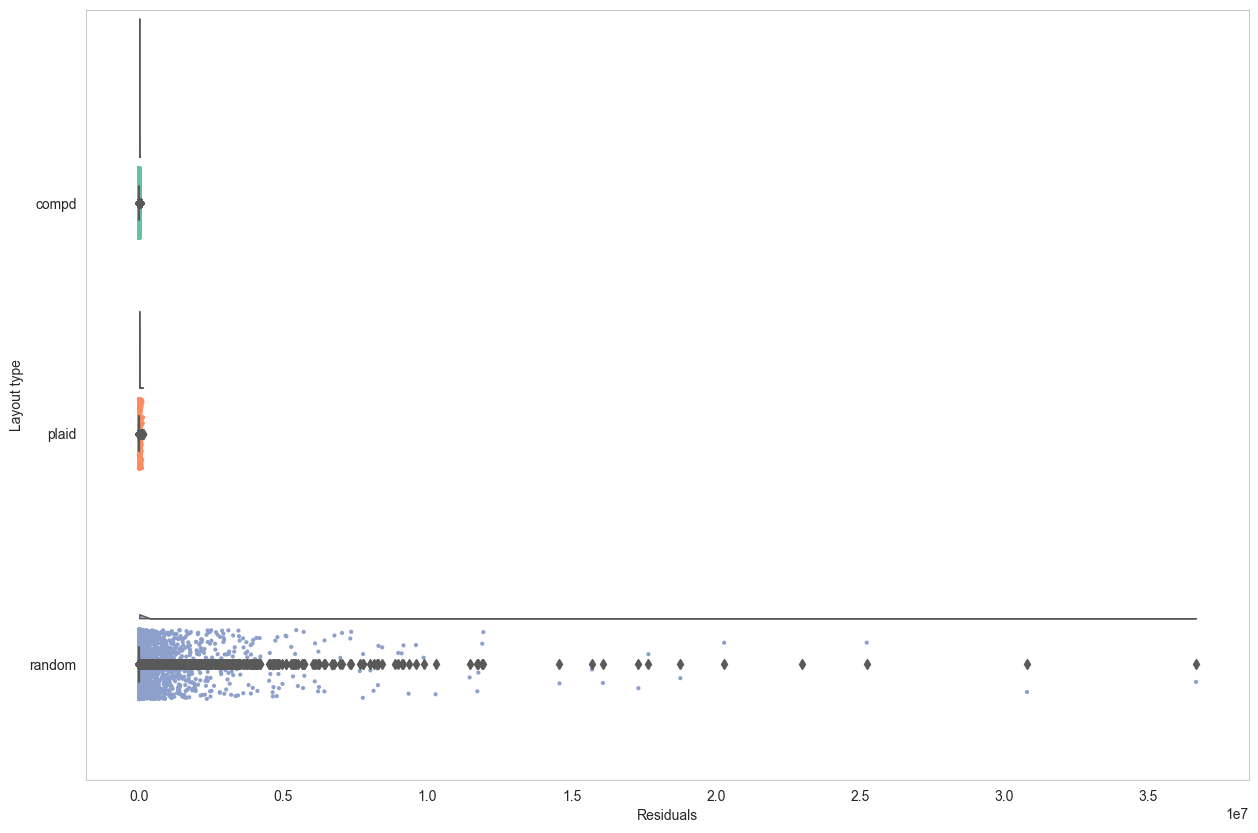

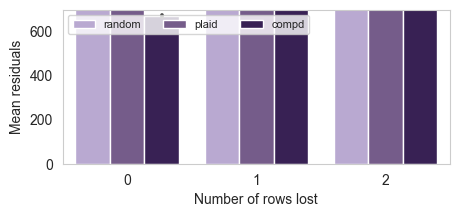

percent_non_active: 0.9
screening-residuals-10-10-0.2-pna-0.9-20250623-ROC-supplement.csv


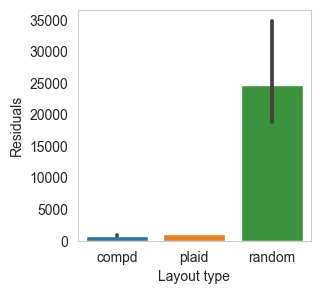

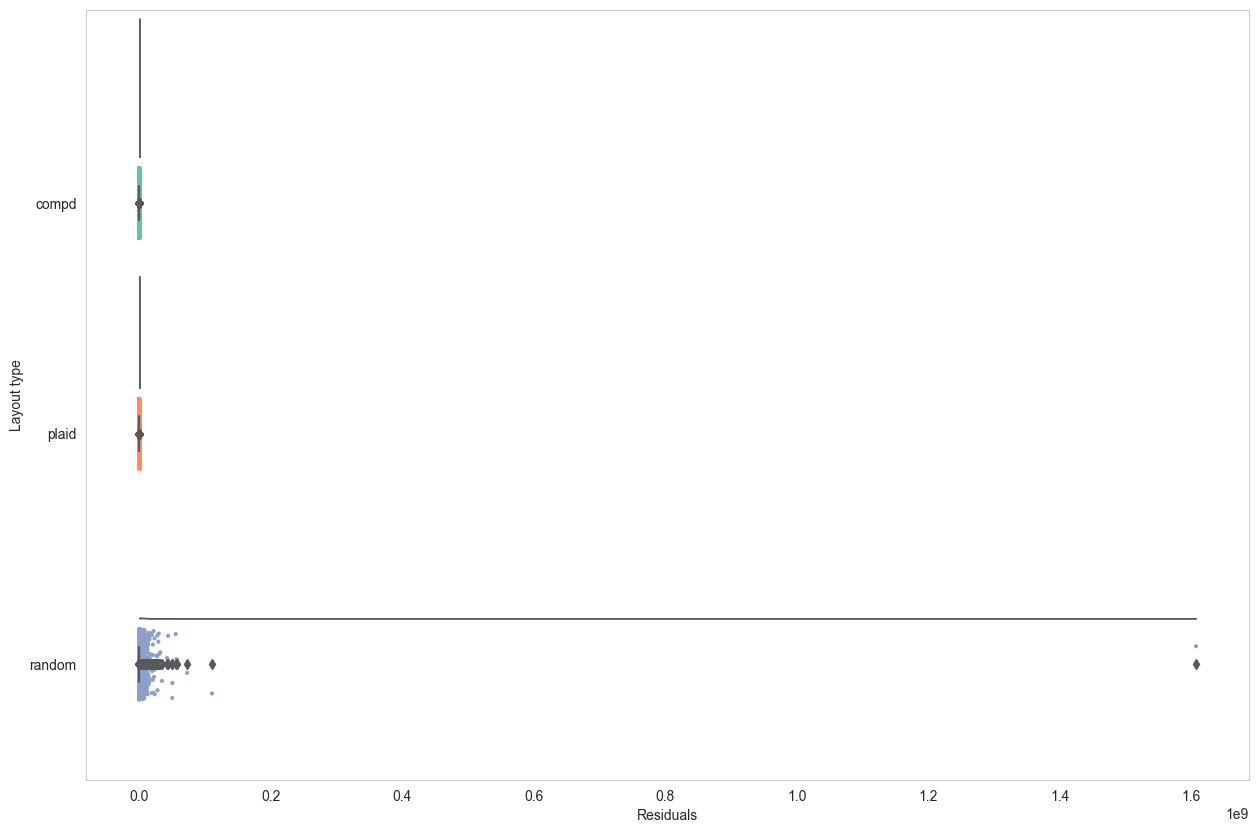

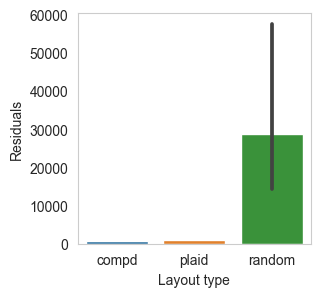

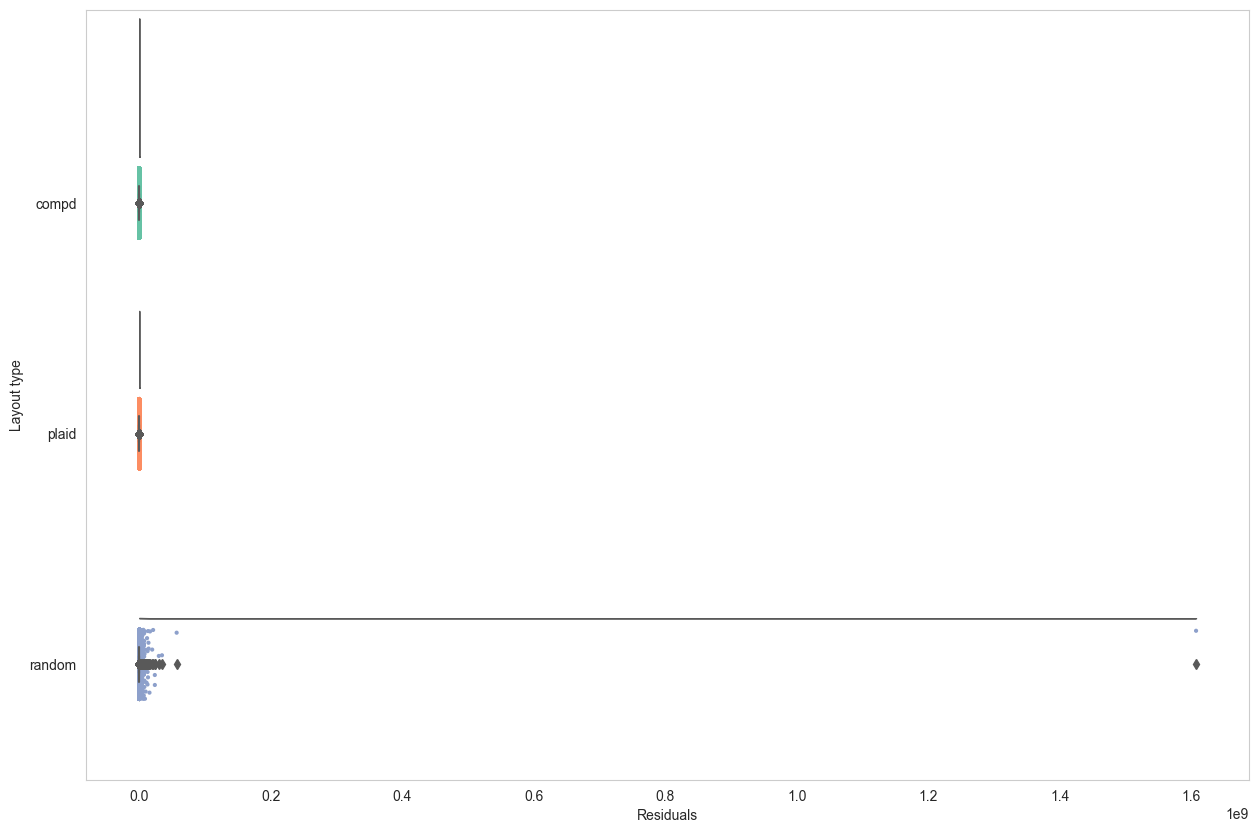

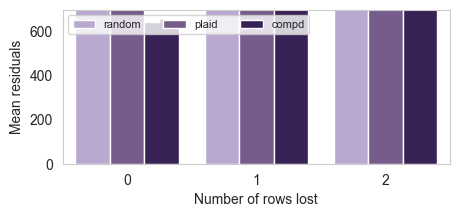

percent_non_active: 0.8
screening-residuals-10-10-0.2-pna-0.8-20250623-ROC-supplement.csv


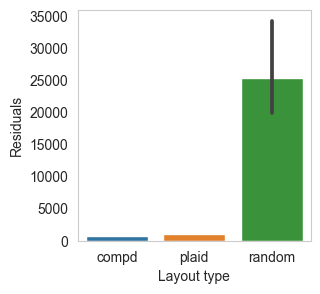

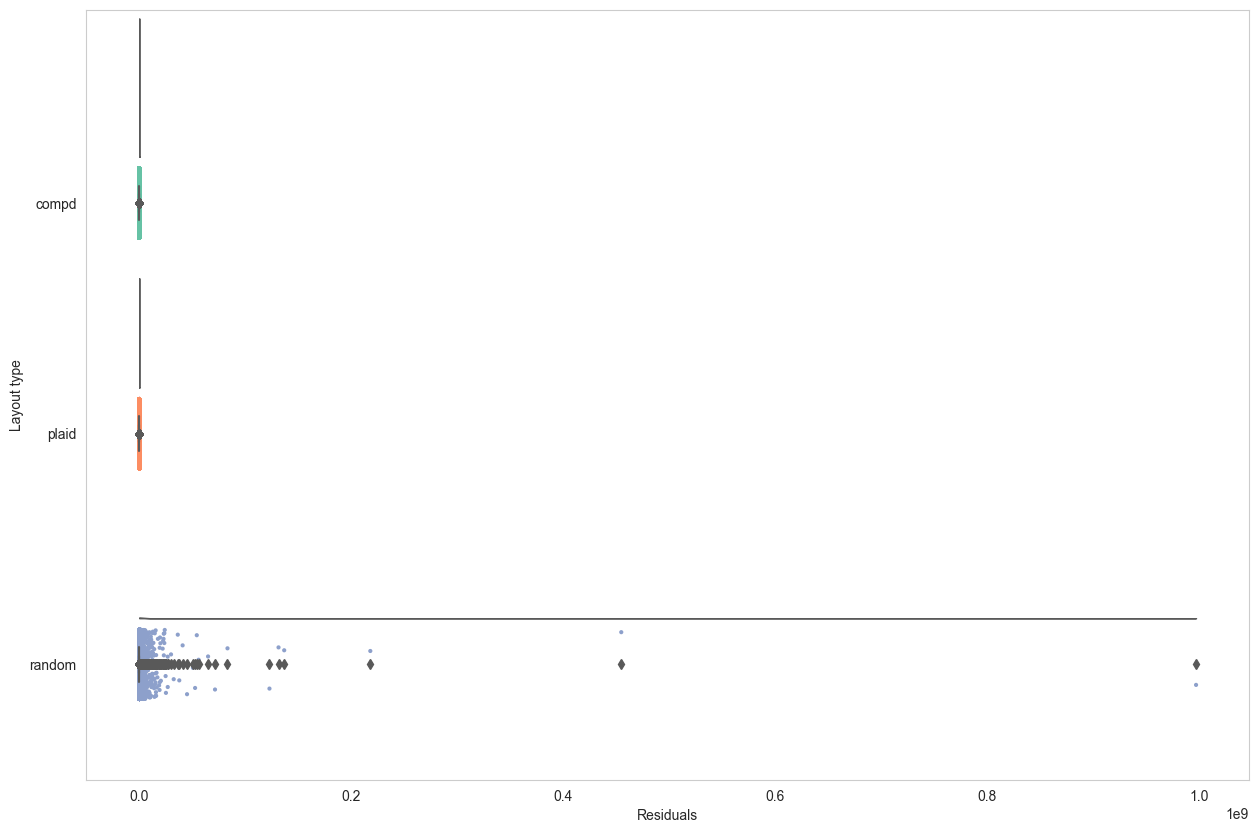

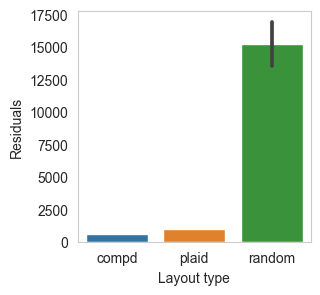

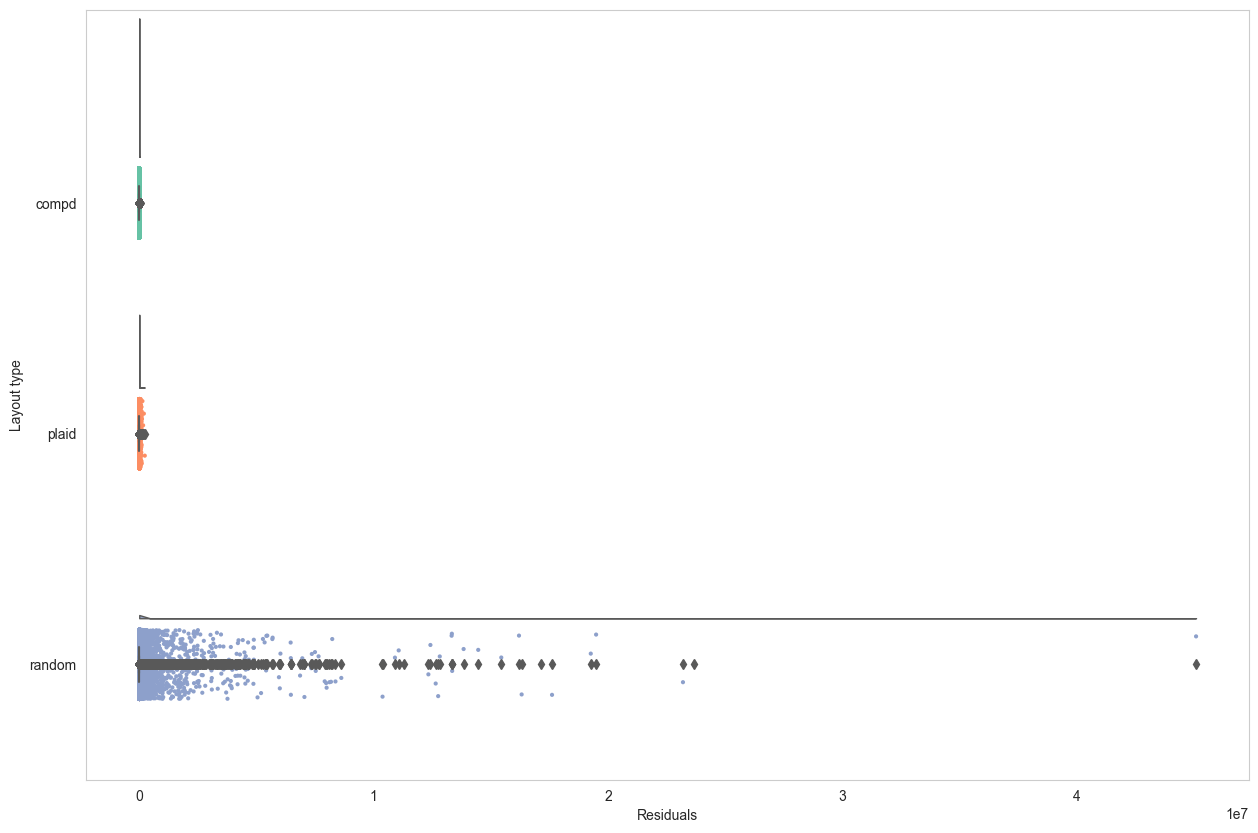

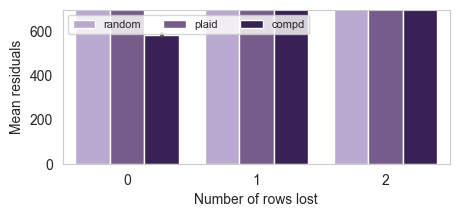

percent_non_active: 0.7
screening-residuals-10-10-0.2-pna-0.7-20250623-ROC-supplement.csv


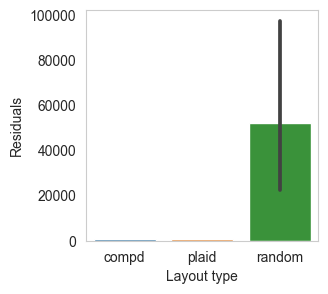

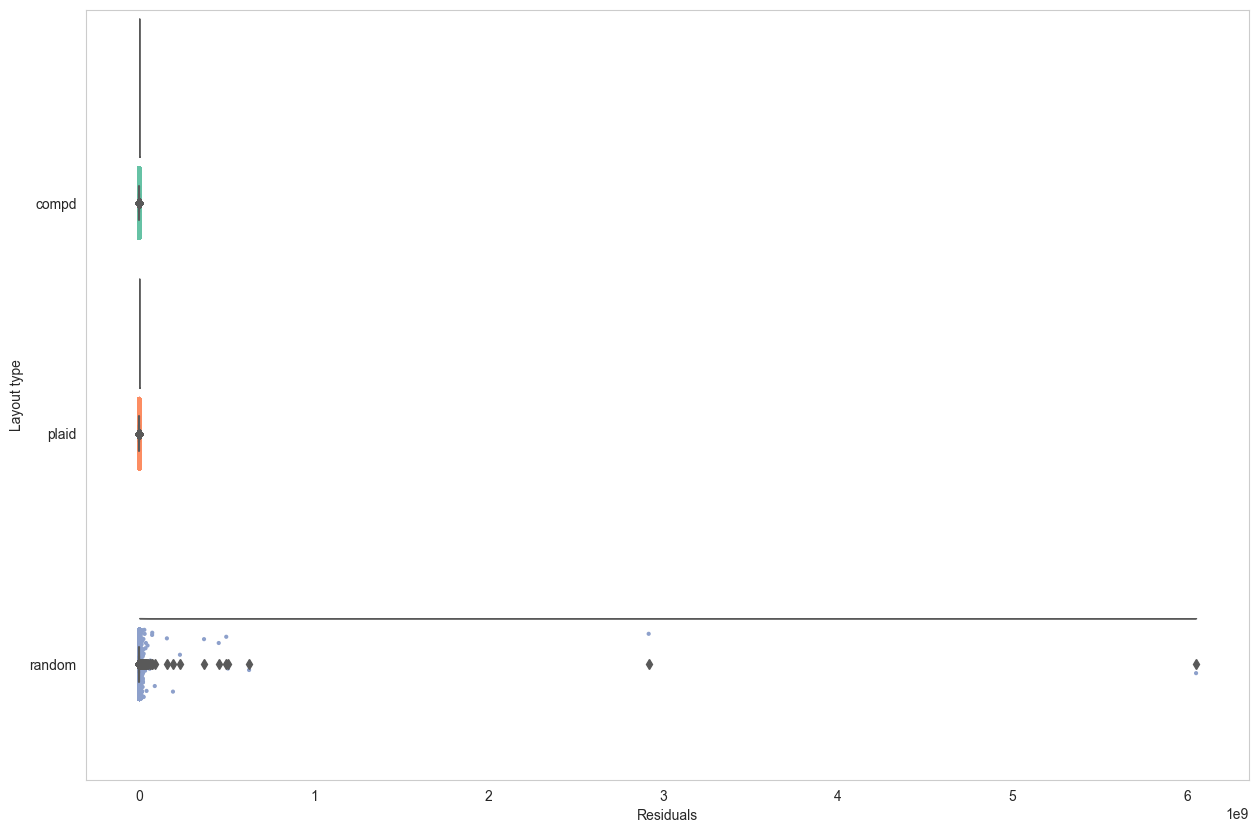

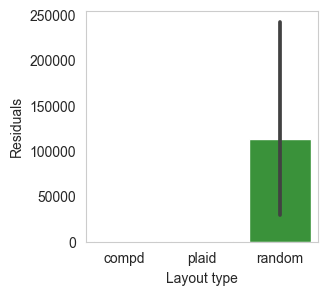

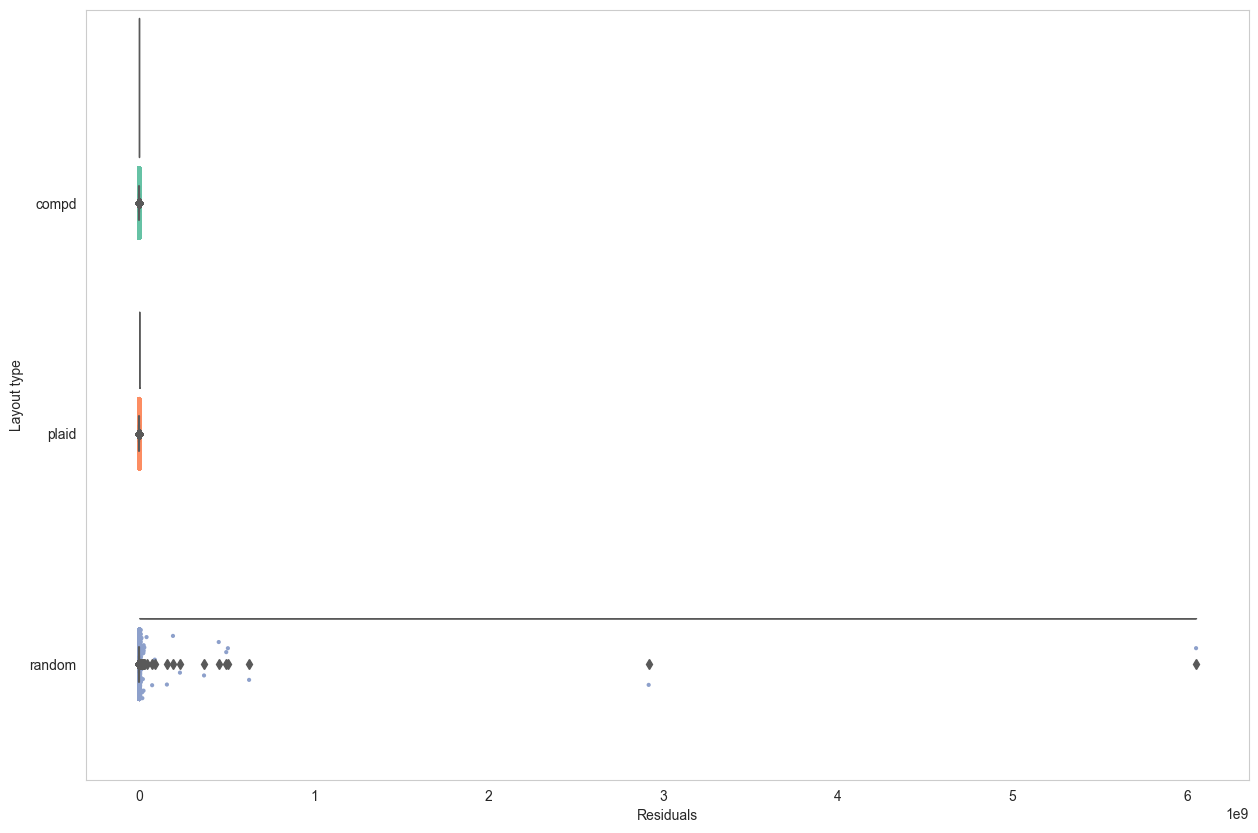

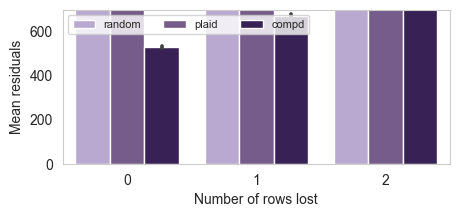

percent_non_active: 0.6
screening-residuals-10-10-0.2-pna-0.6-20250623-ROC-supplement.csv


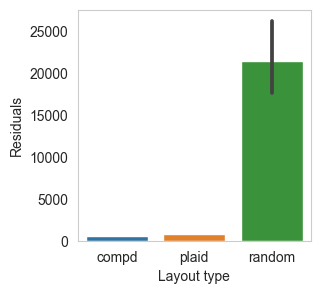

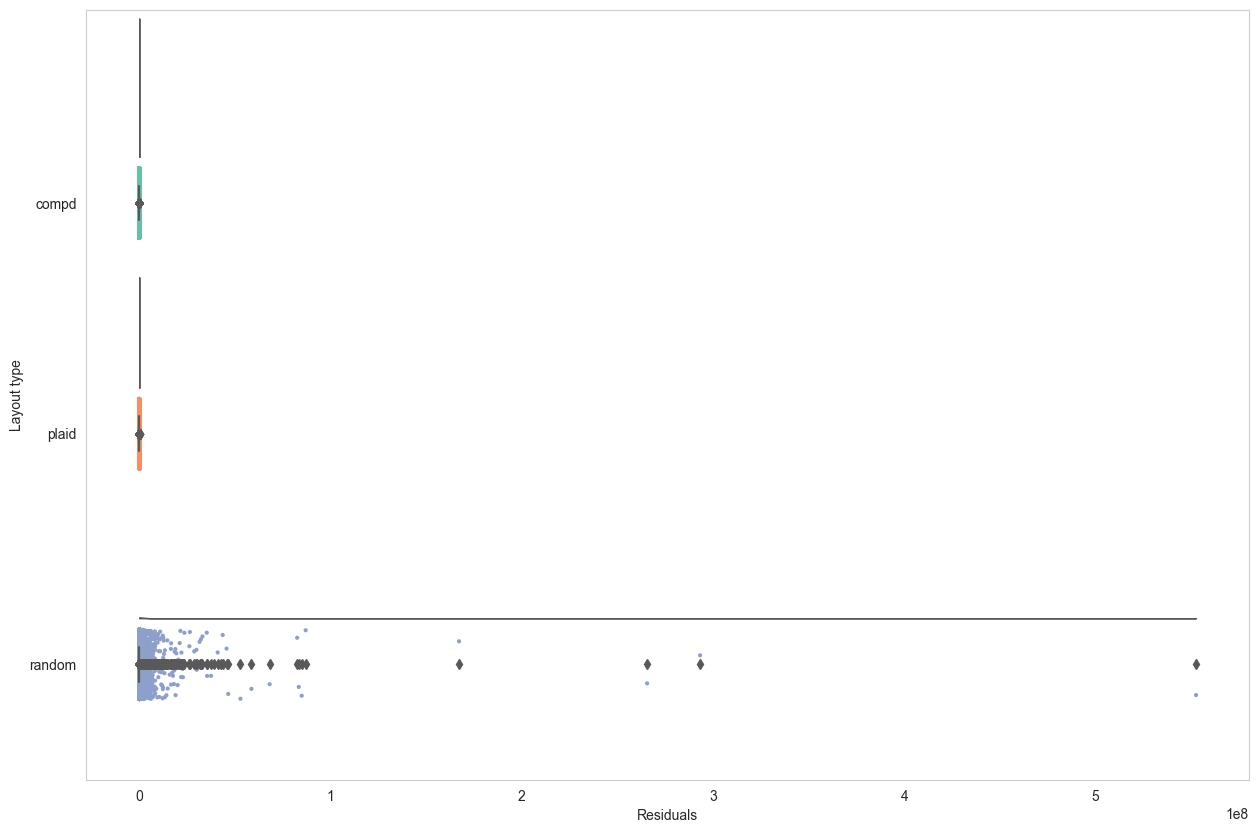

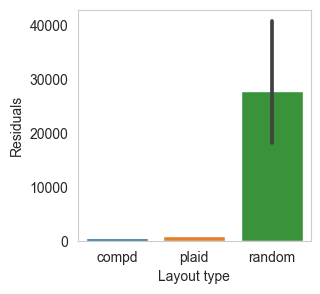

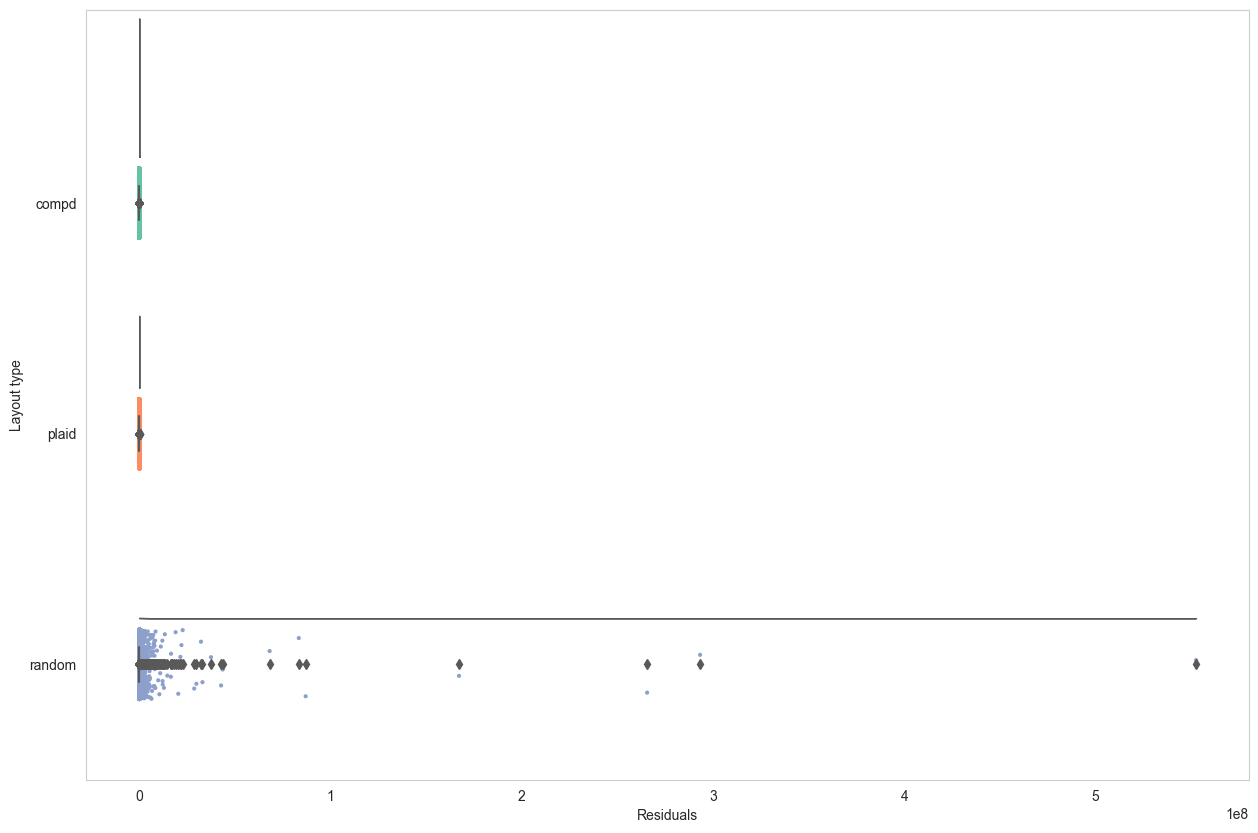

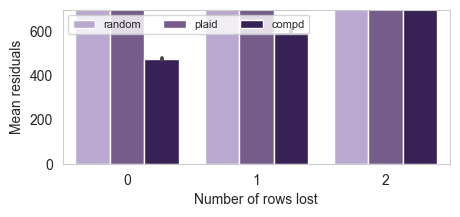

(neg_controls, pos_controls): 20 10
error: 0.06
percent_non_active: 0.99
screening-residuals-10-20-0.06-pna-0.99-20250623-ROC-supplement.csv


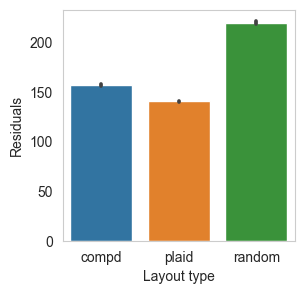

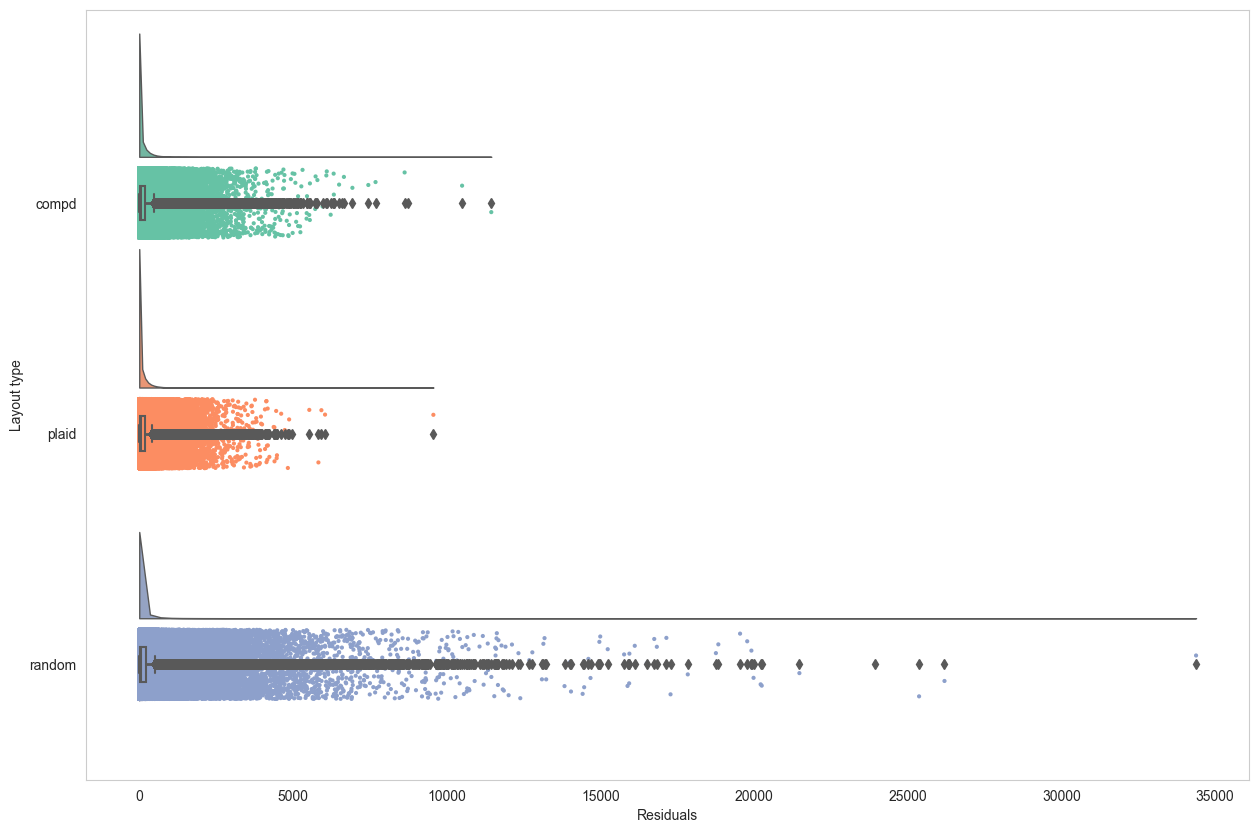

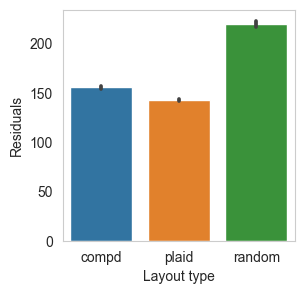

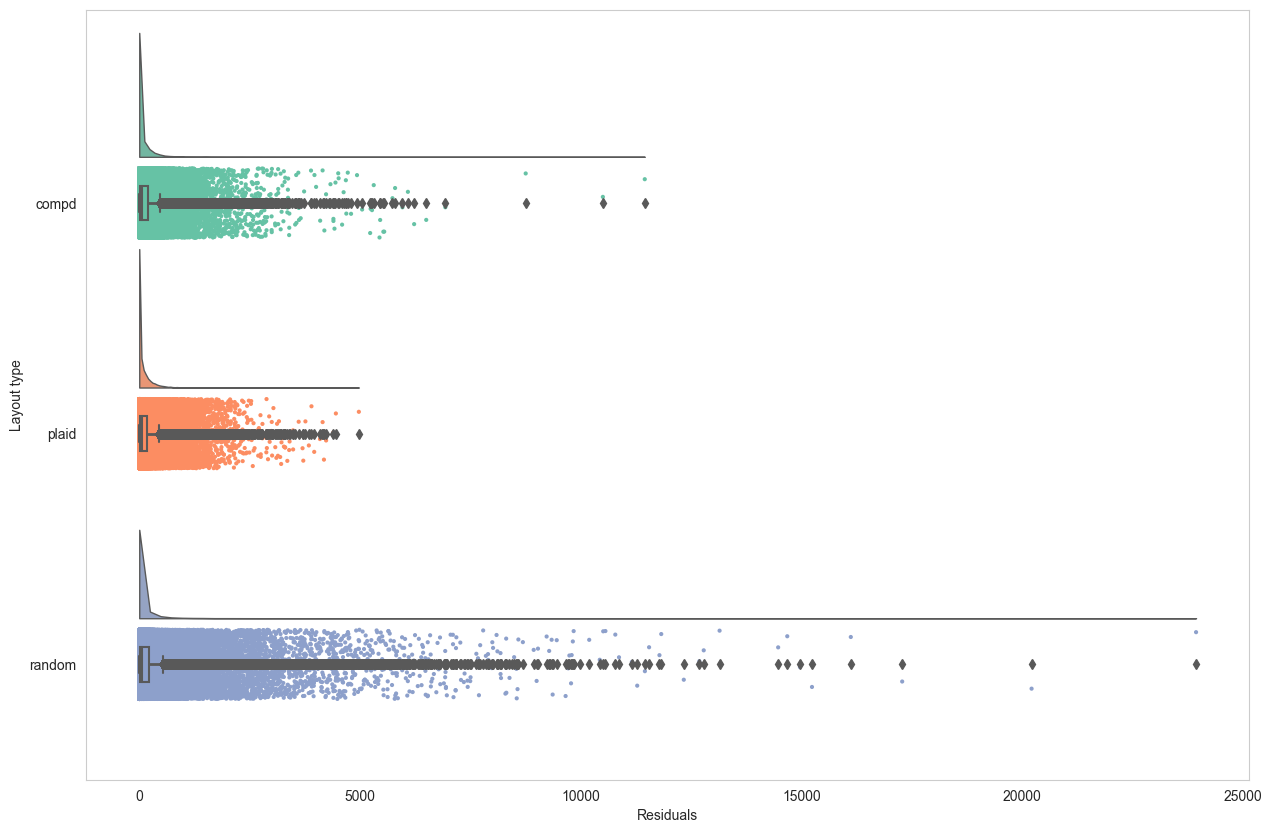

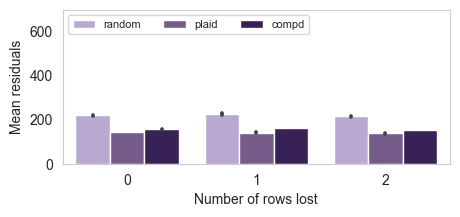

percent_non_active: 0.95
screening-residuals-10-20-0.06-pna-0.95-20250623-ROC-supplement.csv


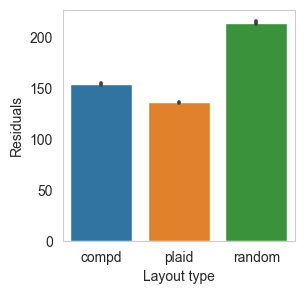

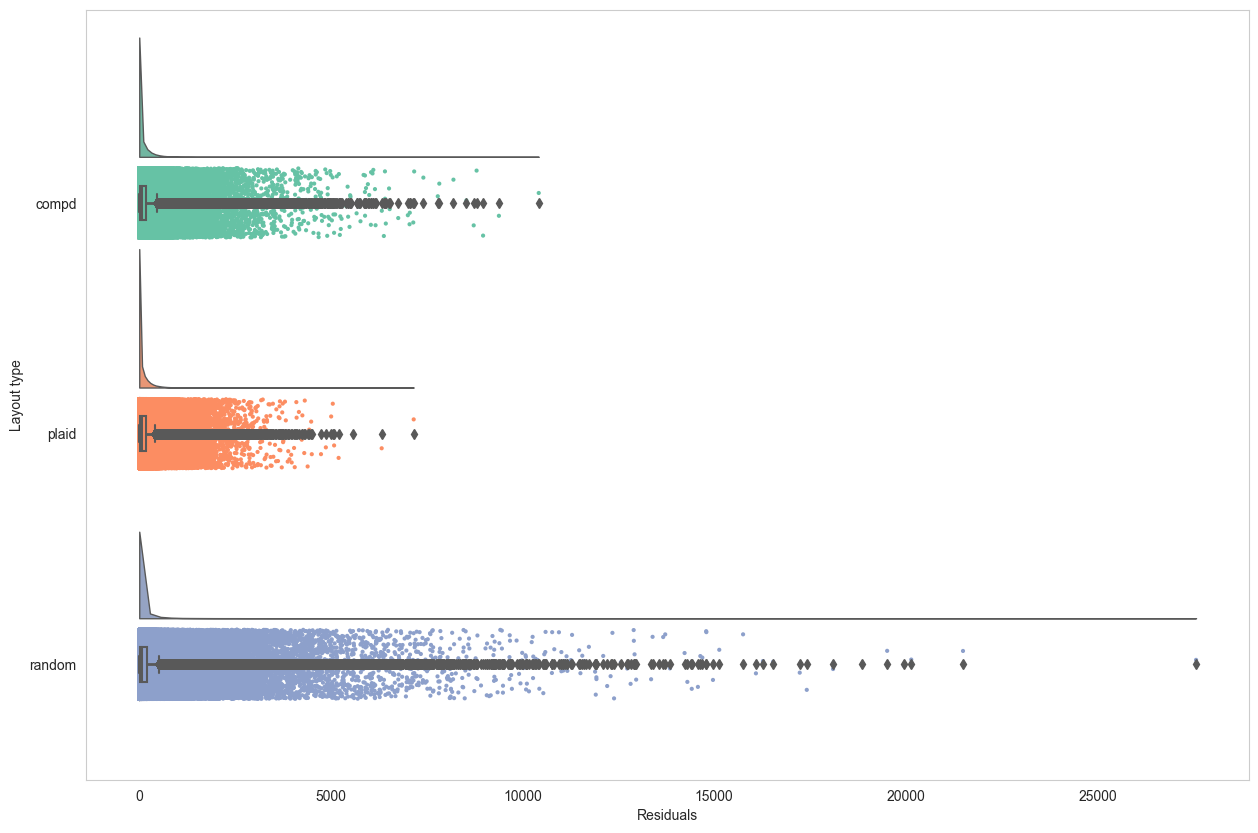

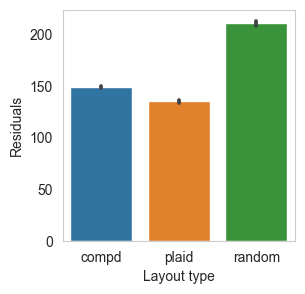

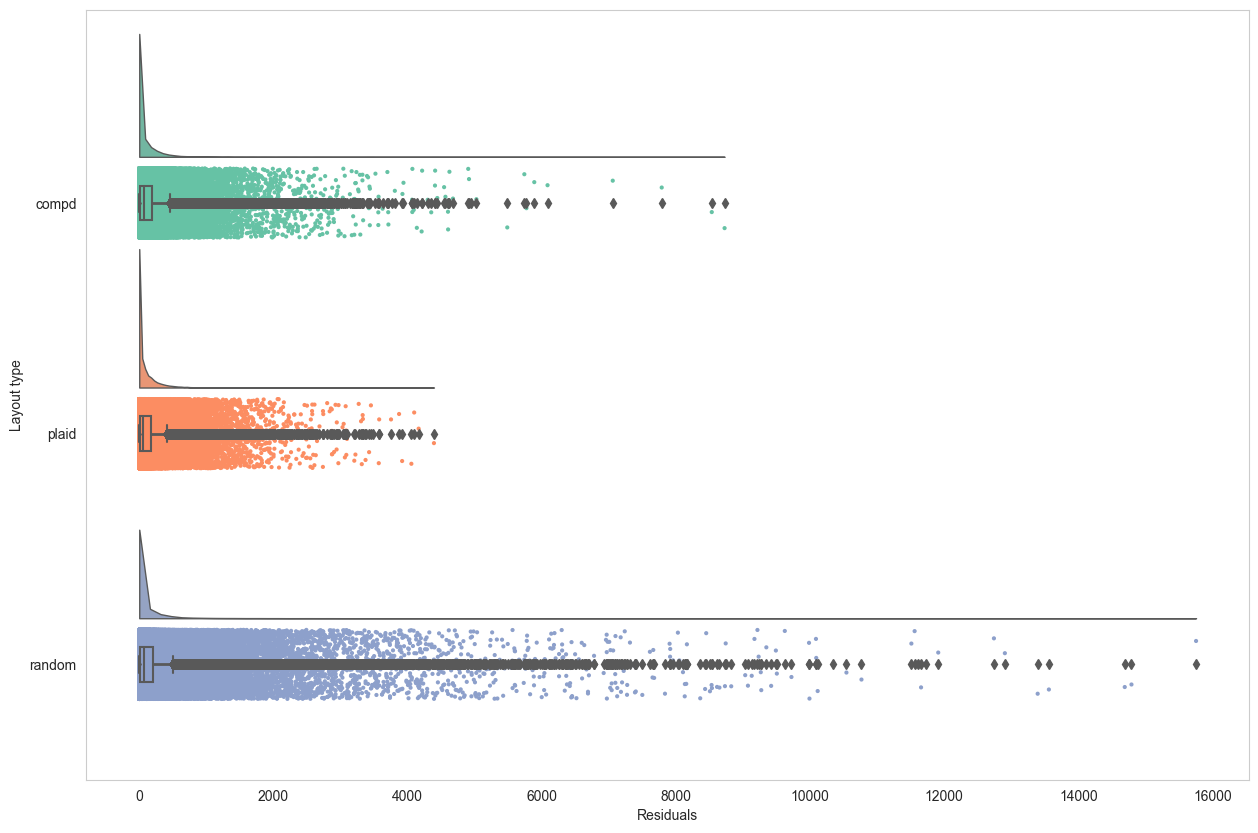

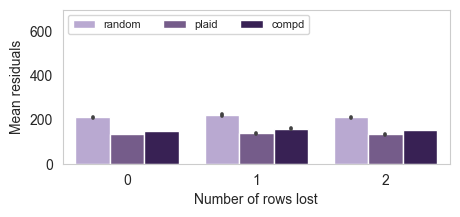

percent_non_active: 0.9
screening-residuals-10-20-0.06-pna-0.9-20250623-ROC-supplement.csv


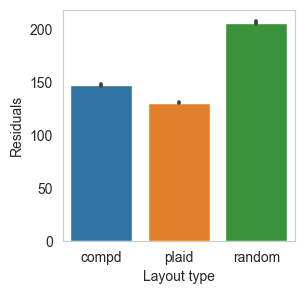

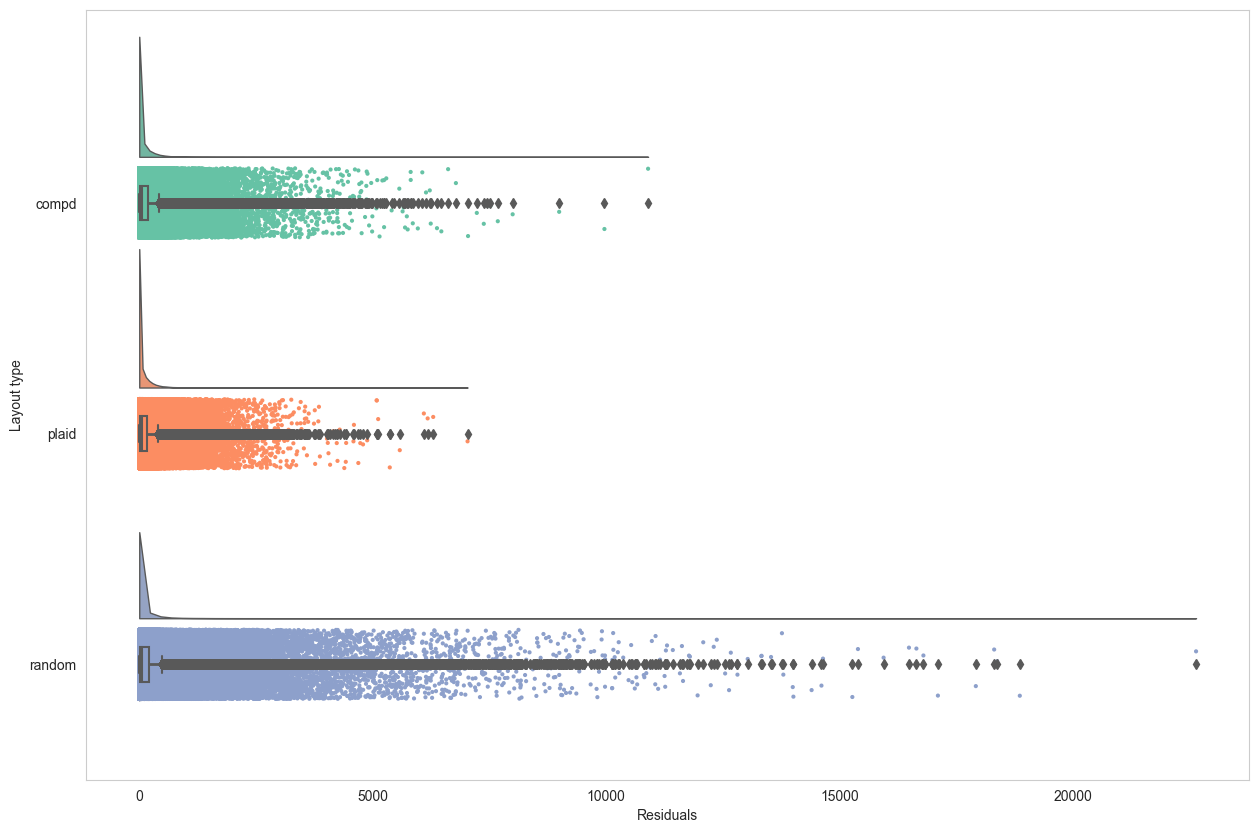

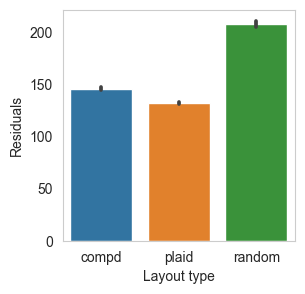

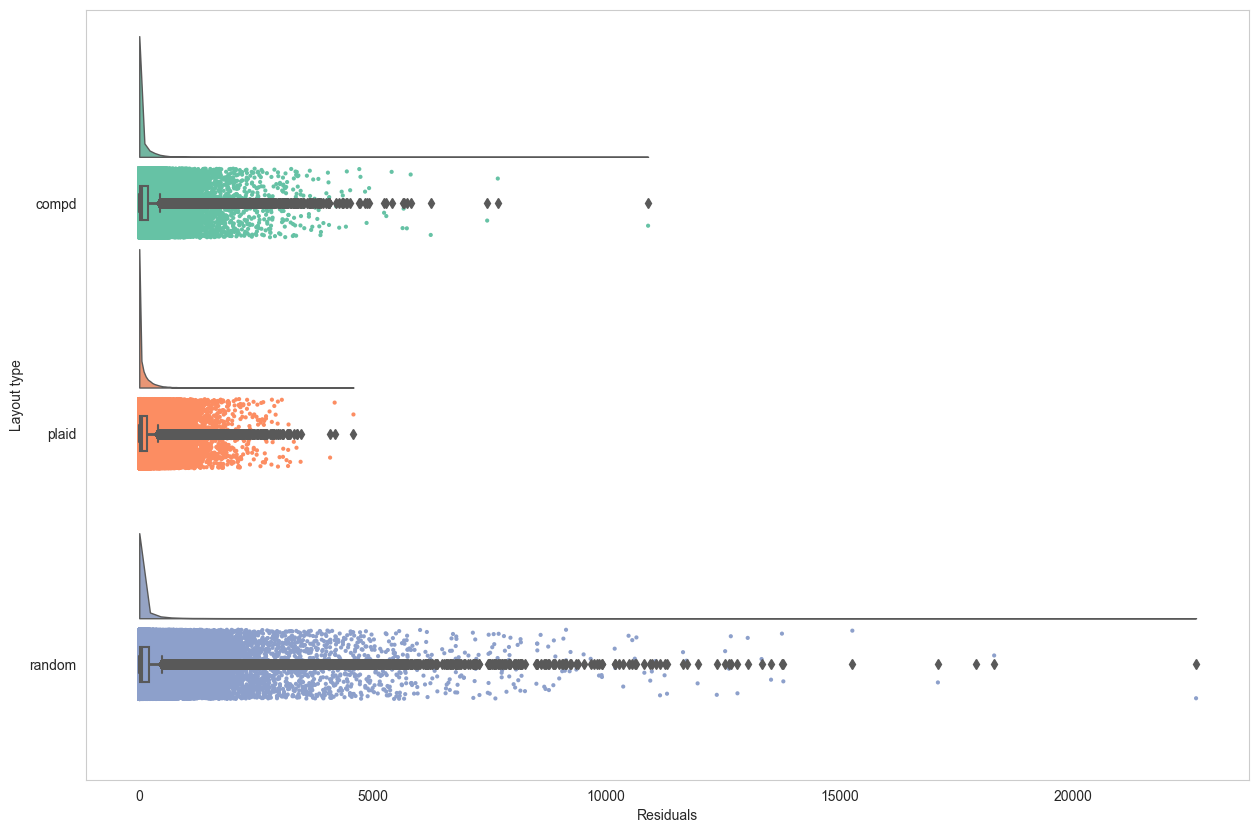

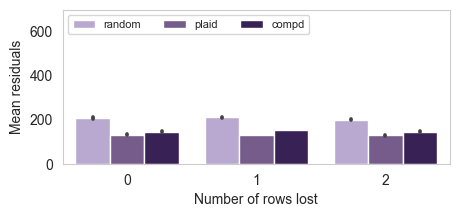

percent_non_active: 0.8
screening-residuals-10-20-0.06-pna-0.8-20250623-ROC-supplement.csv


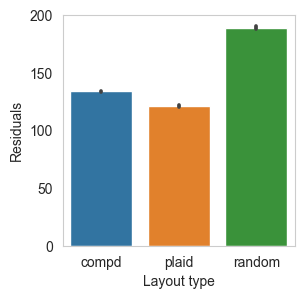

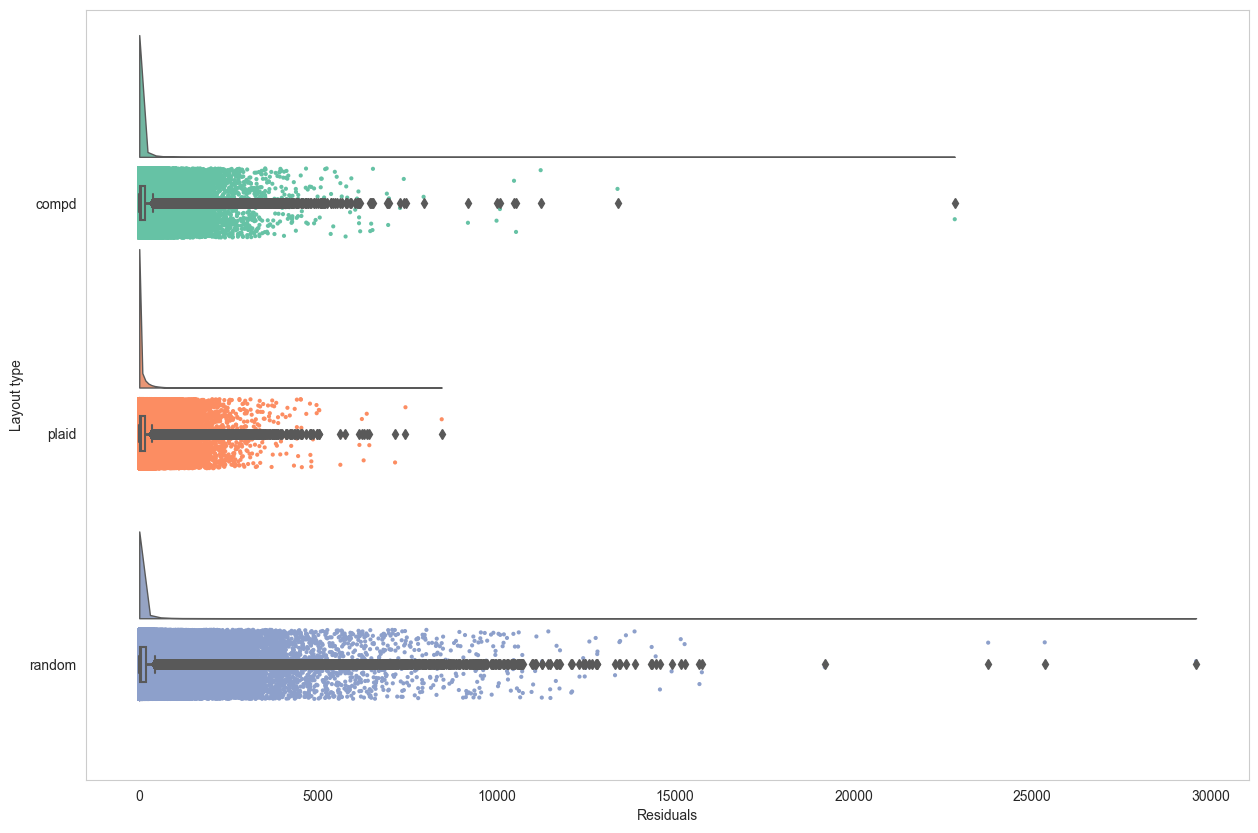

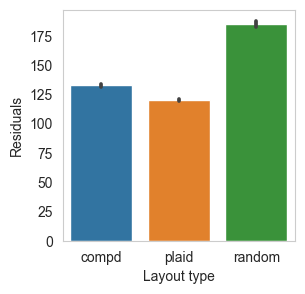

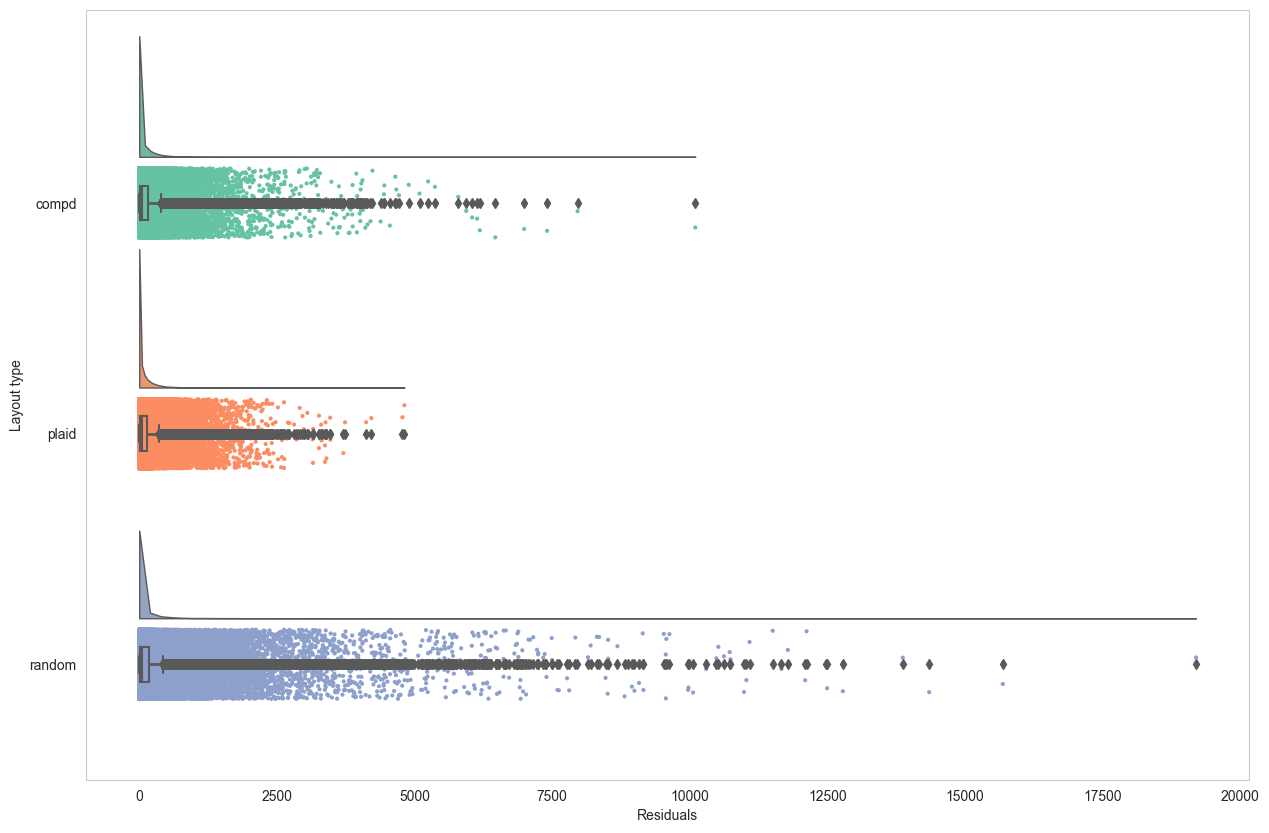

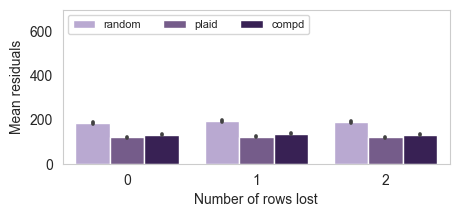

percent_non_active: 0.7
screening-residuals-10-20-0.06-pna-0.7-20250623-ROC-supplement.csv


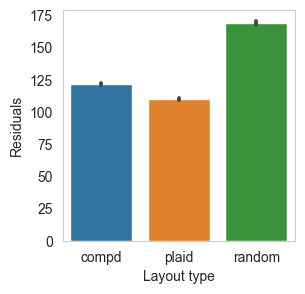

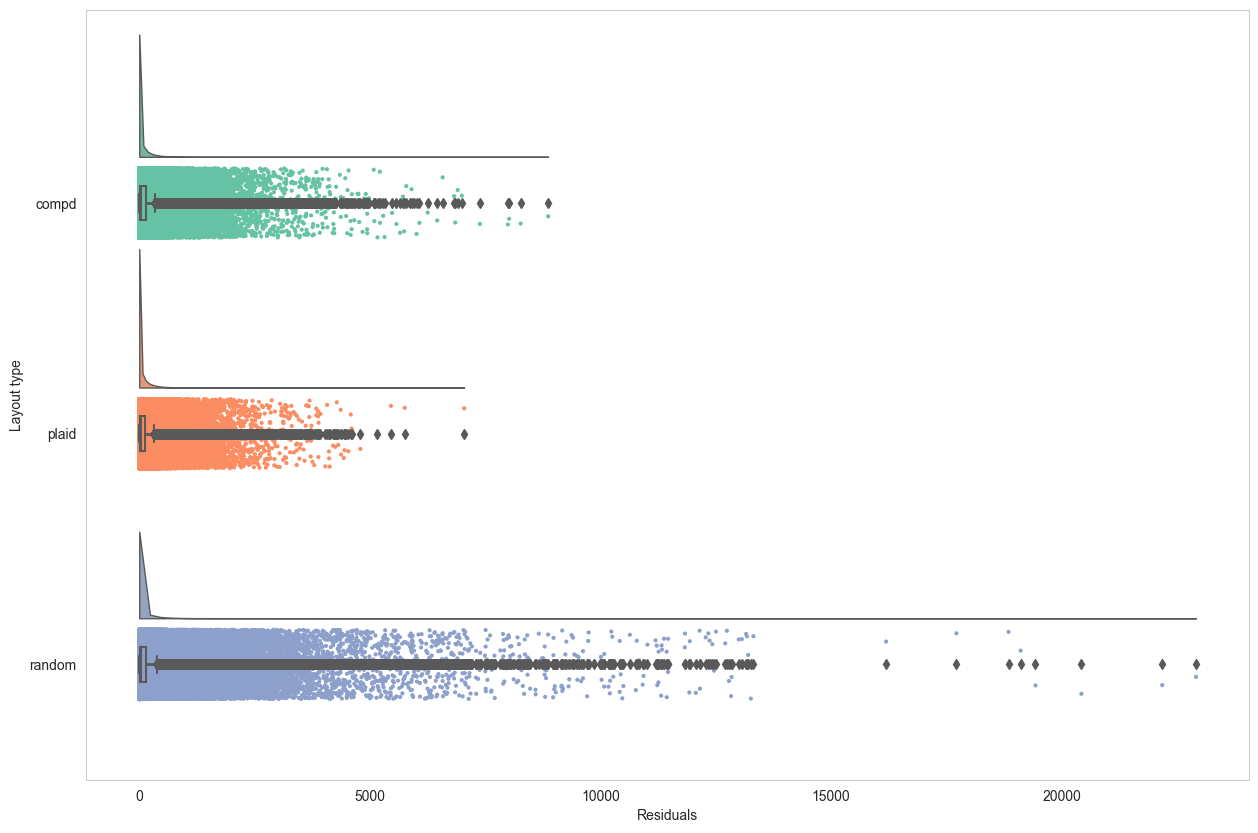

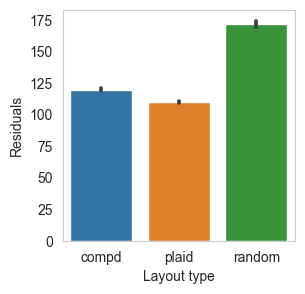

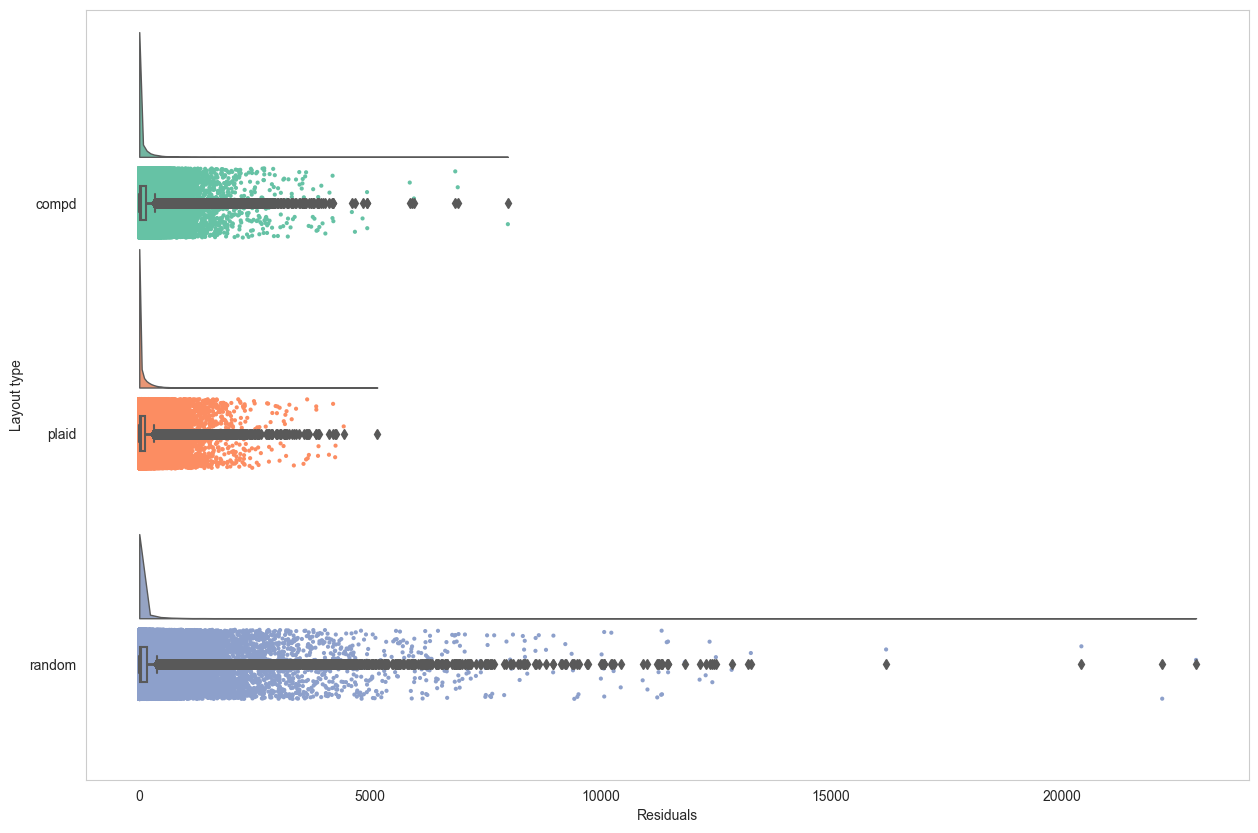

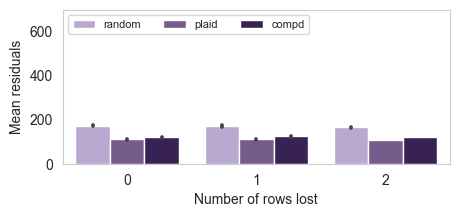

percent_non_active: 0.6
screening-residuals-10-20-0.06-pna-0.6-20250623-ROC-supplement.csv


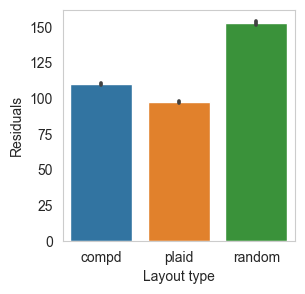

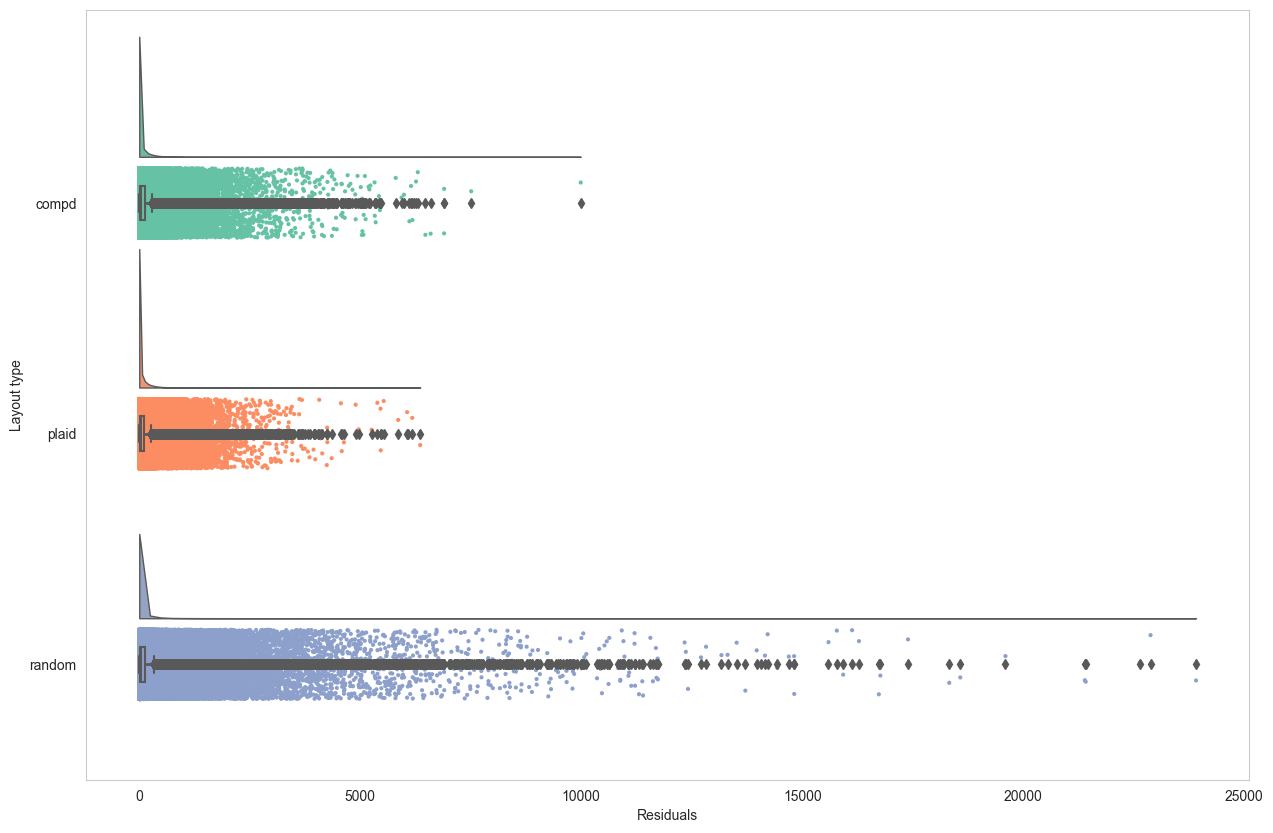

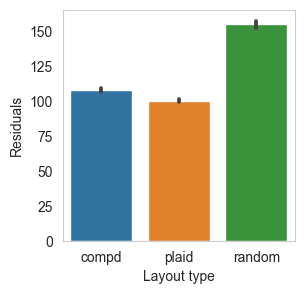

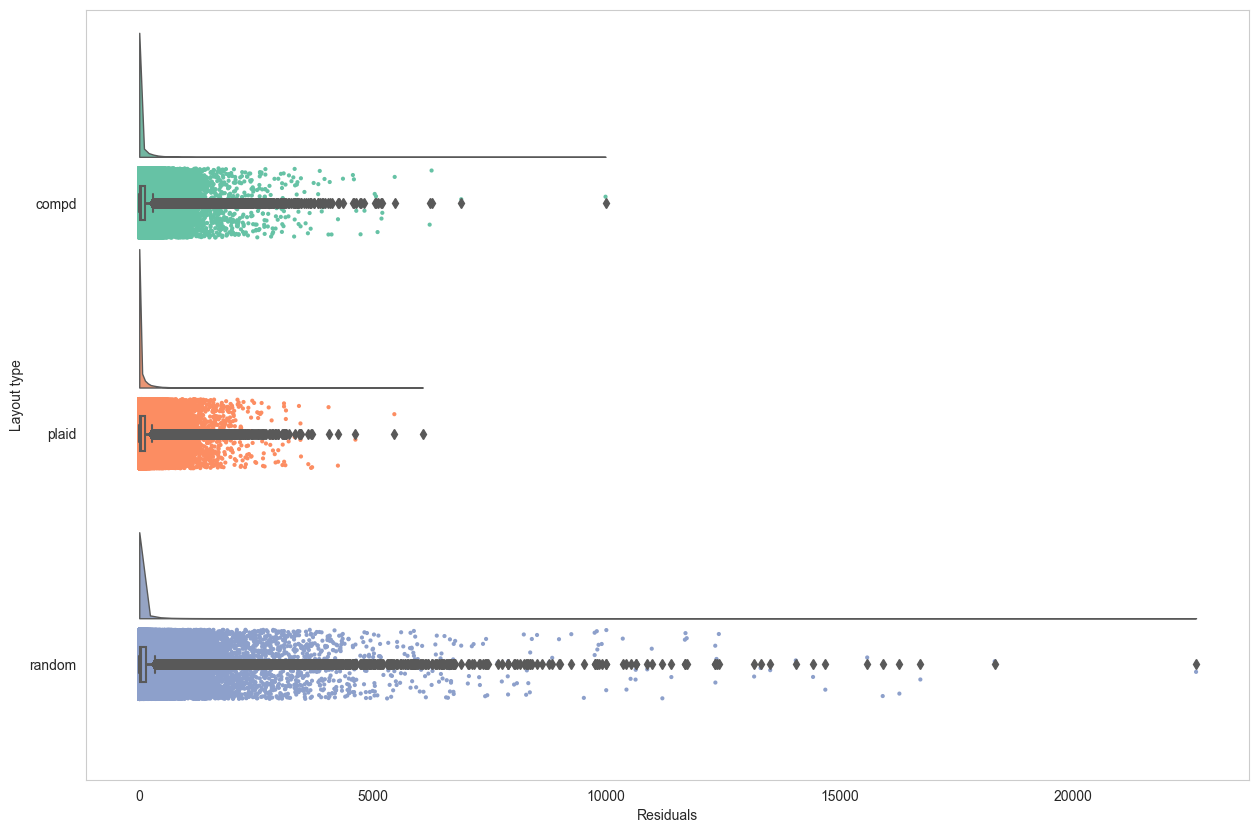

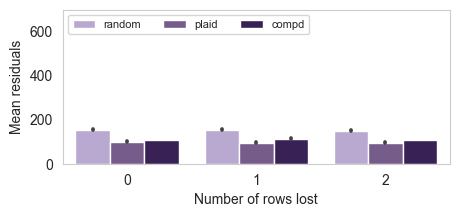

error: 0.1
percent_non_active: 0.99
screening-residuals-10-20-0.1-pna-0.99-20250623-ROC-supplement.csv


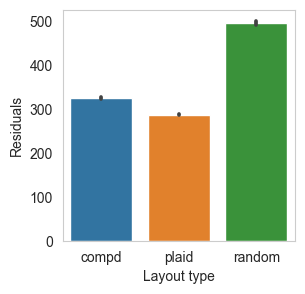

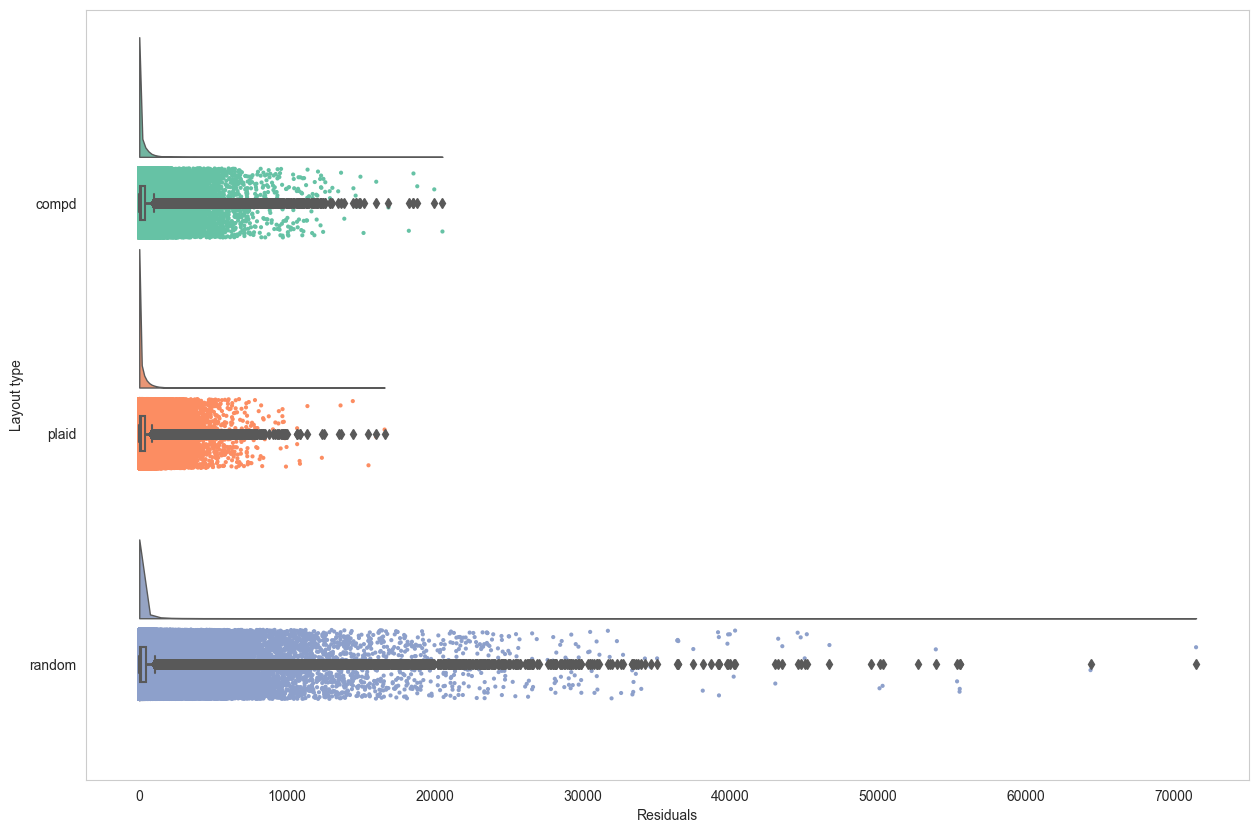

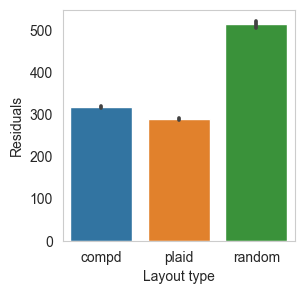

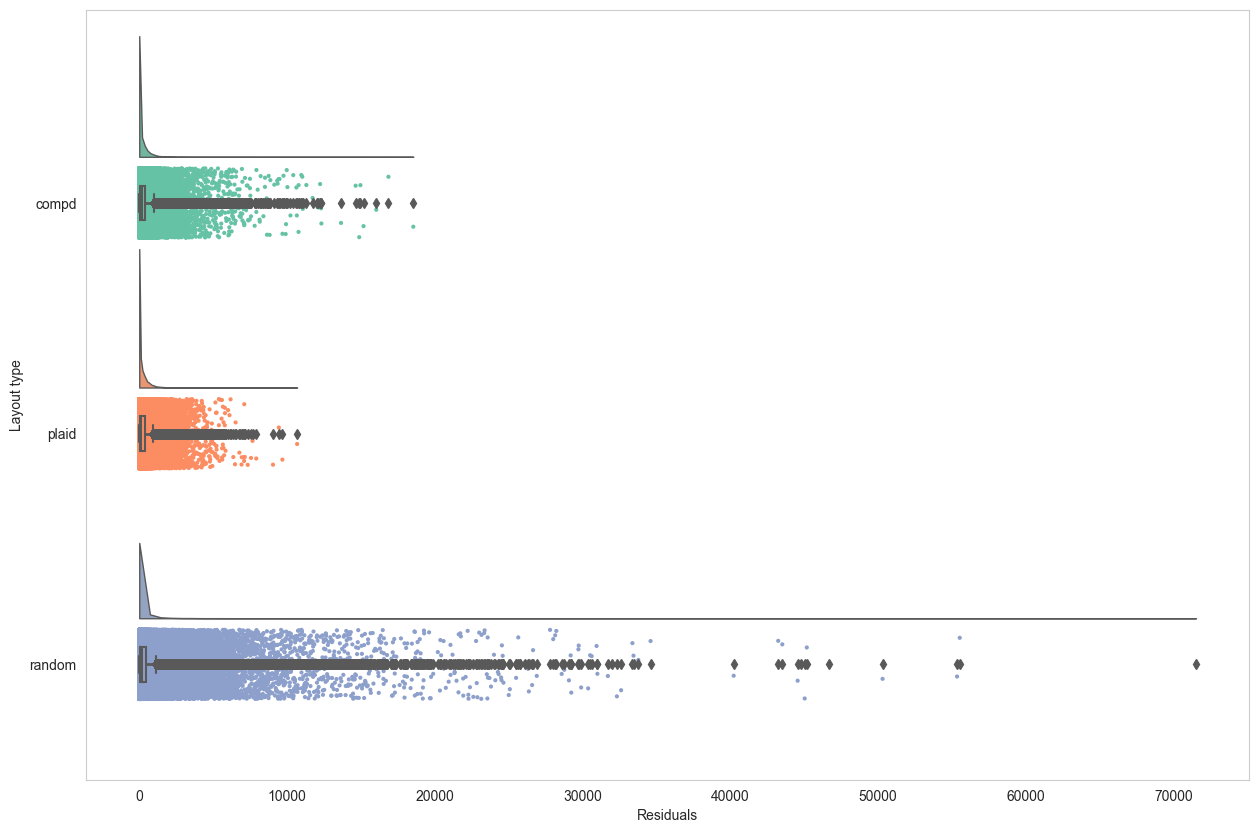

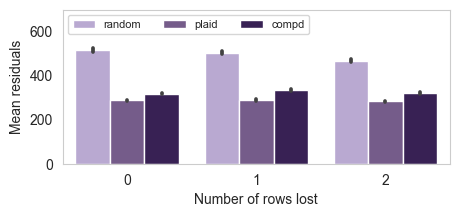

percent_non_active: 0.95
screening-residuals-10-20-0.1-pna-0.95-20250623-ROC-supplement.csv


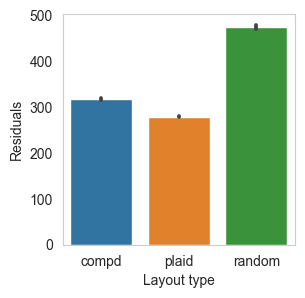

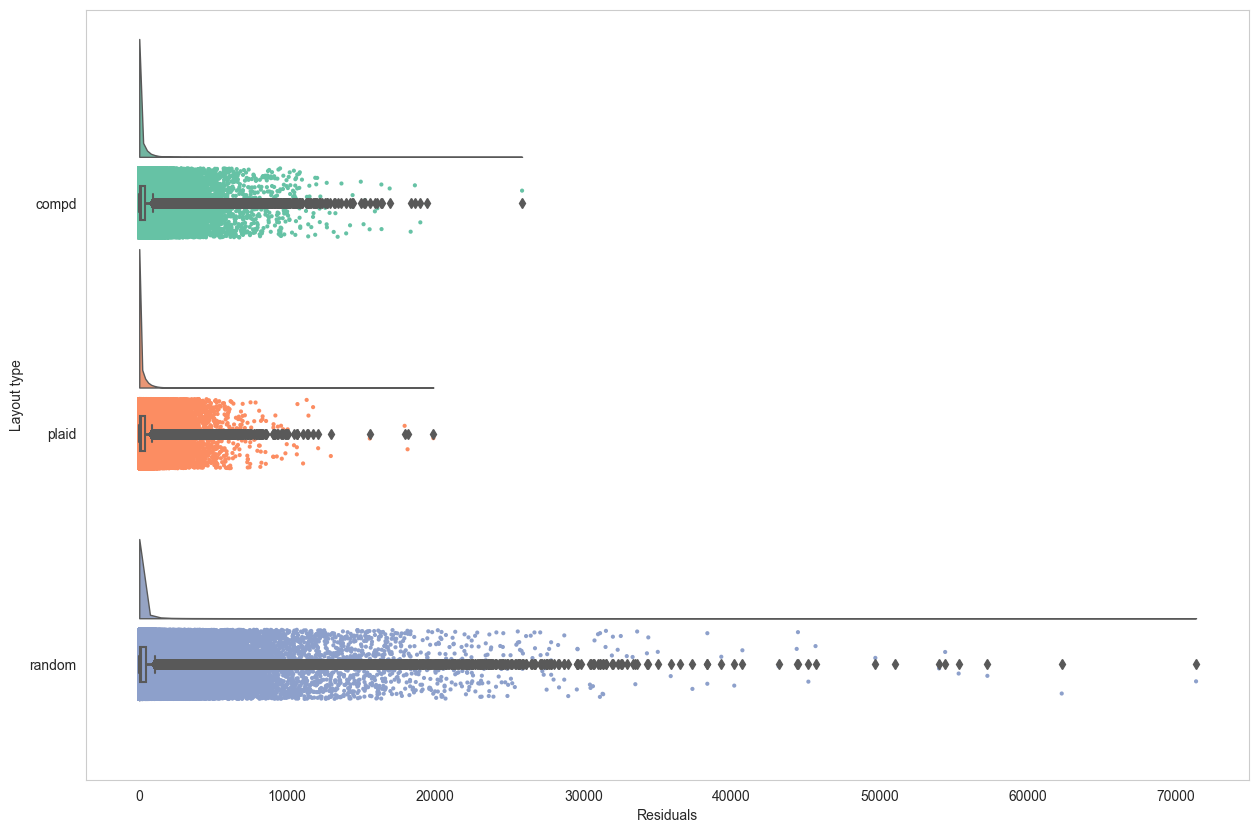

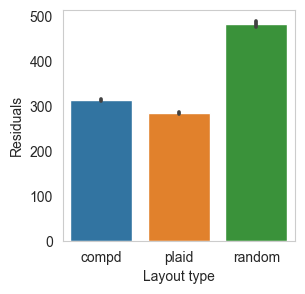

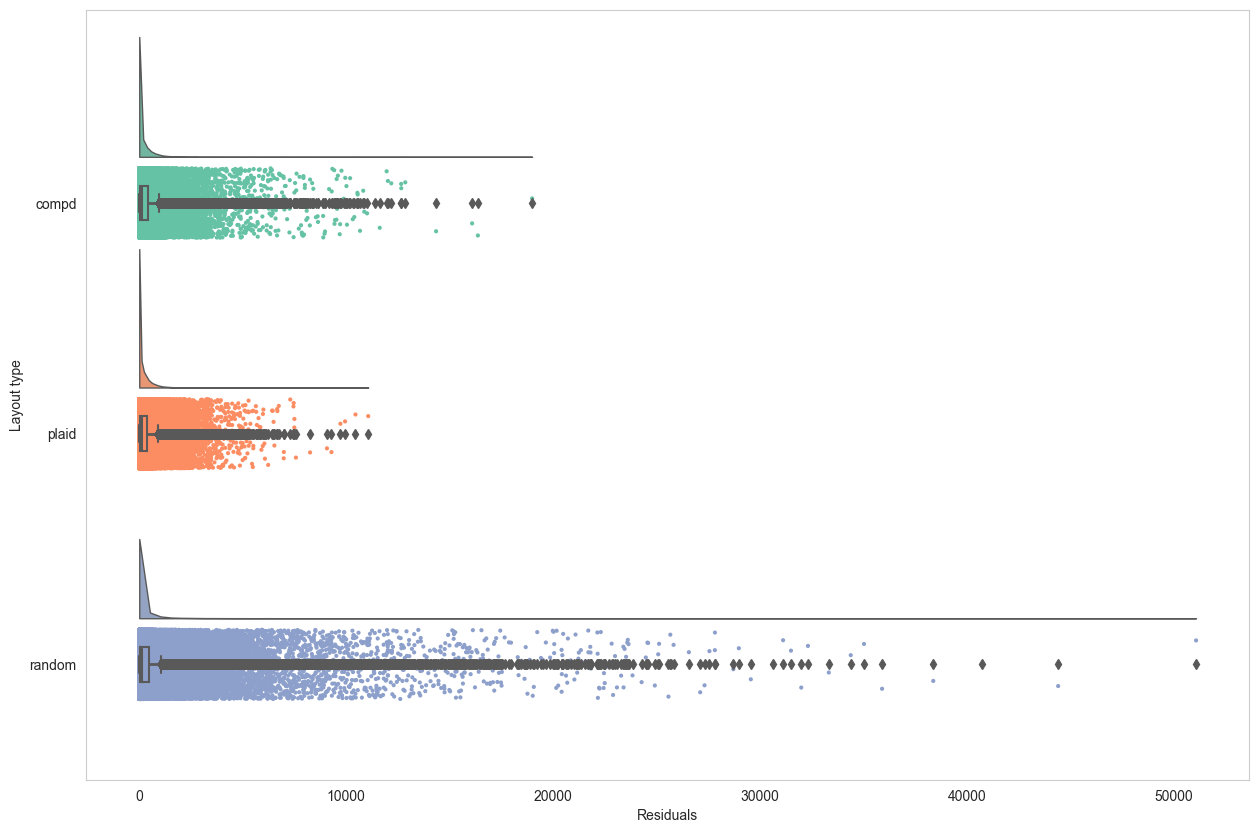

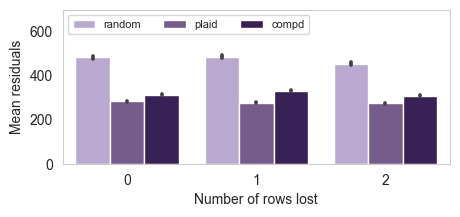

percent_non_active: 0.9
screening-residuals-10-20-0.1-pna-0.9-20250623-ROC-supplement.csv


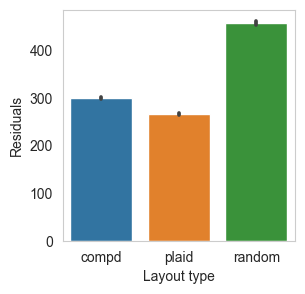

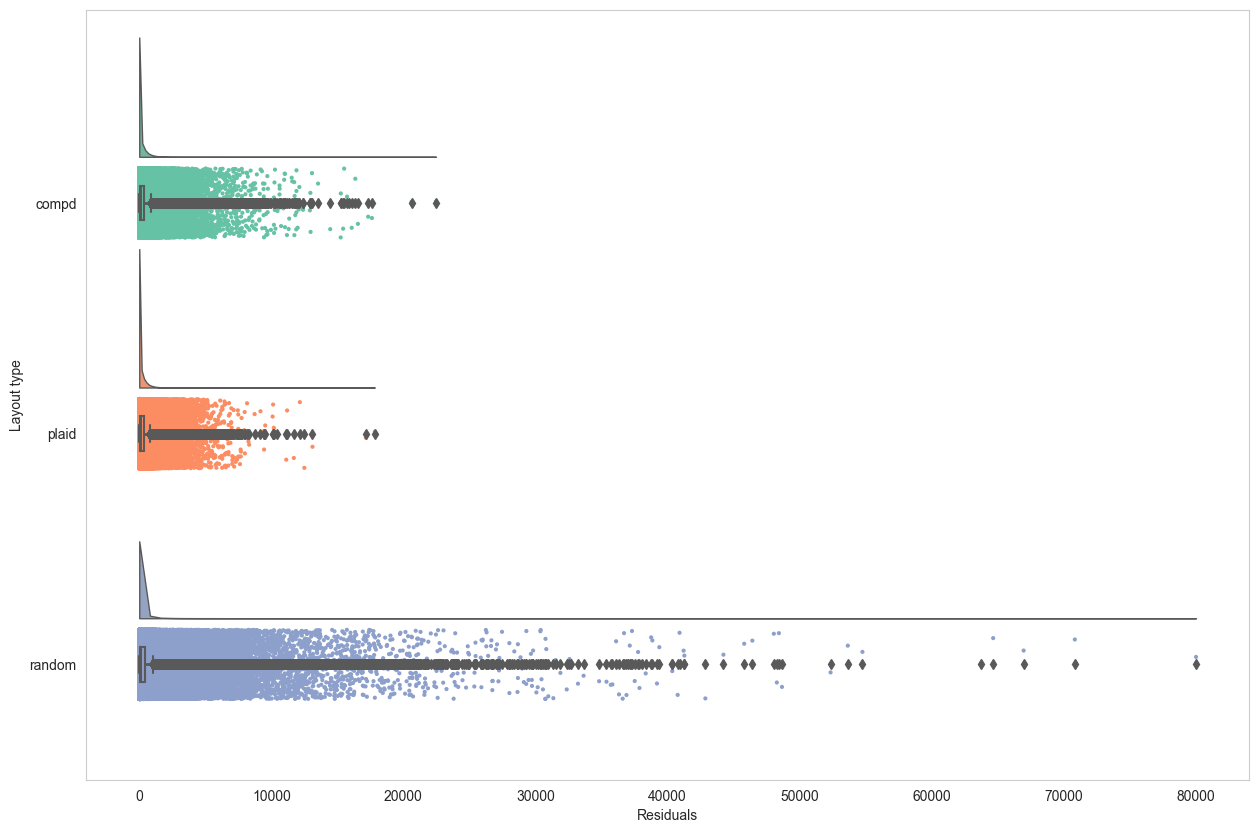

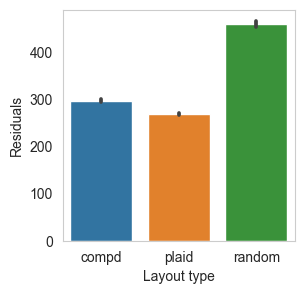

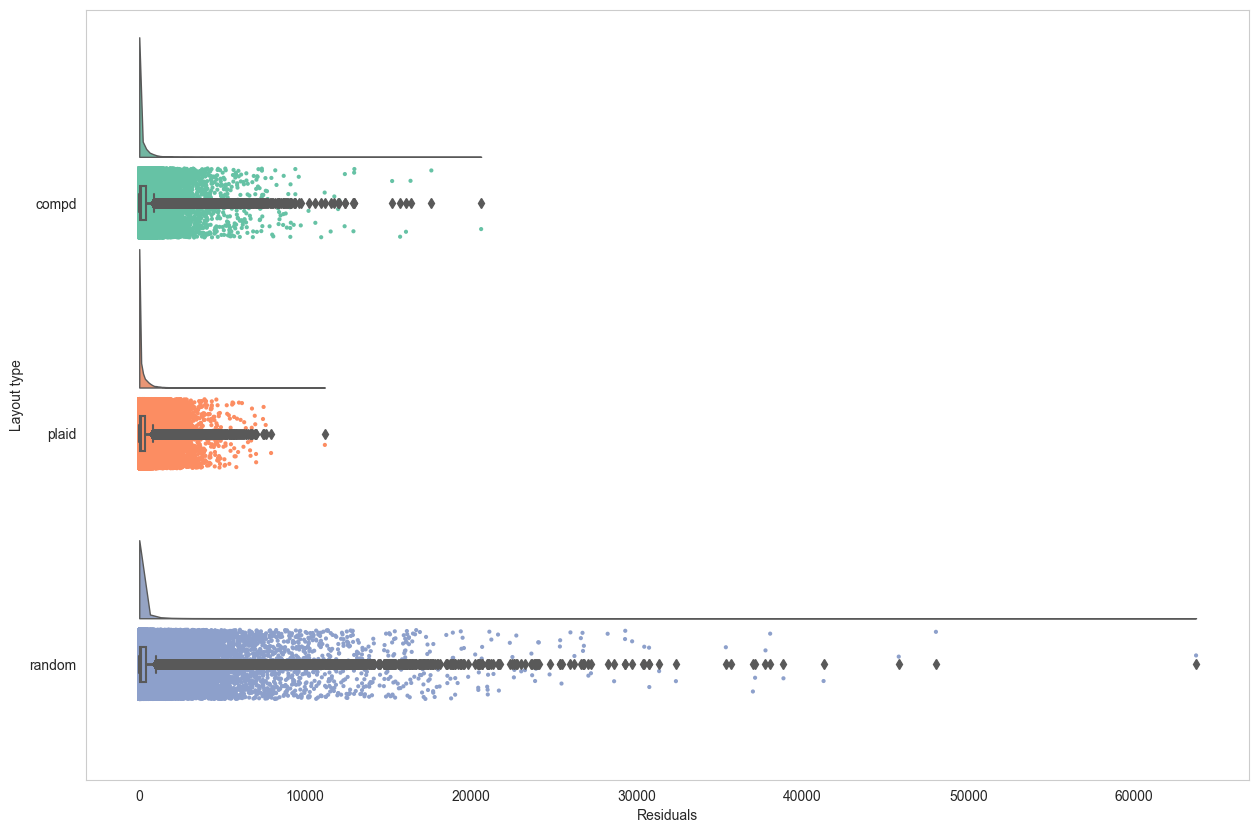

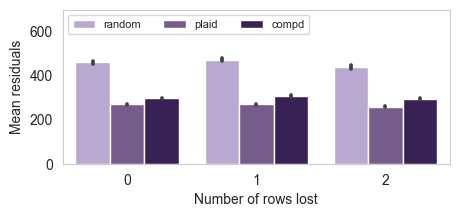

percent_non_active: 0.8
screening-residuals-10-20-0.1-pna-0.8-20250623-ROC-supplement.csv


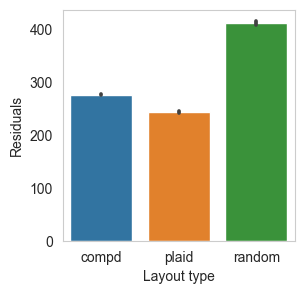

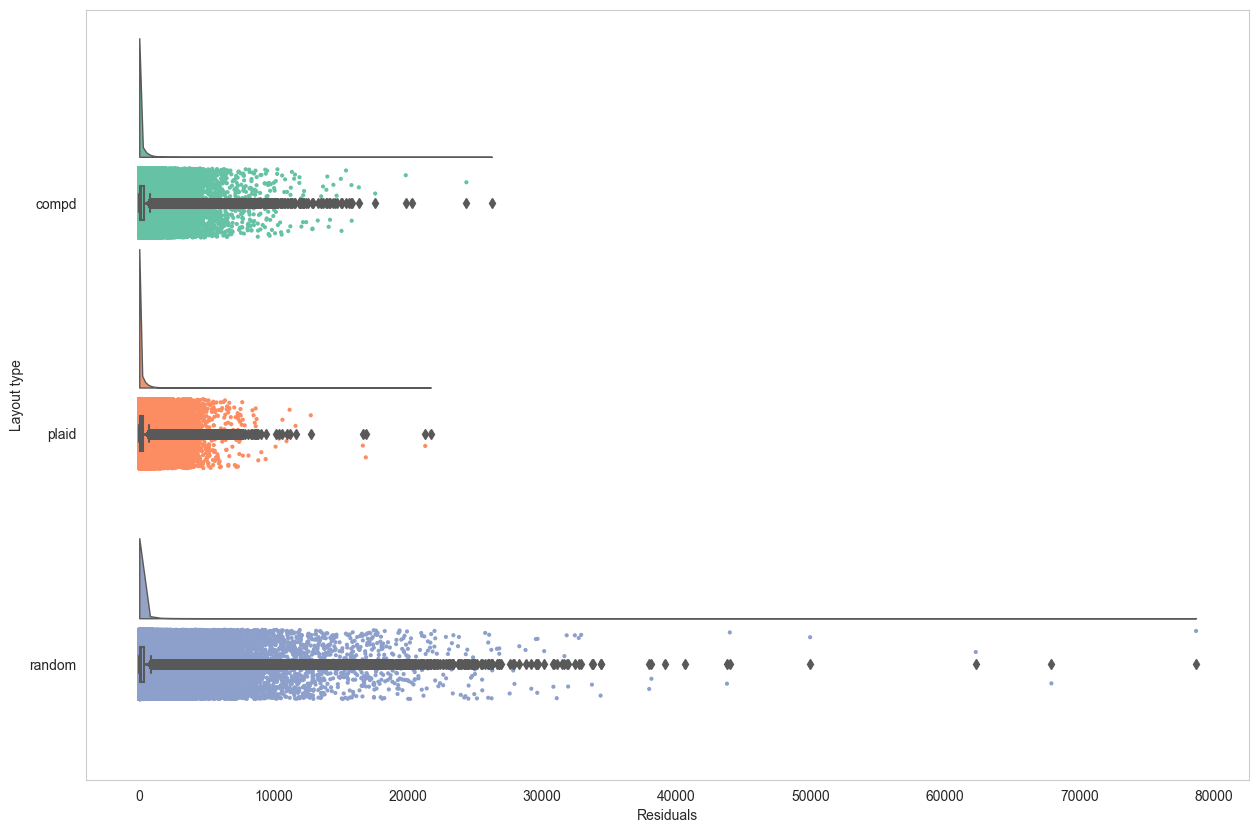

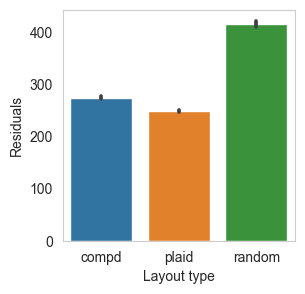

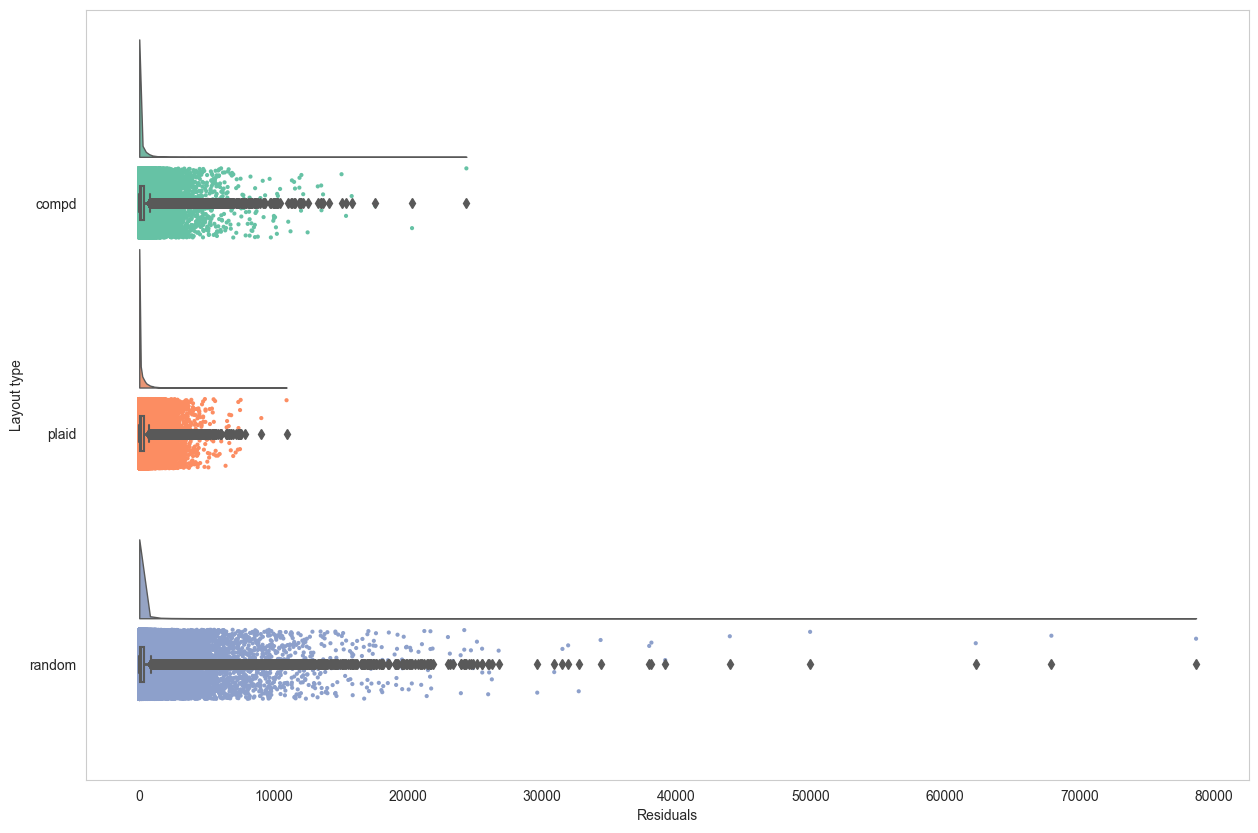

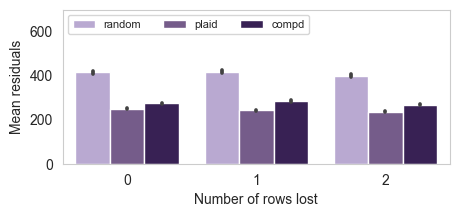

percent_non_active: 0.7
screening-residuals-10-20-0.1-pna-0.7-20250623-ROC-supplement.csv


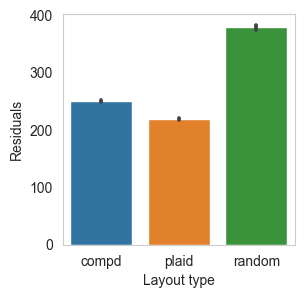

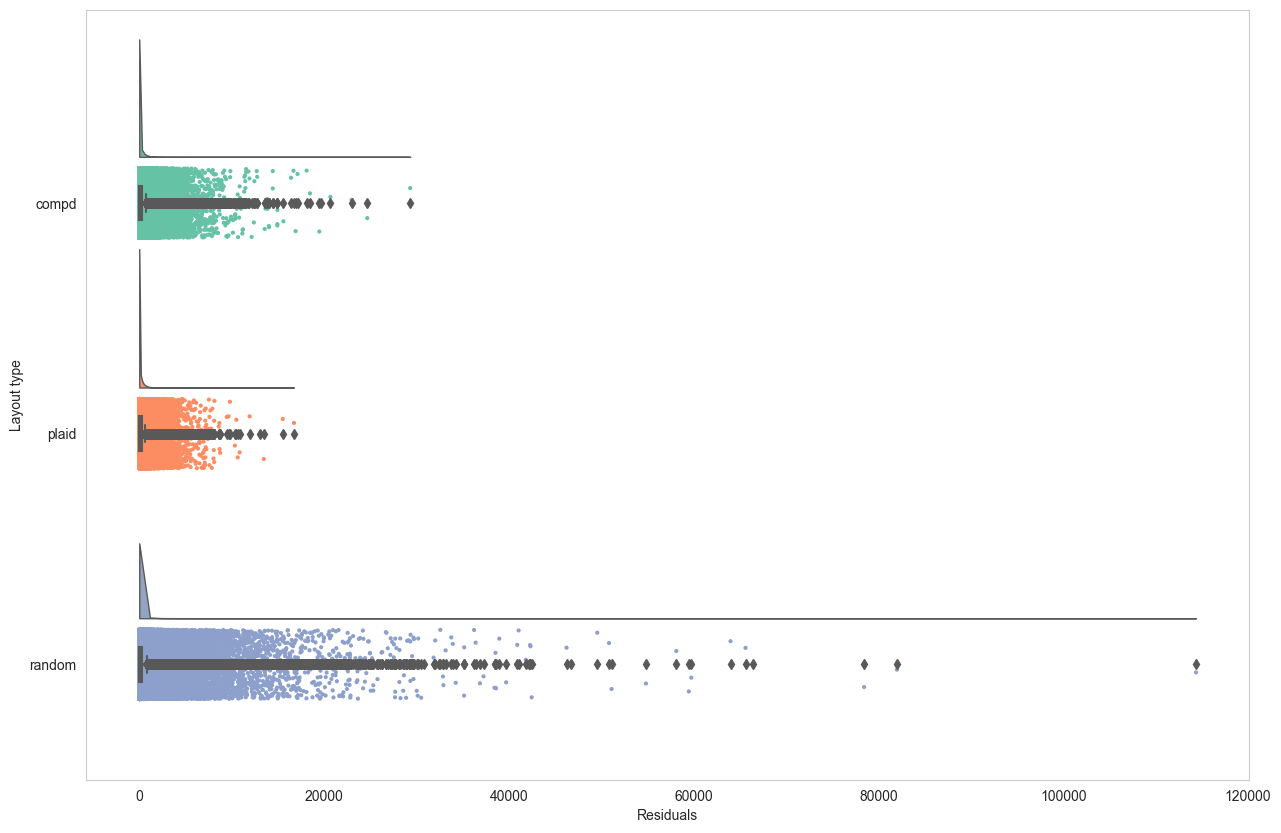

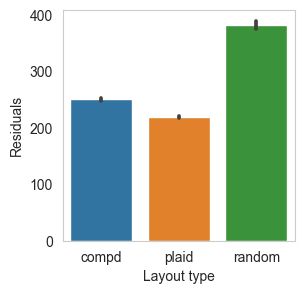

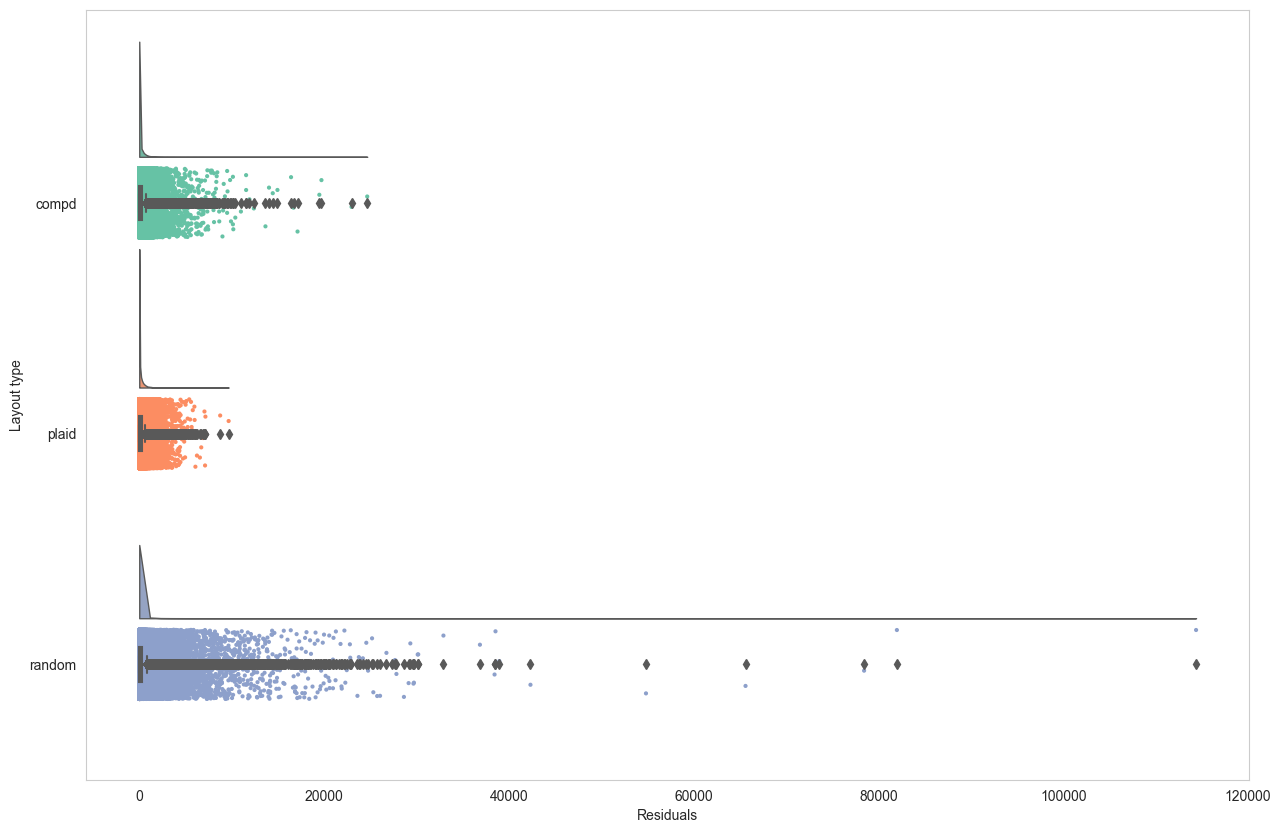

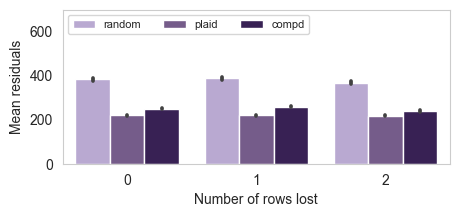

percent_non_active: 0.6
screening-residuals-10-20-0.1-pna-0.6-20250623-ROC-supplement.csv


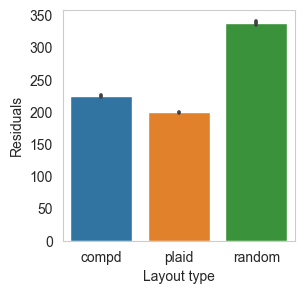

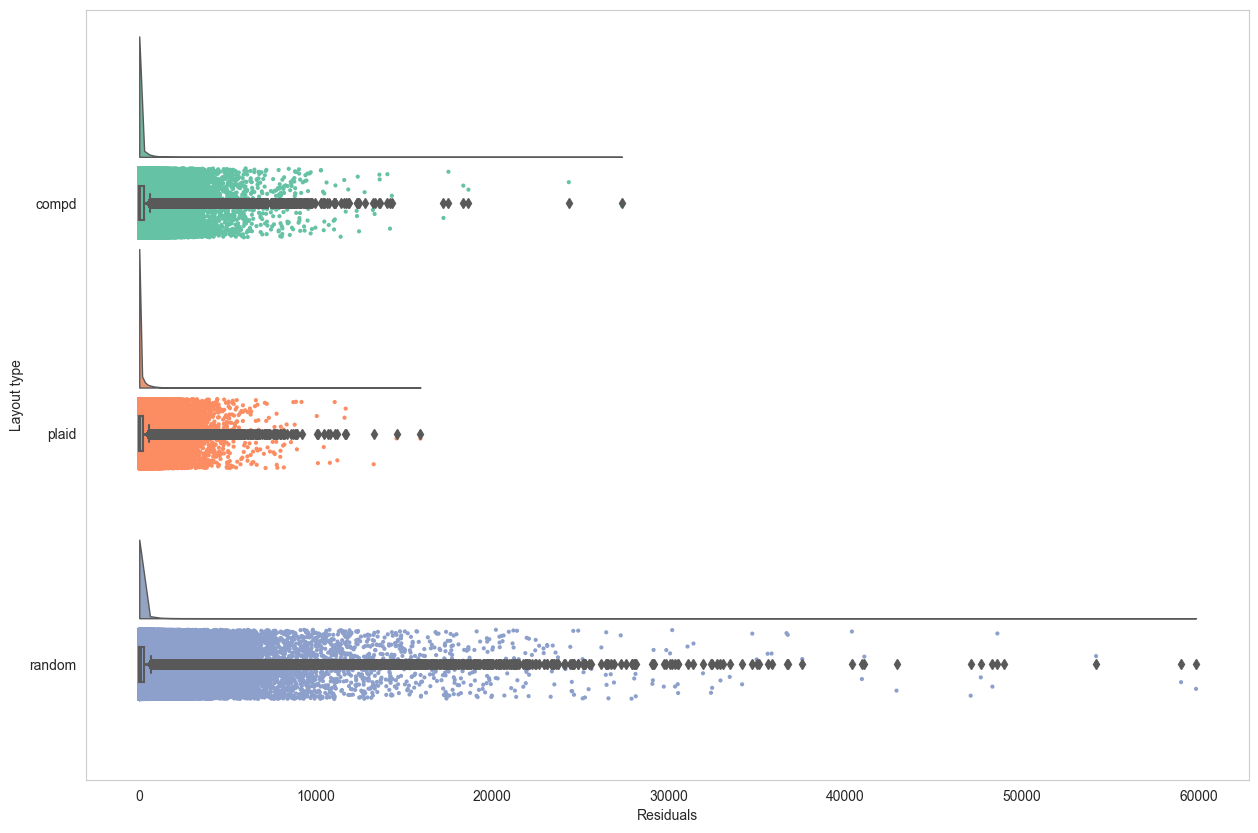

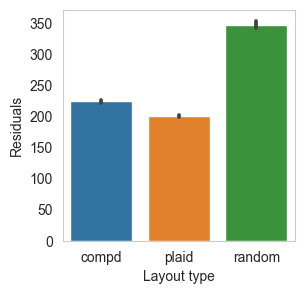

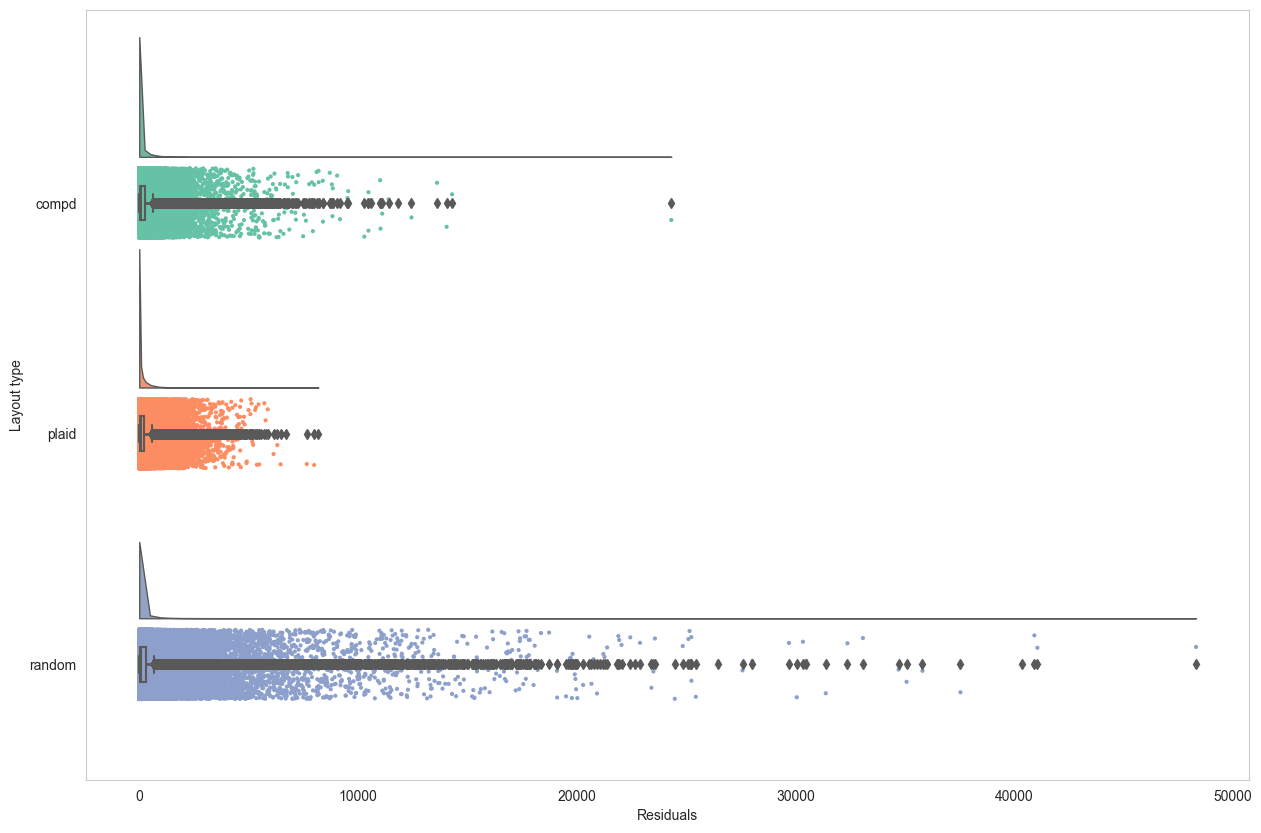

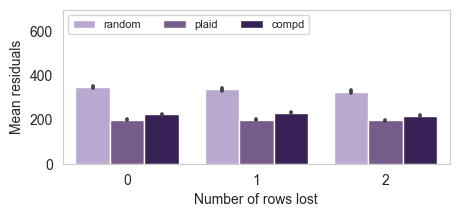

error: 0.2
percent_non_active: 0.99
screening-residuals-10-20-0.2-pna-0.99-20250623-ROC-supplement.csv


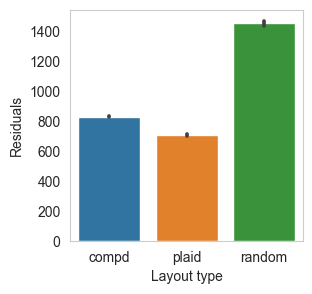

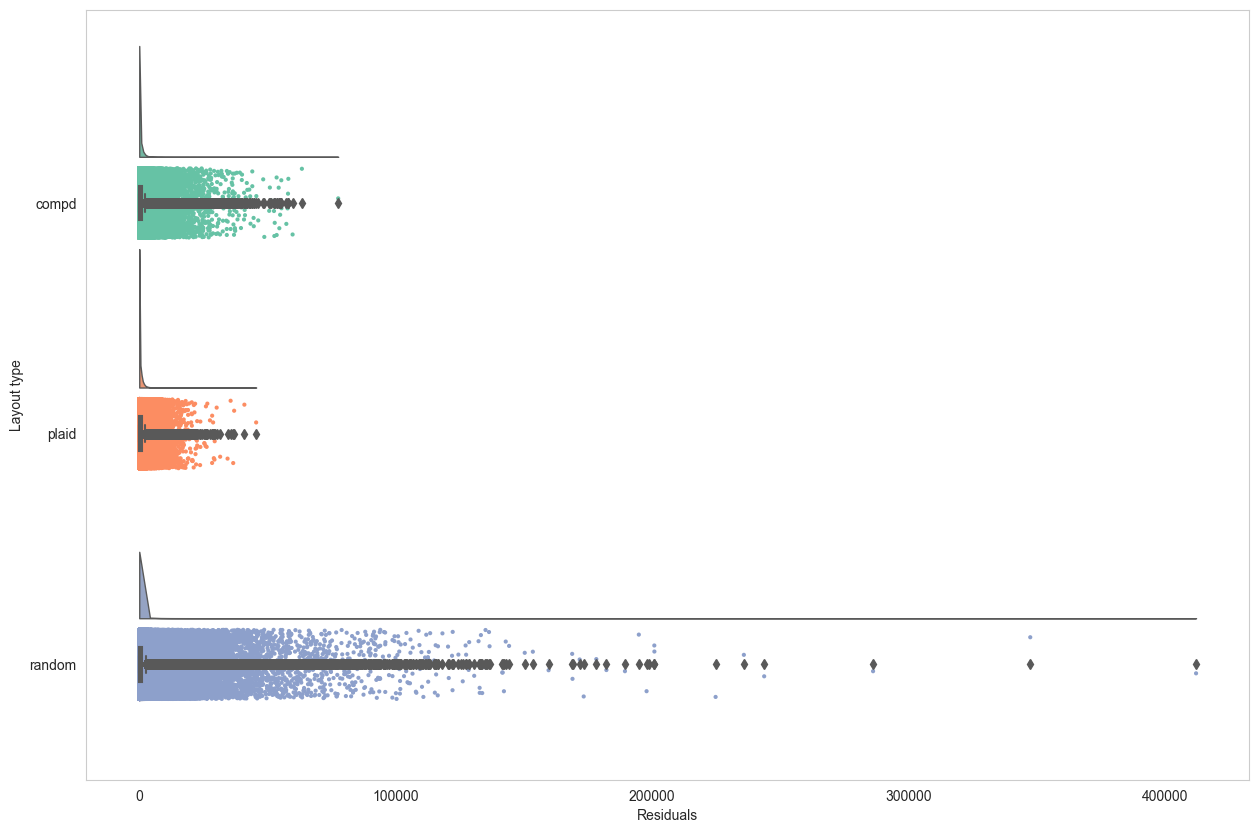

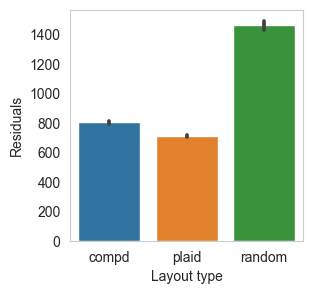

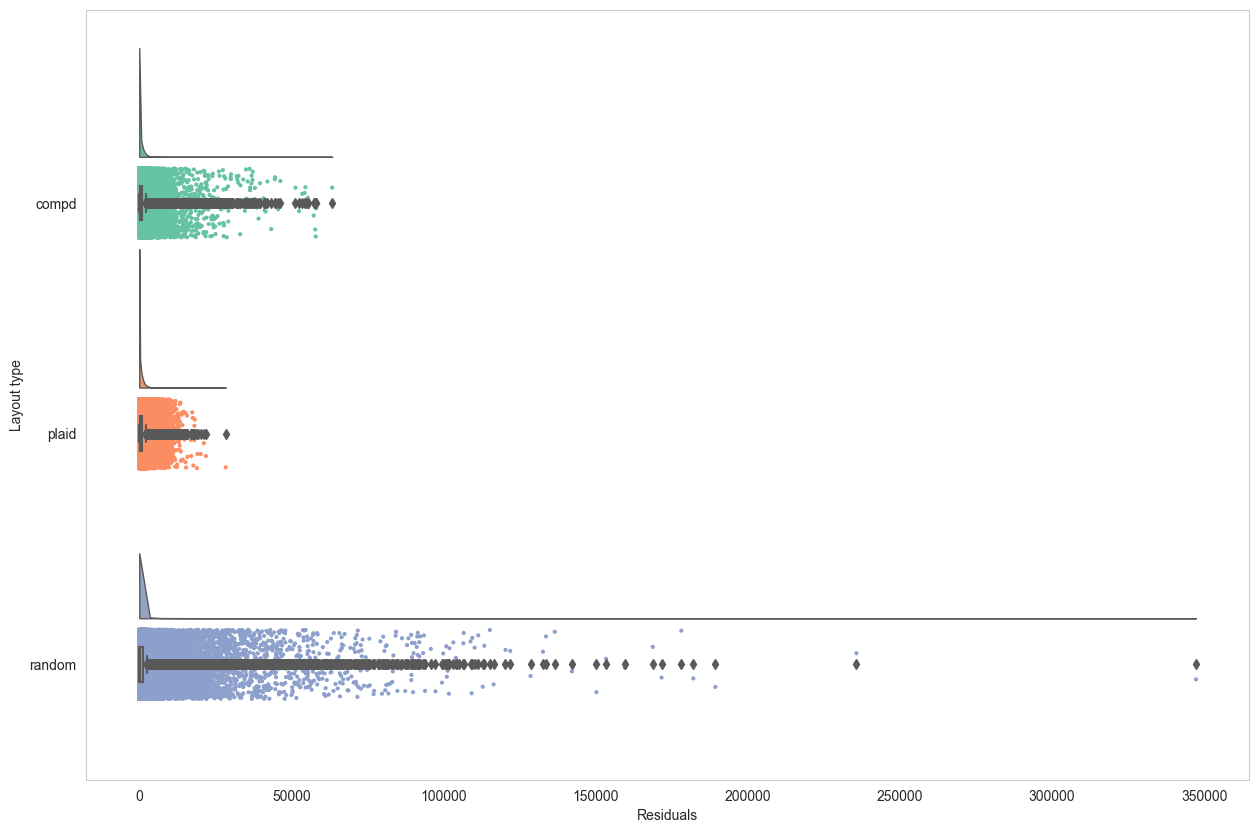

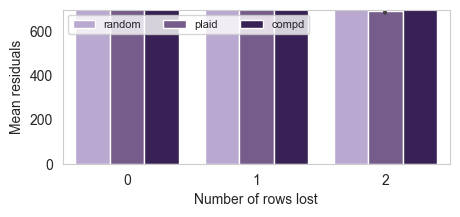

percent_non_active: 0.95
screening-residuals-10-20-0.2-pna-0.95-20250623-ROC-supplement.csv


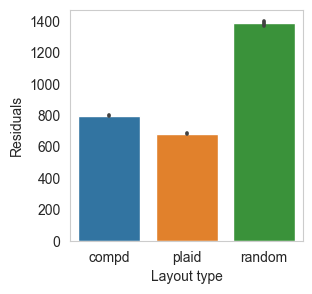

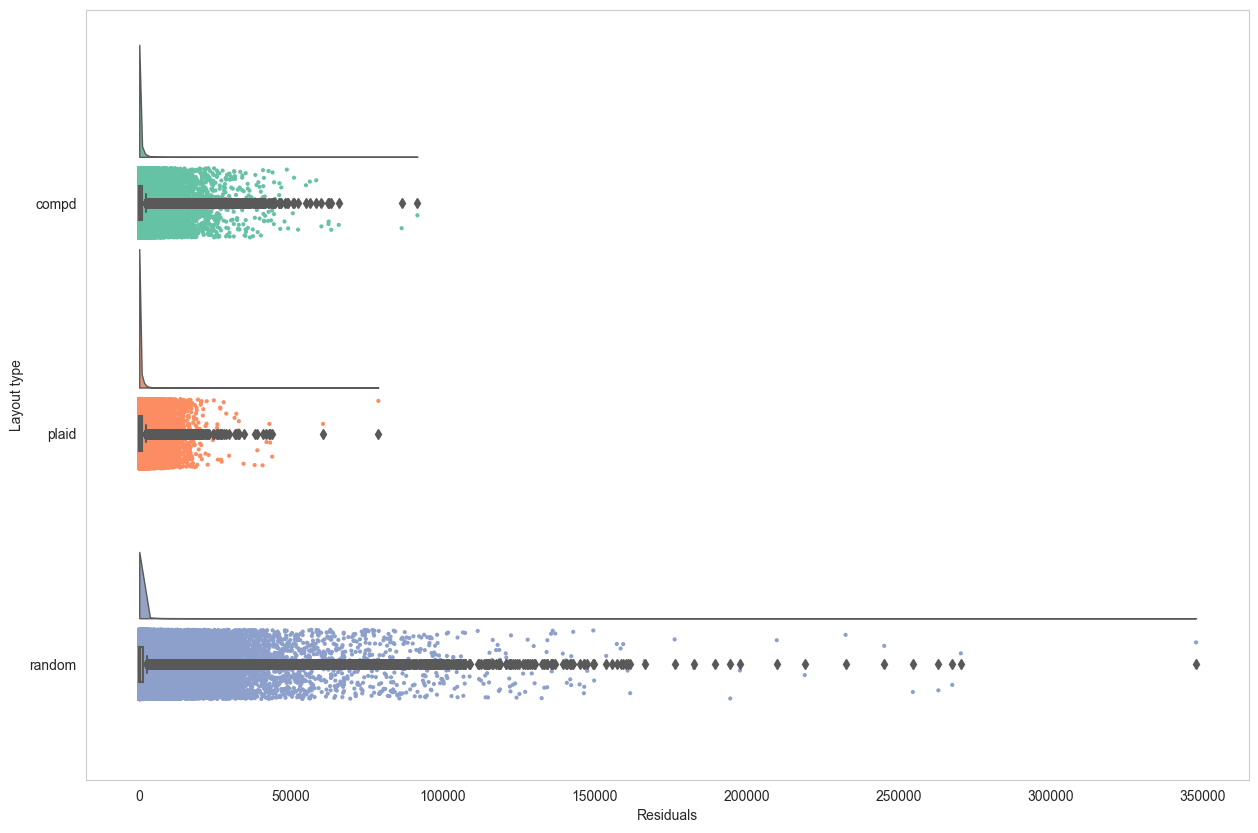

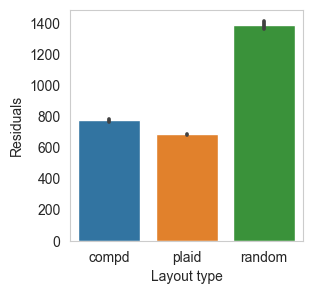

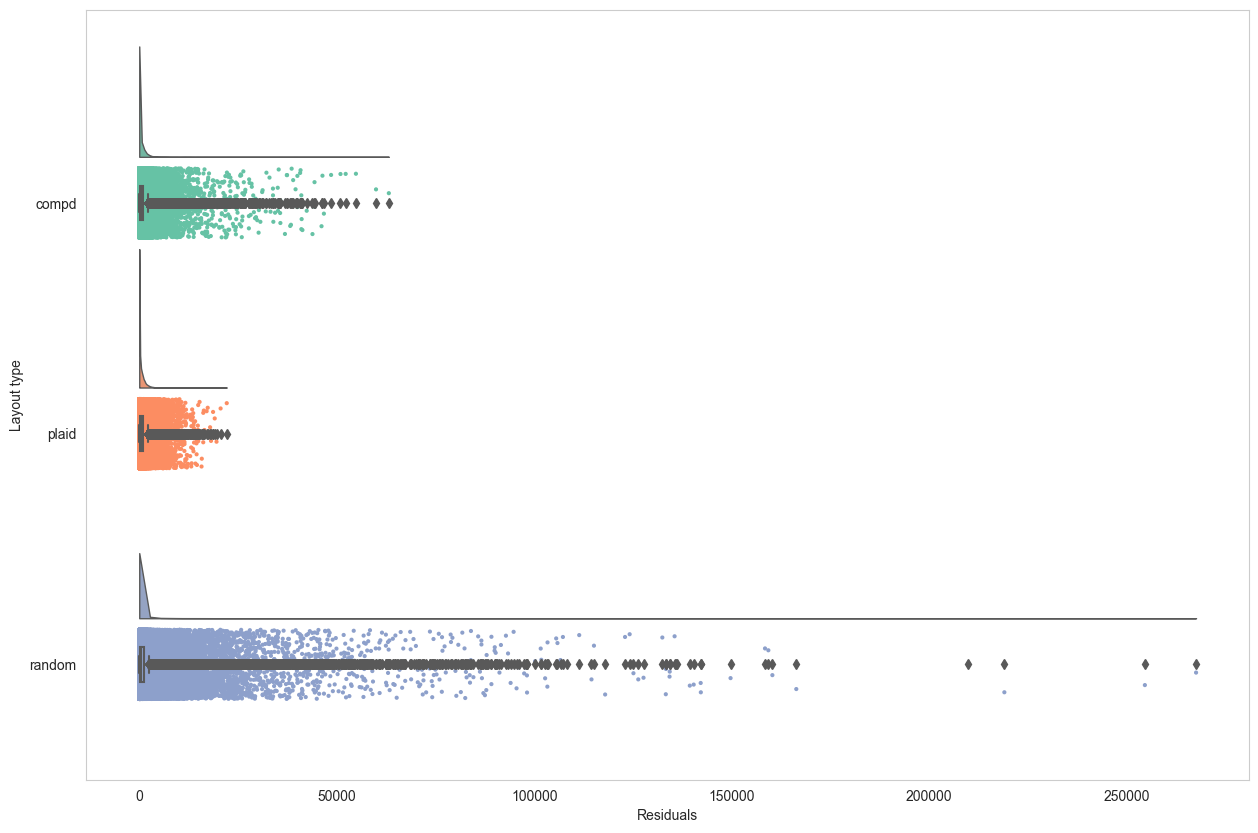

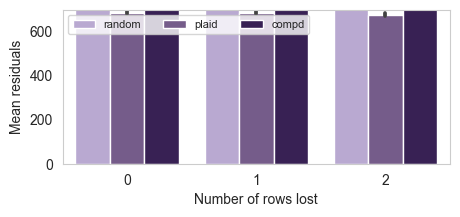

percent_non_active: 0.9
screening-residuals-10-20-0.2-pna-0.9-20250623-ROC-supplement.csv


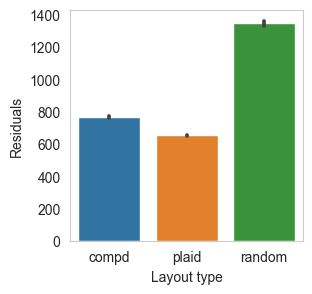

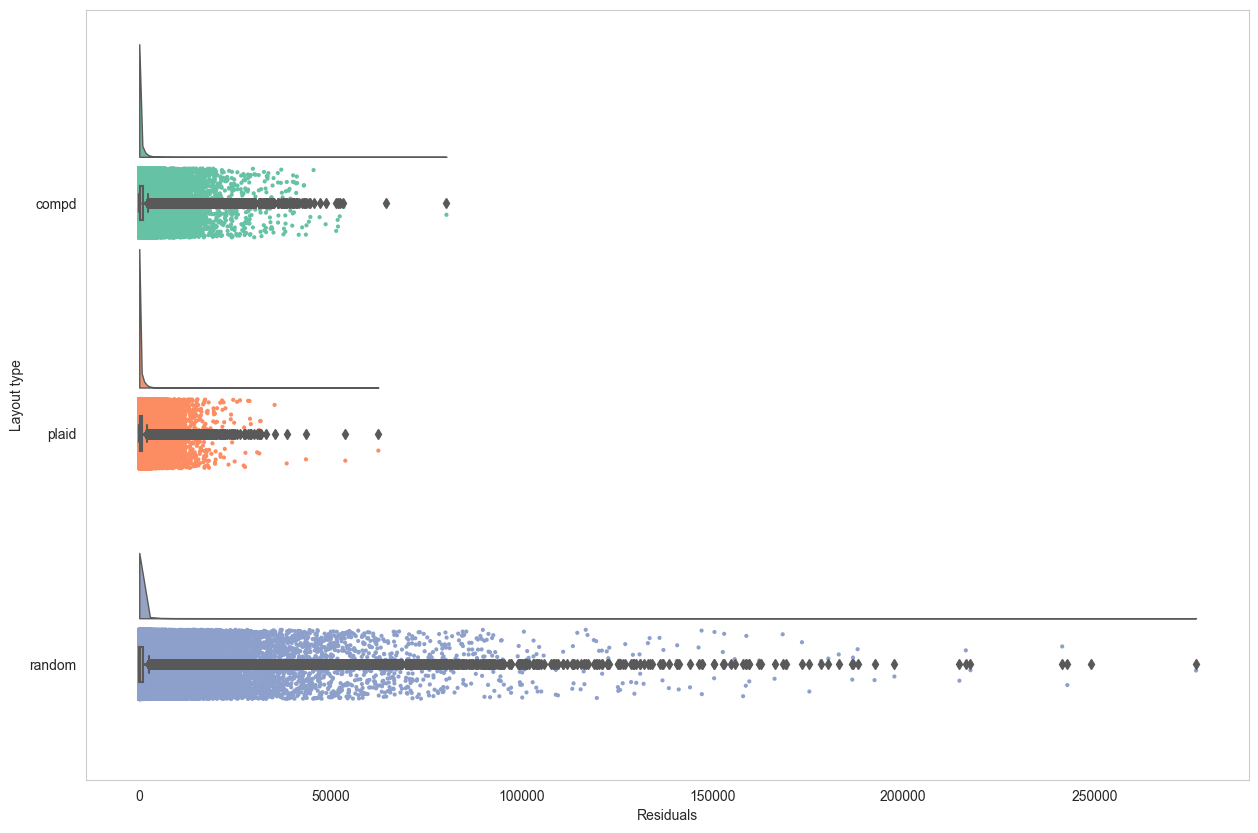

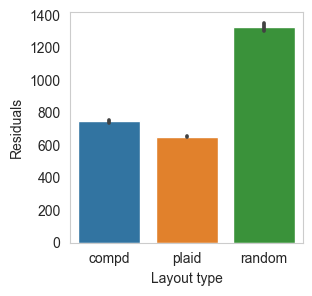

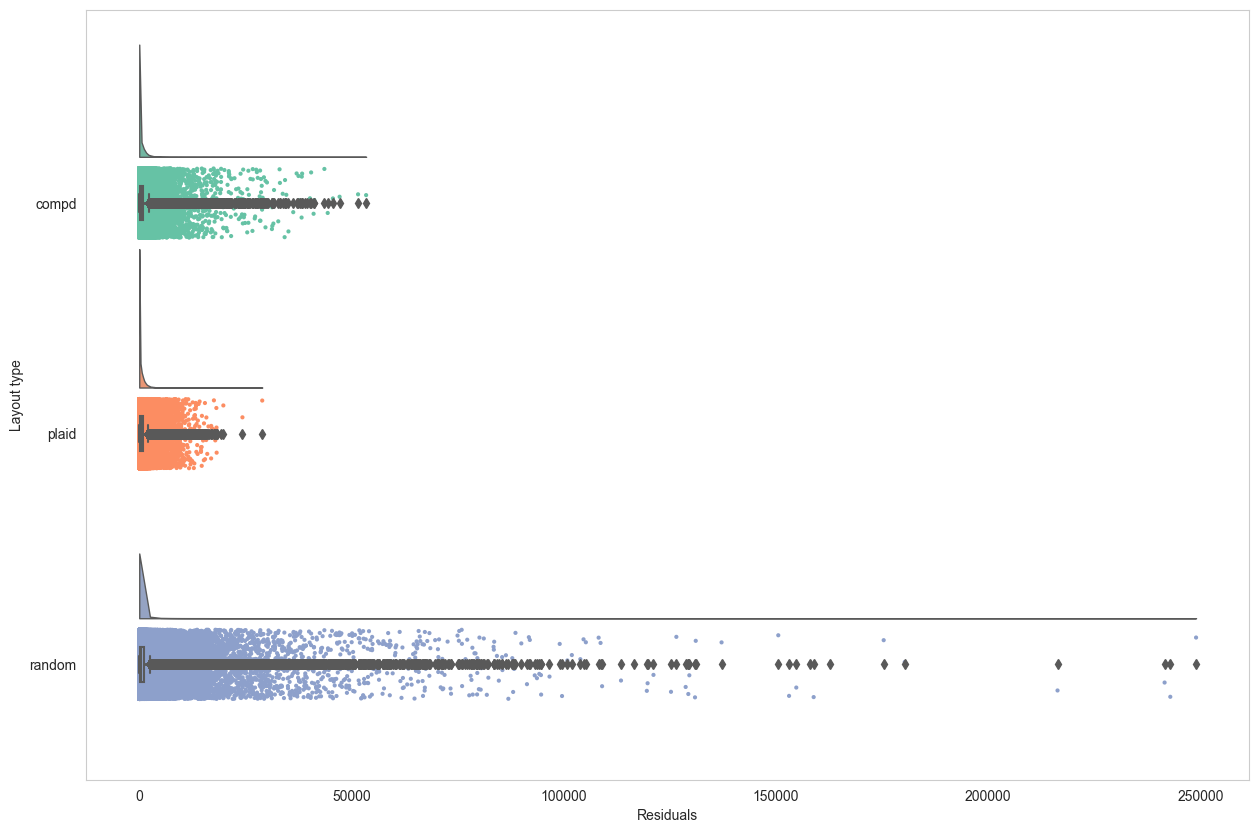

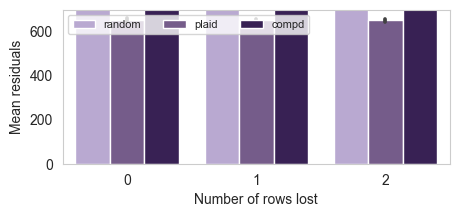

percent_non_active: 0.8
screening-residuals-10-20-0.2-pna-0.8-20250623-ROC-supplement.csv


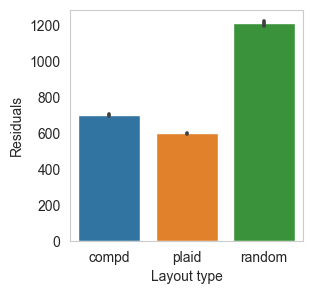

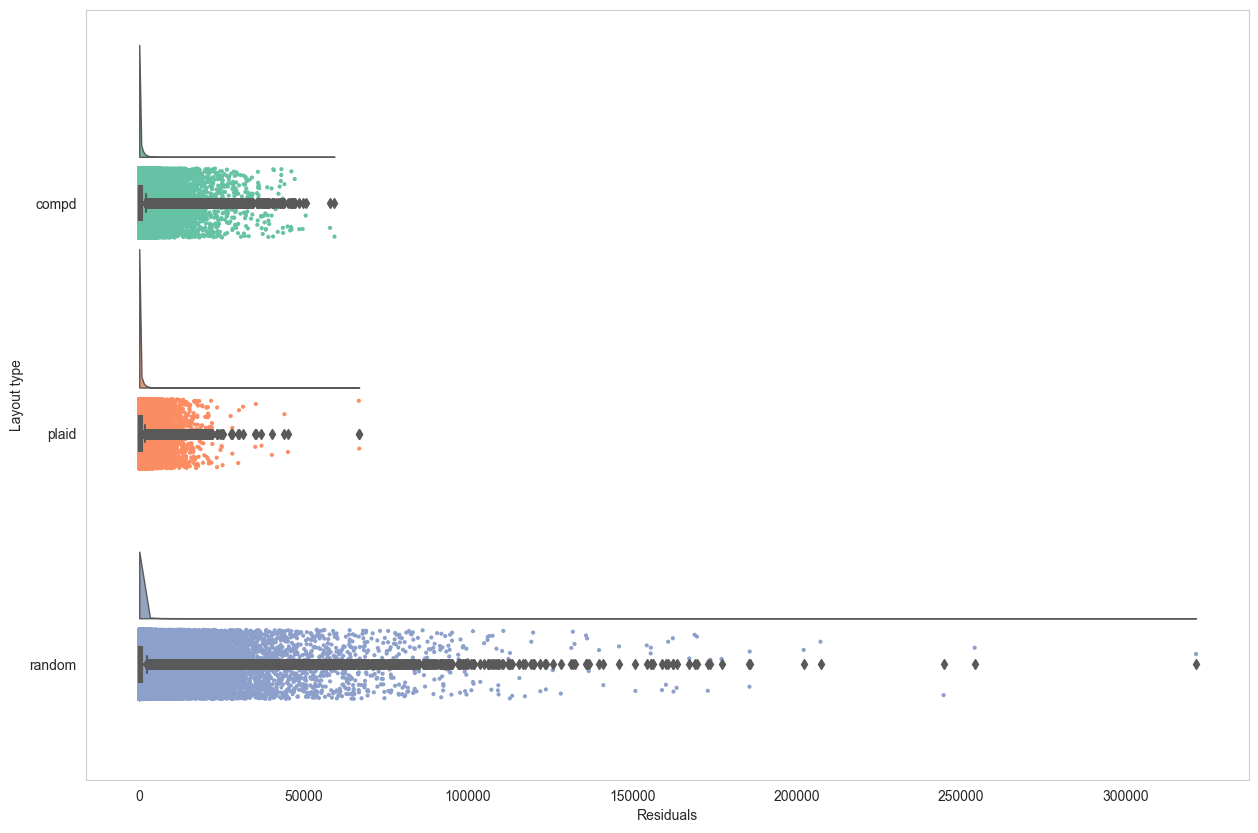

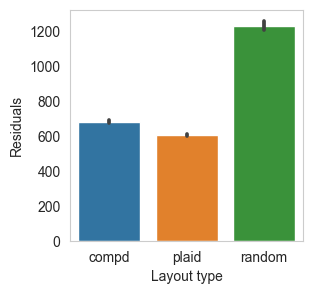

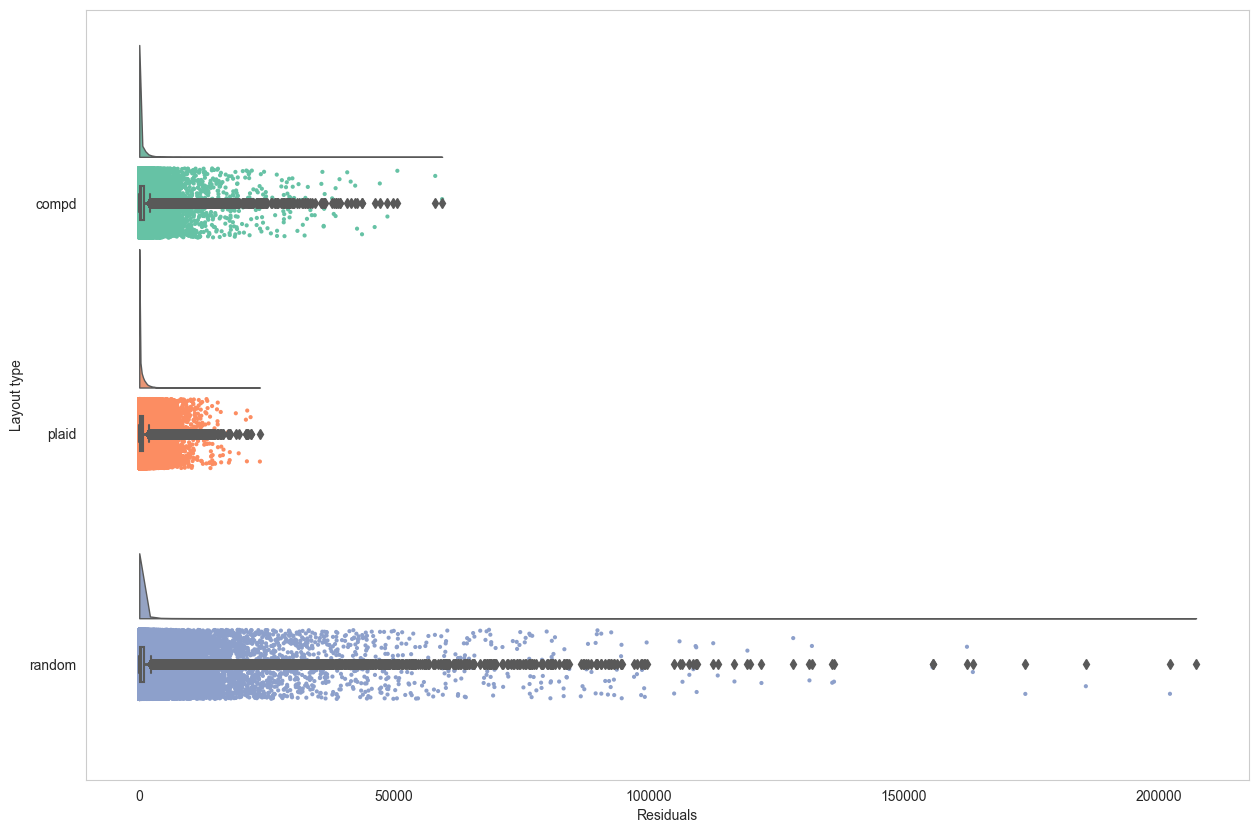

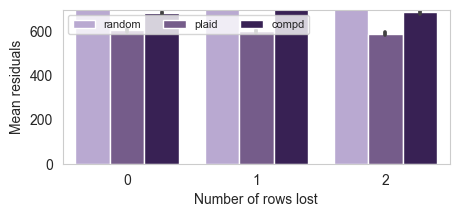

percent_non_active: 0.7
screening-residuals-10-20-0.2-pna-0.7-20250623-ROC-supplement.csv


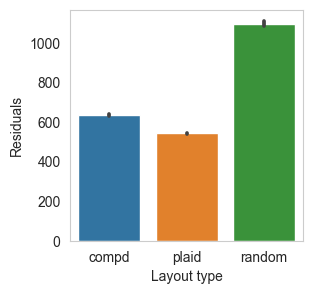

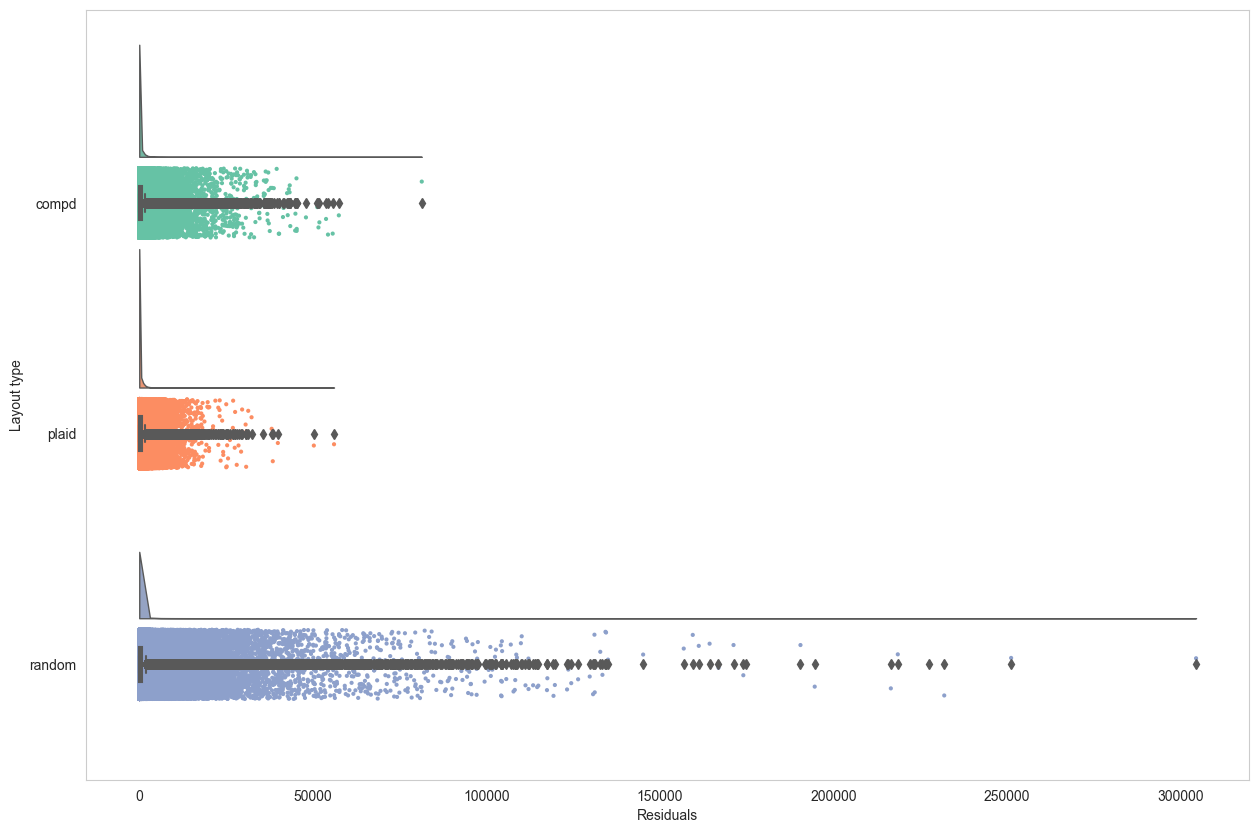

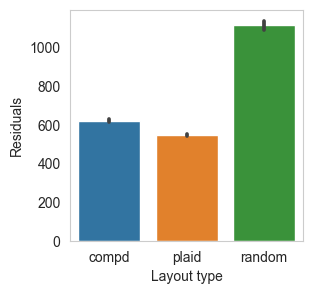

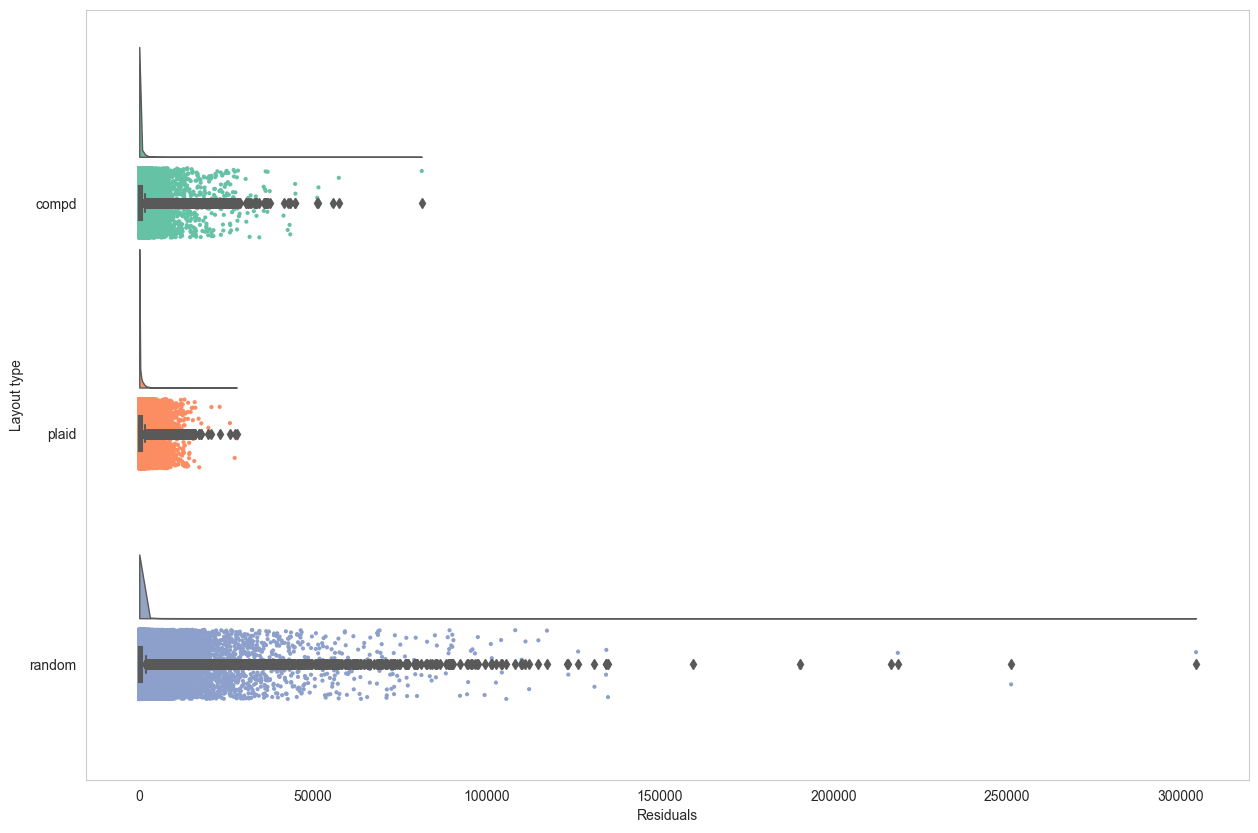

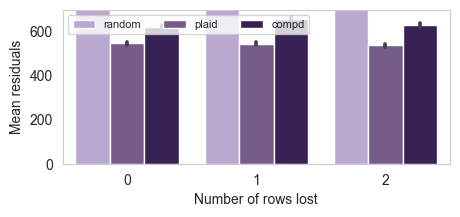

percent_non_active: 0.6
screening-residuals-10-20-0.2-pna-0.6-20250623-ROC-supplement.csv


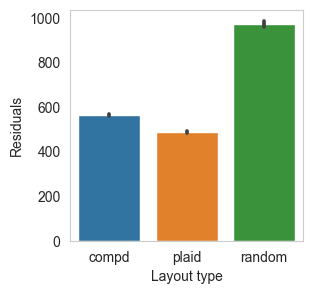

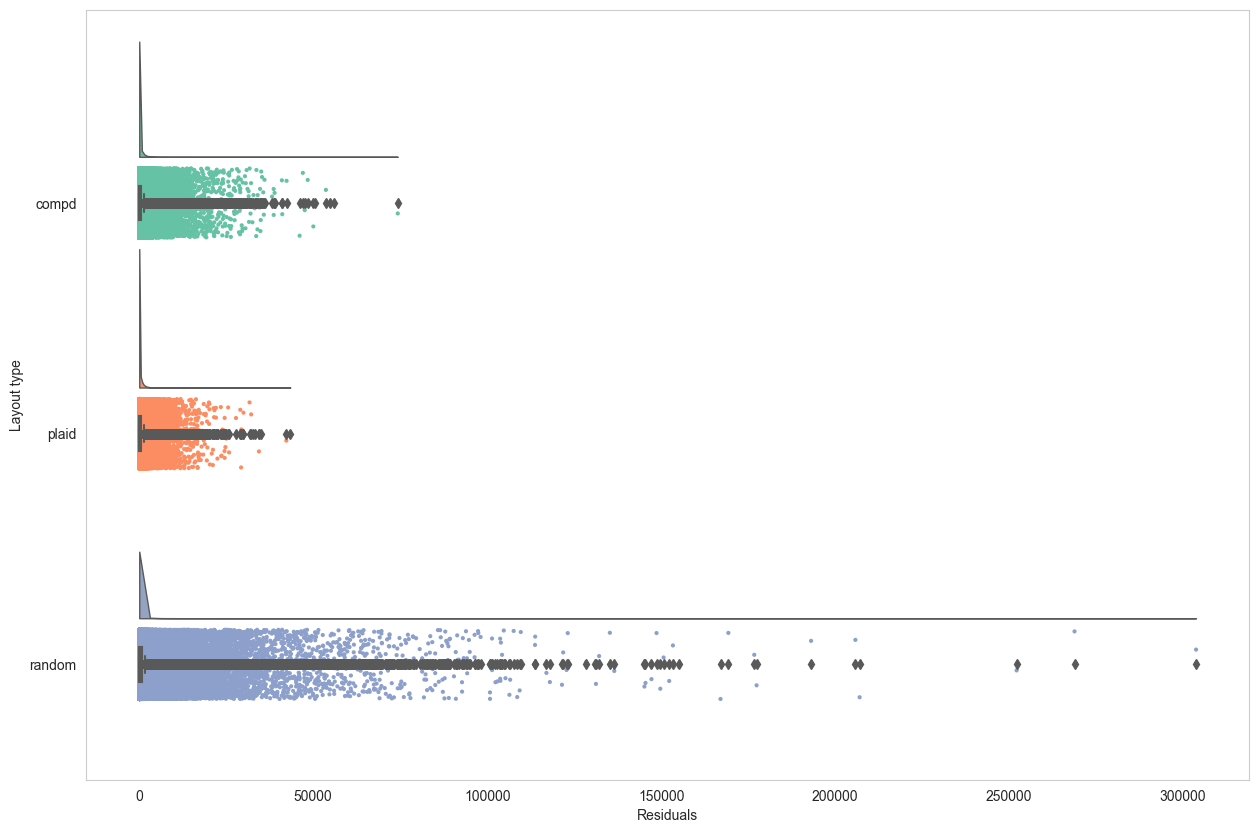

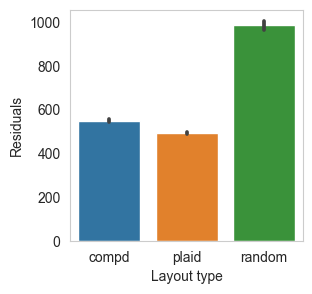

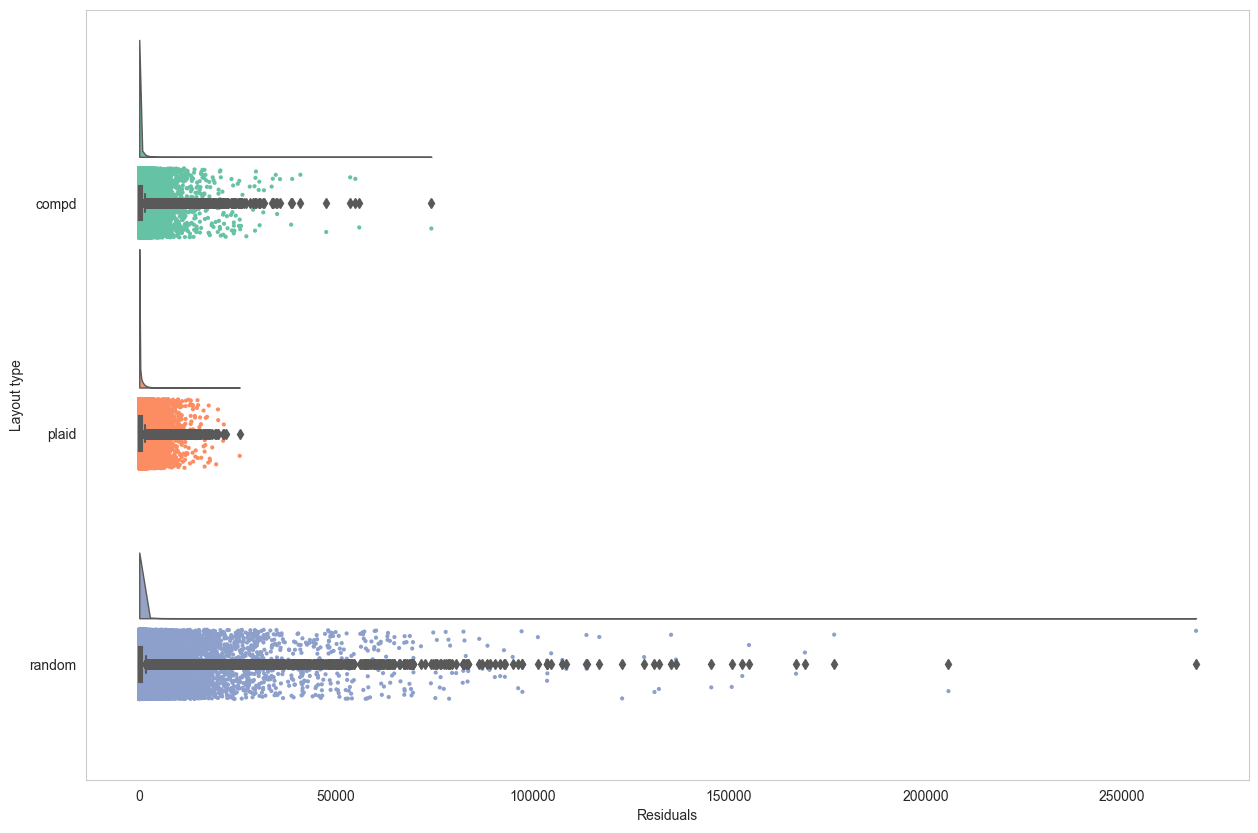

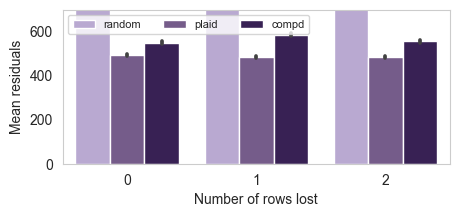

In [42]:
for (neg_controls, pos_controls) in neg_pos_controls_list:
    print("(neg_controls, pos_controls):", neg_controls, pos_controls)
    for error in error_strength_list:
        print("error:", error)
        for percent_non_active in percent_non_active_list:
            print("percent_non_active:",percent_non_active)
            #screening_scores_data_filename = 'screening_scores_data-'+str(pos_controls)+'-'+str(neg_controls)+'-'+str(error)+"-pna-"+str(percent_non_active)+today+'.csv'
            residuals_filename = 'screening-residuals-'+str(pos_controls)+'-'+str(neg_controls)+'-'+str(error)+"-pna-"+str(percent_non_active)+today+'.csv'
            try:
                print(residuals_filename)
                screening_residuals_df = pd.read_csv(residuals_filename)
                
                
                fig, ax = plt.subplots(figsize=(3, 3))
                
                #ax.set(ylim=(0,0.6))
                
                ax = sns.barplot(x="layout", y="true_residuals", data=screening_residuals_df, order=["compd", "plaid", "random"])
                
                #ax = sns.barplot(x="layout", y="MSE", data=results_df[results_df['MSE']!=np.inf], order=["plaid", "random"])
                
                ax.set(xlabel='Layout type', ylabel='Residuals')
                
                plt.show()
                
                
                
                # Rain plot
                #temp_half = residuals_df#[(residuals_df['MSE']!=np.inf) & (residuals_df['rows lost']<=1) & (residuals_df['E']>20) & (residuals_df['E']<100) ]
                #temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1
                
                fig, ax = plt.subplots(figsize=(15, 10))
                
                #ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])
                
                #sns.barplot(x = "group", y = "score", data = df, capsize= .1)
                pal = sns.color_palette(n_colors=1)
                
                #ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
                 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])
                
                dx = "true_residuals"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
                #f, ax = plt.subplots(figsize=(7, 5))
                
                ax = pt.RainCloud(x = "layout", y = "true_residuals", data = screening_residuals_df, palette = pal, bw = sigma,
                                 width_viol = 1.2, ax = ax, orient = ort, order=["compd", "plaid", "random"], jitter = 0.15)
                
                #ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
                #ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)
                
                ax.set(xlabel='Residuals', ylabel='Layout type')
                
                plt.show()
                
                
                
                screen_all_rows = screening_residuals_df[(screening_residuals_df['lost_rows']<1) ]
                
                
                fig, ax = plt.subplots(figsize=(3, 3))
                
                #ax.set(ylim=(0,0.6))
                
                ax = sns.barplot(x="layout", y="true_residuals", data=screen_all_rows, order=["compd", "plaid", "random"])
                
                #ax = sns.barplot(x="layout", y="MSE", data=results_df[results_df['MSE']!=np.inf], order=["PLAID", "RANDOM"])
                
                ax.set(xlabel='Layout type', ylabel='Residuals')
                
                plt.show()
                
                
                # Rain plot
                #temp_half = residuals_df#[(residuals_df['MSE']!=np.inf) & (residuals_df['rows lost']<=1) & (residuals_df['E']>20) & (residuals_df['E']<100) ]
                #temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1
                
                fig, ax = plt.subplots(figsize=(15, 10))
                
                #ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])
                
                #sns.barplot(x = "group", y = "score", data = df, capsize= .1)
                pal = sns.color_palette(n_colors=1)
                
                #ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
                 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])
                
                dx = "true_residuals"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
                #f, ax = plt.subplots(figsize=(7, 5))
                
                ax = pt.RainCloud(x = "layout", y = "true_residuals", data = screen_all_rows, palette = pal, bw = sigma,
                                 width_viol = 1.2, ax = ax, orient = ort, order=["compd", "plaid", "random"], jitter = 0.15)
                
                #ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
                #ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)
                
                ax.set(xlabel='Residuals', ylabel='Layout type')
                
                plt.show()
                
                
                
                ## Plot residuals for different amounts of rows lost ##
                
                #screening_residuals_df.loc[(screening_residuals_df['layout'] == "random"), 'layout'] = "Random"
                #screening_residuals_df.loc[(screening_residuals_df['layout'] == "compd"), 'layout'] = "Border"
                #screening_residuals_df.loc[(screening_residuals_df['layout'] == "plaid"), 'layout'] = "Effective"
                
                sns.set_style("whitegrid", {'axes.grid' : False})
                
                fig, ax = plt.subplots(figsize=(5, 2))
                
                palette = ["#b7a2d8", "#765591", "#37185d"] #Dark purple
                ax.set(ylim=(0,699))
                ax = sns.barplot(x="lost_rows", y="true_residuals", hue="layout", data=screening_residuals_df, palette=palette)
                
                plt.xlabel("Number of rows lost", fontsize = 10)
                plt.ylabel("Mean residuals", fontsize = 10)
                plt.legend(ncol=3, loc="upper left", fontsize = 8)
                
                plt.show()

            except:
                None